In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
# Use seaborn style for the plot
sns.set_style("white")

In [3]:
palette_colors = {
    'never_expressed': 'lightcoral',
    'subgen': 'mediumseagreen',
    'always_expressed': 'skyblue'
}

In [ ]:
gene_function_path = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/20241016_subgen_monomer_counts_40_seeds_last_11_gens_and_functions_min_media.tsv'
all_genes_function_status = pd.read_csv(gene_function_path,index_col=0)
gene_symbol_dict = all_genes_function_status[['gene_name', 'Gene Name']].set_index('gene_name').to_dict()['Gene Name']

In [63]:
rna_half_lives_path = '/Users/noravivancogonzalez/code/wcEcoli/reconstruction/ecoli/flat/rna_half_lives.tsv'

In [74]:
rna_half_lives_pd = pd.read_csv(rna_half_lives_path, sep = '\t',  skiprows = 1)

In [4]:
conditions_path = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/20251027_subgen_monomers_across_media_conditions.tsv'
subgen_counts_conditions = pd.read_csv(conditions_path, 
                                       sep = ',', 
                                       index_col = 0)
schmidt_path = '/Users/noravivancogonzalez/code/wcEcoli/validation/ecoli/flat/schmidt2015_javier_table.tsv'
schmidt_df = pd.read_csv(schmidt_path, sep = '\t')
subgen_w_val_data = subgen_counts_conditions.merge(schmidt_df, left_on = 'gene_name', right_on = 'EcoCycID', how = 'left').fillna(0)

In [5]:
protein_syn_rates_path = '/Users/noravivancogonzalez/code/wcEcoli/validation/ecoli/flat/li_protein_synthesis_rates_2014.tsv'

In [6]:
li_df = pd.read_csv(protein_syn_rates_path, sep = '\t', skiprows = 6)

In [7]:
li_df['MOPS minimal'] = li_df['MOPS minimal'].str.replace('[', '', regex=False).str.replace(']', '', regex=False).astype(float)

In [53]:
subgen_w_val_data['GeneName'] = subgen_w_val_data['gene_name'].map(gene_symbol_dict)

In [54]:
subgen_w_rib_prof = subgen_w_val_data.merge(li_df, left_on = 'GeneName', right_on = 'Gene', how = 'left').fillna(0)

In [58]:
subgen_w_rib_prof['MOPS minimal_protein_syn_prob_1'] = np.log2(subgen_w_rib_prof['MOPS minimal'] +1)

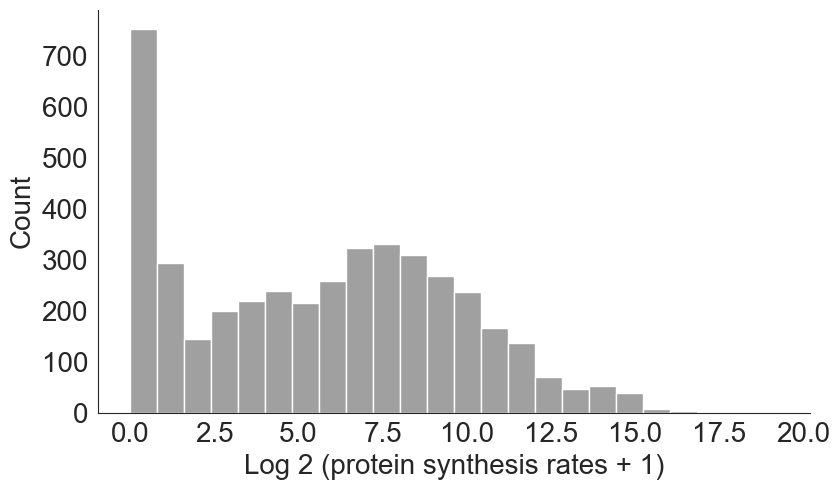

In [60]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(data = subgen_w_rib_prof,
             x = 'MOPS minimal_protein_syn_prob_1', 
             edgecolor='white',
             color = 'grey',
             # multiple='stack',
             # hue = 'expression_status_basal', 
             # palette=palette_colors,
             log_scale=False)
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Log 2 (protein synthesis rates + 1)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

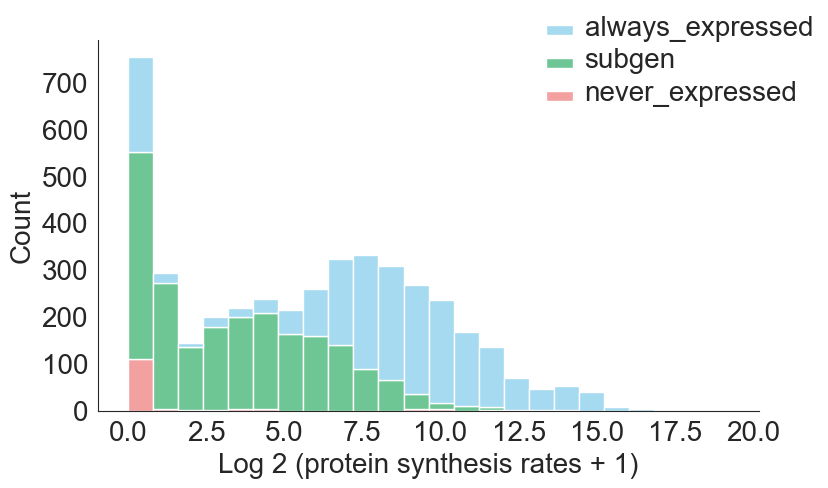

In [59]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(data = subgen_w_rib_prof,
             x = 'MOPS minimal_protein_syn_prob_1', 
             edgecolor='white',
             multiple='stack',
             hue = 'expression_status_basal', 
             palette=palette_colors,
             log_scale=False)
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Log 2 (protein synthesis rates + 1)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [14]:
exp_rna_data_file = '/Users/noravivancogonzalez/code/wcEcoli/reconstruction/ecoli/flat/rna_seq_data/rnaseq_rsem_tpm_mean.tsv'
exp_rna_pd = pd.read_csv(exp_rna_data_file, sep = '\t')

In [67]:
subgen_w_exp_rna = subgen_w_rib_prof.merge(exp_rna_pd, left_on = 'gene_name', right_on = 'Gene', how = 'left').fillna(0)

In [68]:
subgen_w_exp_rna['M9 Glucose minus AAs log2'] = np.log2(subgen_w_exp_rna['M9 Glucose minus AAs']+1)

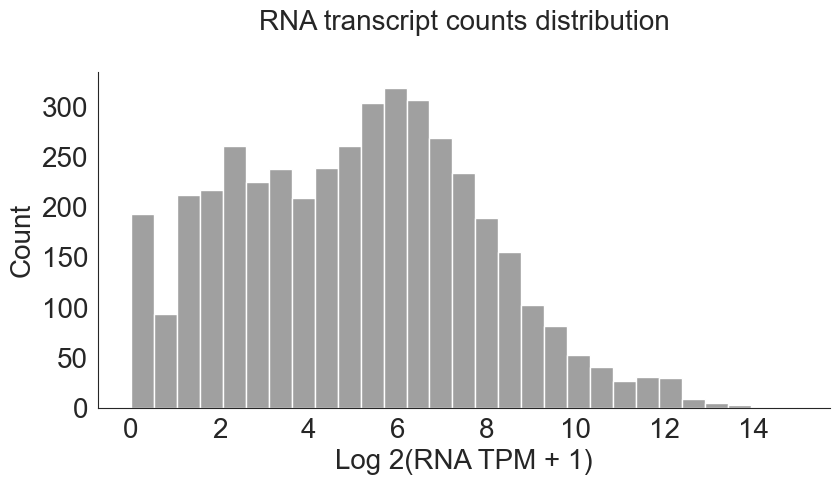

In [69]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(data = subgen_w_exp_rna,
             x = 'M9 Glucose minus AAs log2', color = 'grey',
             edgecolor='white',
             # multiple='stack',
             # hue = 'expression_status_basal', 
             # palette=palette_colors,
                 )
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Log 2(RNA TPM + 1)', fontsize=20)
plt.title('RNA transcript counts distribution', fontsize=20, y=1.1)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

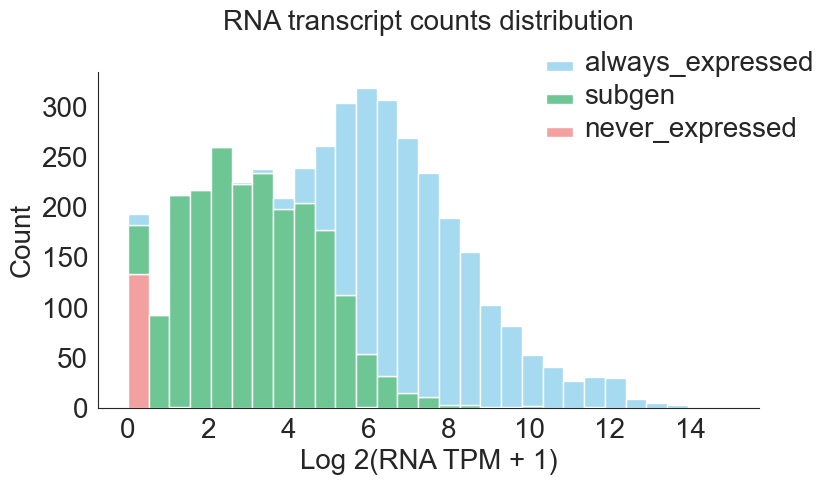

In [70]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(data = subgen_w_exp_rna,
             x = 'M9 Glucose minus AAs log2',
             edgecolor='white',
             multiple='stack',
             hue = 'expression_status_basal', 
             palette=palette_colors,)
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Log 2(RNA TPM + 1)', fontsize=20)
plt.title('RNA transcript counts distribution', fontsize=20, y=1.1)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [86]:
chen_polycistronic_half_life_data = [('TU-8385', 1.3), ('TU-8405', 1.0), ('TU-8419', 1.8), ('TU0-12815', 3.8), ('TU0-12834', 3.3), ('TU0-12849', 1.3), ('TU0-12881', 3.2), ('TU0-12902', 12.4), ('TU0-12918', 1.8), ('TU0-12963', 1.9), ('TU0-13059', 1.0), ('TU0-13079', 1.1), ('TU0-13088', 2.6), ('TU0-13110', 5.5), ('TU0-13116', 2.2), ('TU0-13120', 3.6), ('TU0-13136', 5.9), ('TU0-13141', 0.9), ('TU0-13196', 3.5), ('TU0-13335', 1.5), ('TU0-13417', 1.6), ('TU0-13432', 1.7), ('TU0-13443', 1.6), ('TU0-13549', 2.0), ('TU0-13558', 0.9), ('TU0-13589', 2.7), ('TU0-13710', 2.4), ('TU0-13713', 1.2), ('TU0-13715', 1.7), ('TU0-13741', 1.3), ('TU0-13746', 0.7), ('TU0-13805', 2.9), ('TU0-13806', 1.7), ('TU0-13837', 2.0), ('TU0-13839', 1.9), ('TU0-13863', 9.1), ('TU0-13872', 1.1), ('TU0-13883', 2.1), ('TU0-13898', 1.7), ('TU0-13919', 1.2), ('TU0-13942', 1.1), ('TU0-13957', 1.7), ('TU0-14042', 1.3), ('TU0-14049', 4.3), ('TU0-14056', 2.2), ('TU0-14097', 1.1), ('TU0-14099', 1.7), ('TU0-14103', 3.0), ('TU0-14122', 2.3), ('TU0-14176', 1.0), ('TU0-14216', 1.5), ('TU0-14336', 1.3), ('TU0-198880', 1.4), ('TU0-2001', 1.0), ('TU0-2302', 1.3), ('TU0-3422', 3.3), ('TU0-3465', 3.4), ('TU0-3741', 2.1), ('TU0-4187', 1.6), ('TU0-4205', 0.8), ('TU0-42504', 0.6), ('TU0-42674', 1.8), ('TU0-4343', 2.6), ('TU0-4444', 2.2), ('TU0-45190', 30.7), ('TU0-4604', 1.1), ('TU0-6634', 2.7), ('TU0-6653', 2.4), ('TU0-6941', 2.2), ('TU0-7002', 3.3), ('TU0-7784', 0.5), ('TU00004', 1.6), ('TU00008', 3.1), ('TU00021', 1.9), ('TU00037', 1.5), ('TU00054', 1.9), ('TU00058', 2.7), ('TU00082', 1.8), ('TU00123', 3.6), ('TU00178', 1.9), ('TU00190', 1.5), ('TU00196', 8.2), ('TU00205', 2.0), ('TU00213', 1.7), ('TU00222', 4.1), ('TU00225', 19.0), ('TU00231', 7.6), ('TU00237', 1.9), ('TU00238', 2.0), ('TU00240', 1.7), ('TU00258', 1.6), ('TU00273', 2.7), ('TU00283', 1.3), ('TU00287', 2.4), ('TU00289', 1.5), ('TU00297', 1.6), ('TU00302', 1.7), ('TU00314', 2.1), ('TU00323', 1.4), ('TU00325', 1.5), ('TU00337', 2.1), ('TU00344', 1.2), ('TU00345', 7.5), ('TU00346', 4.1), ('TU00347', 8.0), ('TU00349', 4.1), ('TU00354', 1.7), ('TU00358', 5.0), ('TU00359', 27.1), ('TU00361', 2.9), ('TU00367', 0.9), ('TU00369', 0.8), ('TU00439', 3.0), ('TU00454', 1.7), ('TU00459', 3.2), ('TU00492', 0.8), ('TU00495', 2.1), ('TU00503', 1.2), ('TU163', 2.9), ('TU164', 1.0), ('TU21', 3.6), ('TU261', 1.4), ('TU358', 6.0), ('TU462', 1.5), ('TU521', 1.2), ('TU704', 1.4), ('TU743', 2.1)]

In [89]:
polycistrons = [item[0] for item in chen_polycistronic_half_life_data]

In [87]:
chen_half_lives = {'TU00178': 1.9044842618347002, 'EG10011': 1.4651363871726817, 'EG11556': 3.4869300333216966, 'EG11511': 1.9653356528160575, 'EG11512': 4.917012812097112, 'EG10206': 3.6686859315317757, 'EG10326': 1.2426881282514812, 'EG11570': 1.2867514945196767, 'EG11083': 1.3905837866912065, 'TU0-45190': 30.67193602657272, 'EG10338': 1.1999440518859021, 'EG10265': 6.873540874507805, 'TU0-4343': 2.5780523448033796, 'EG10422': 11.585423707910564, 'EG11546': 1.5125580515306902, 'TU00237': 1.9302762684233357, 'EG10084': 4.0955779513591315, 'TU0-6634': 2.713134022827252, 'EG10543': 4.835455381964477, 'EG12316': 8.686661404393458, 'EG12605': 3.8062860440806334, 'TU00359': 27.12316918056951, 'EG10369': 2.5665149099829594, 'EG20098': 3.730525057245431, 'EG12319': 1.9348337111355172, 'TU0-12815': 3.834509610978673, 'EG12322': 1.6081153218426842, 'EG11747': 2.945653710281988, 'TU00358': 5.015294150828707, 'EG12330': 1.401862446795267, 'EG10432': 9.210208757501835, 'EG12331': 1.2442321135961782, 'EG12332': 2.261884811075019, 'EG10463': 1.9722948505088793, 'EG12336': 3.9890481611788737, 'TU00345': 7.546552127393043, 'EG11539': 10.102932072892454, 'EG10335': 3.8365696443992974, 'EG12715': 1.420448032965632, 'G6092': 1.7299394045619976, 'EG10139': 2.0235010984727455, 'EG12436': 1.7480478746541261, 'EG11284': 4.936906136179182, 'EG11647': 4.415936715270328, 'G6095': 5.506153258214037, 'G6096': 1.9898903916873936, 'TU0-12834': 3.305092112233153, 'EG10770': 1.7309964540123515, 'TU0-2302': 1.2621320621425376, 'EG11736': 1.9830386318075588, 'TU0-198880': 1.3694803433874576, 'EG10246': 1.1844031147061467, 'G6099': 3.0681813373895697, 'EG10243': 1.0015054873341065, 'G6103': 0.8869545979804089, 'G6106': 1.9325567226473779, 'TU0-12849': 1.2861345935289785, 'EG10695': 5.46315214000005, 'EG10414': 0.9277982955949036, 'EG11091': 1.6359070580472352, 'EG11092': 2.554018621793814, 'TU00325': 1.462757736867011, 'G6158': 3.4721544456917117, 'TU0-12881': 3.225740623002651, 'EG10112': 1.5526173373548022, 'G6207': 1.3354242895385962, 'TU0-12902': 12.395932260902809, 'EG10428': 2.6507172746941787, 'EG12867': 1.0983841269902588, 'EG10213': 2.4660582445807564, 'EG10769': 2.0128127689485114, 'G6230': 1.725049251203147, 'EG12158': 1.4352166891238116, 'TU0-12918': 1.7505258758246278, 'EG10565': 3.285641246870292, 'EG11095': 1.5192885106539273, 'EG10812': 1.0173875686822766, 'EG11097': 1.1982643254493943, 'EG11035': 2.369839018711328, 'G6238': 1.25283753584283, 'G6240': 1.8755592299899335, 'G6241': 0.997667531395346, 'EG12183': 0.9156162338965625, 'EG12182': 1.1484686319979678, 'EG10125': 3.563968721228682, 'EG11003': 2.502413814201126, 'G6242': 1.829192304822726, 'G6245': 2.8542483915815486, 'G6247': 0.4981842867894884, 'G6250': 4.309004899725345, 'G6253': 1.1218448487926602, 'G58': 0.8902713072393881, 'EG12116': 1.0176825028076049, 'G6255': 0.9009302937640279, 'EG12843': 0.888628548421461, 'EG10051': 1.8706517479515692, 'EG10245': 1.4164520394697038, 'TU0-3422': 3.309588327175435, 'EG10461': 1.5572336975773315, 'EG10032': 3.26261605300844, 'EG11102': 1.16739848149906, 'EG12623': 0.8186387050116012, 'G6256': 1.9615649321538116, 'EG11060': 2.32254212084582, 'EG12454': 2.890077169344692, 'G6259': 1.5416355757551798, 'G6263': 0.7117443194143686, 'G6268': 2.1745517320603684, 'G6276': 2.5087214535442213, 'TU00082': 1.8103784417187985, 'TU0-12963': 1.866156688485638, 'EG10196': 2.4872806783815506, 'EG10507': 1.0049940970938647, 'EG10708': 1.4298499970783263, 'G7840': 4.125156274421576, 'EG50005': 3.4451806231602213, 'G6333': 2.220164282277116, 'G6334': 1.969376700878722, 'G6337': 5.16807765236773, 'EG10856': 1.0005510236664754, 'EG12180': 0.5042070426413737, 'EG12209': 3.0858565904938486, 'EG11306': 3.1468235062363488, 'EG10201': 2.226265710333995, 'EG12851': 2.813158626717955, 'G6358': 5.428116438367046, 'G6364': 2.983783736684591, 'G6365': 1.8962704677450646, 'EG10092': 2.281334520961531, 'EG10636': 1.0281902674913033, 'EG10632': 1.757081892676375, 'EG10635': 7.752571647510653, 'EG10390': 2.132287082725726, 'EG11776': 1.6667035872795137, 'TU0-4444': 2.1997118192383445, 'EG10402': 2.0994648308582615, 'TU358': 6.004575756815627, 'TU00367': 0.910017914937191, 'TU21': 3.5752184999691696, 'TU00492': 0.7755138600258836, 'EG10079': 2.182214474141459, 'EG11699': 2.349120849484391, 'EG12875': 1.3533889315907586, 'EG11238': 3.0213800397581623, 'EG11062': 2.739950731766766, 'G6402': 1.4180358807772835, 'G6403': 1.9968773152674382, 'EG11235': 1.2319322168771423, 'EG11579': 1.8923333917594842, 'EG11357': 1.124737582795148, 'EG11580': 4.431051945018787, 'EG11581': 8.39312282000971, 'EG11415': 5.123224098313695, 'EG12134': 1.461927115726689, 'EG12117': 7.4686608705334105, 'TU0-13059': 0.9890115094045134, 'G6422': 1.5676031793985081, 'G6423': 1.8167969846107839, 'G6425': 2.8695322869128947, 'TU00302': 1.6986449648360658, 'G6435': 1.0365634854324672, 'EG10203': 1.4463607629192639, 'EG10223': 0.7404780426373005, 'G6439': 1.6230595750555568, 'G6440': 1.0958448980498567, 'G6444': 1.3494605199449352, 'G6445': 1.0405622515171178, 'EG11628': 2.6971431173717337, 'TU00240': 1.7438936127830191, 'G6463': 2.5668903649368118, 'EG10156': 8.426733526795061, 'EG11112': 1.353768429672115, 'EG11032': 3.4407571886718986, 'EG10547': 5.28920512217058, 'G6464': 1.4063240043785203, 'TU0-13079': 1.1351521191830611, 'EG10947': 2.927498452755172, 'EG10028': 1.5041709706459148, 'G6468': 2.6989501520714536, 'TU0-13088': 2.6346963323987387, 'TU261': 1.3672443663385505, 'EG10096': 7.585081870980258, 'EG10671': 8.702968849371922, 'EG10094': 4.492063337243275, 'EG10742': 1.5069556894438145, 'EG10696': 2.2751678213141004, 'EG10807': 6.549016296041444, 'TU0-2001': 1.0235542683297072, 'G6492': -1.9685379927902447e-14, 'EG10273': 2.422133507748673, 'G6493': 1.0810794768095688, 'EG12855': 1.196586909272439, 'EG10669': 32.40687186475076, 'EG10984': 5.586059265188988, 'G6497': 1.9038188405413625, 'G6499': 4.028924918476488, 'G6500': 3.217672389820933, 'G6501': 1.4065273273204353, 'EG11113': 1.7848539899418592, 'TU0-13110': 5.5287151989412635, 'EG12301': 2.3459566326051347, 'EG10801': 3.031255076821589, 'EG10802': 3.562931773046564, 'TU0-13116': 2.215301854805488, 'G6539': 3.2010437889593, 'TU0-13120': 3.58349987590891, 'G6542': 3.021366176814551, 'G6549': 3.1205624698244847, 'G6552': 0.7182252455526041, 'TU00297': 1.6496475454254862, 'EG11338': 2.7339041780927307, 'EG10464': 1.01398652628528, 'EG11116': 0.9304622910278066, 'EG10806': 6.1227169170534665, 'EG11117': 2.3198665727288583, 'EG10851': 2.829808021995005, 'EG11537': 3.0746068117533603, 'G6561': 0.897636689180018, 'TU00273': 2.6805849867045066, 'EG11967': 3.069155209178257, 'EG10859': 1.8460819906602721, 'G6563': 1.3359094925649881, 'EG11118': 0.8534443975362382, 'EG10787': 4.60927279260801, 'TU0-13136': 5.894455464240068, 'EG10649': 1.2224222375598597, 'EG12444': 1.7037211124573175, 'G6569': 1.4685050824702028, 'EG11619': 1.0386394612382444, 'TU0-13141': 0.8717319304189625, 'EG11430': 1.1404997496810811, 'TU00054': 1.9117969645896076, 'EG11344': 1.078241269923187, 'EG10489': 4.151721140116536, 'G6600': 1.5813043888986258, 'G6602': 0.7359039643927855, 'G6603': 2.6663500538753584, 'G6615': 5.126204631190103, 'G6616': 1.1242362065655922, 'G6617': 1.6869746765749893, 'G6618': 1.1652843825983519, 'EG11393': 1.4602254393984144, 'EG11392': 1.17389742946399, 'EG10281': 1.1515496712155566, 'TU462': 1.4933185960578987, 'G6620': 1.0092055207335109, 'G6622': 2.1006622426126786, 'EG11753': 1.7591497822271436, 'EG12404': 10.40864463687842, 'EG11819': 3.9166385409616793, 'EG12119': 2.121737382637604, 'EG11319': 2.7451516465736656, 'EG10457': 2.4393720781291988, 'EG10994': 1.1025857543808022, 'EG10031': 2.354381836584841, 'EG11342': 0.6998138701425708, 'TU00222': 4.1081990060407785, 'EG11012': 0.7503848487154536, 'EG11121': 1.6339073284313197, 'EG12433': 1.1191970265629212, 'TU0-13196': 3.4517984458666175, 'EG10956': 4.413746370179758, 'EG11013': 1.5983858456871753, 'EG10184': 2.9616792730965344, 'EG11325': 6.031670880103715, 'EG11331': 1.7973375706637438, 'EG10705': 1.275744317292385, 'G6639': 1.6176842186703144, 'EG11620': 1.1558367865273198, 'EG11528': 6.032834211890706, 'G6641': 1.0112046958316818, 'G6644': 2.459036663641684, 'G6660': 3.6251320284412913, 'G6665': 1.4038365299655016, 'EG11246': 3.576895916146125, 'EG10325': 1.156304660874198, 'G6672': 2.063845730117237, 'G6675': 1.4062084796173777, 'G6701': 7.191210225278987, 'G6731': 3.899295998504069, 'EG10172': 1.3660960522783738, 'G6737': 1.476153961607682, 'EG12859': 1.6447689447506941, 'G6742': 3.6987823821116885, 'G6746': 1.8052151883708076, 'G6762': 1.1045161692786616, 'G6763': 5.389753052182606, 'G6764': 5.865882781981038, 'G6774': 1.9562207673916943, 'EG10948': 4.721782363514959, 'EG10680': 6.646283329629869, 'G6807': 0.9190299837608202, 'EG11637': 1.5112930579261683, 'TU00190': 1.5119781181585725, 'EG10212': 4.15809058531428, 'EG12345': 3.282498979882802, 'G6814': 1.2269502215168677, 'G6840': 1.185822333558343, 'TU0-13335': 1.5201480131578216, 'G6860': 2.2057560626528274, 'TU0-7784': 0.4905153063837731, 'EG10356': 8.040806734077368, 'EG10566': 1.7429370696738464, 'G6865': 1.7103365091485816, 'G6867': 1.562450785587395, 'EG10030': 2.486610058484359, 'G6868': 2.6142692849876368, 'G6877': 3.6351979117973827, 'G6878': 2.487195767851932, 'G6881': 1.5392511494540537, 'G6882': 2.251002400340228, 'G6887': 1.698245249730894, 'G6890': 5.674832934862852, 'G6891': 4.0745062770701095, 'EG12181': 9.432554777213904, 'G6892': 0.7301432181751518, 'EG10954': 17.937747941556655, 'EG11531': 4.067350687907179, 'EG11406': 2.271003162235285, 'EG12400': 1.8209426978977126, 'G6894': 3.3281669818739936, 'G6895': 8.580261003997395, 'EG10804': 1.4537826363551096, 'G6914': 2.427334421862425, 'EG10759': 10.083522794280984, 'EG11132': 2.601824982837033, 'EG10080': 1.9667034630213134, 'G6924': 0.9559556669371999, 'EG11133': 1.635342143095079, 'G6928': 2.824477720176499, 'G6931': 1.4025971828066606, 'G6932': 3.121650710897964, 'G6933': 2.2486595628699355, 'G6934': 2.1126017027978237, 'EG10044': 3.732396554632943, 'EG10663': 8.09436136468897, 'EG11073': 1.9049036158789387, 'EG10372': 1.8963311181233637, 'EG10968': 1.3266975665353464, 'TU00238': 1.950919577754772, 'EG12394': 2.0254523077860216, 'G6967': 1.9499235252563072, 'G6968': 9.409992836486676, 'G6973': 2.384835257962742, 'G6978': 2.7352072947921835, 'G6980': 0.713550891784919, 'G6984': 1.3785449756412305, 'EG10858': 1.1312323718769948, 'TU0-4187': 1.640129017524026, 'G6992': 1.075937711024175, 'G6993': 3.2130144407675703, 'G6994': 1.8634776746327737, 'TU0-13417': 1.5949466808883954, 'EG10930': 2.7493769560307797, 'TU00196': 8.15755443558483, 'G6998': 3.7773402178204503, 'G7003': 1.4097885848049698, 'EG10462': 1.5440096048485978, 'G7005': 2.0877523763747496, 'G7008': 1.5404520269443738, 'TU0-13432': 1.7497155867705534, 'EG11807': 2.454163838962348, 'EG11221': 3.144540163668005, 'EG12860': 1.0329764487730697, 'EG10803': 7.24153386814343, 'EG10614': 0.7701373481642912, 'EG10013': 1.1261059710851524, 'G7017': 2.725526338939314, 'TU0-4604': 1.146505639182622, 'EG10097': 2.0841674191568935, 'TU0-13443': 1.6061872172043776, 'G7024': 4.059042163471817, 'G7025': 2.382187435733003, 'EG10071': 1.701216078546774, 'G7026': 1.018177756468115, 'TU-8405': 0.9524549271017819, 'G7033': 1.124915490802541, 'G7035': 1.1806306611759492, 'EG10921': 2.1470233917844306, 'EG11139': 1.9351248329513524, 'EG10706': 0.8370514667159956, 'G7062': 2.171345926350279, 'EG10039': 6.633276422786661, 'G7068': 1.9351629560462833, 'G7087': 2.028301142698123, 'EG10926': 1.0105843291050807, 'EG11896': 2.921355435867459, 'G7089': 2.194445056142439, 'G7090': 1.523225586639508, 'G7091': 1.064738762845879, 'EG10411': 30.766481302001097, 'G7093': 2.0267346300700577, 'G7108': 1.5430468234148, 'EG11361': 0.9468688539736493, 'EG12200': 5.504441184678054, 'G7118': 2.139561662385703, 'EG10611': 2.455910569857359, 'EG10586': 2.3517455670391603, 'EG12005': 1.5501404916606505, 'EG12013': 1.7654181429989582, 'EG10231': 3.910453588669543, 'EG12015': 0.8167653590005587, 'EG12017': 0.7527231807290725, 'EG12022': 1.13884081765999, 'EG10137': 3.496740376186173, 'EG12026': 6.546352300608542, 'EG11337': 1.3433642904919103, 'EG12105': 1.8599980757863628, 'EG10651': 7.10874419702766, 'EG12028': 2.4275724028565158, 'EG12035': 2.1430932472706554, 'TU0-13549': 2.0400527599973364, 'EG10533': 0.6051077845683044, 'EG12042': 2.328232859198217, 'EG11419': 1.2874007426098504, 'EG12044': 1.1128789900121174, 'EG12048': 2.7725979639711396, 'TU0-13558': 0.8715208671024819, 'EG10255': 4.669302804180404, 'EG12069': 2.6114125946385385, 'EG12070': 1.0749423516728909, 'EG12073': 0.4213313623268933, 'EG10822': 0.831022241721474, 'EG10423': 2.8834899608698192, 'EG11143': 2.4385576301920406, 'EG11422': 1.9030945017376775, 'G7162': 2.9924480764415904, 'G7163': 2.9535971769712055, 'G7164': 1.0084736959402756, 'G7165': 0.8614953020384419, 'G7173': 4.948239092581337, 'G7174': 1.9977264205636238, 'G7175': 1.5581809989551458, 'EG12123': 2.880842138640081, 'G7189': 2.5188206079649795, 'G7191': 2.843178831108006, 'G7192': 3.3807075381604377, 'TU0-13589': 2.6841414091323808, 'EG10217': 2.471480965792288, 'EG10274': 2.5288781735549044, 'G7202': 0.6099542696547796, 'G7211': 3.0582000179895066, 'EG10280': 5.055531344660212, 'G7216': 3.4127690609972383, 'G7242': 2.629861053422731, 'EG12957': 2.517549838365002, 'G7254': 1.2030470409952578, 'EG11971': 2.5312539355162738, 'TU0-42504': 0.6263801249660989, 'EG10407': 1.8428946691060462, 'TU00495': 2.060490897763327, 'G7258': 0.8820852390369752, 'EG10003': 1.958372989387333, 'EG10192': 8.717688987306904, 'G7259': 6.458579073134236, 'EG12133': 1.960033076884774, 'G7293': 4.8883396234969, 'G7296': 1.684122375926985, 'EG10791': 2.555893584917228, 'G7310': 1.1474358426989335, 'G7313': 1.3495263689270882, 'TU00439': 3.025975605565275, 'TU00058': 2.6717843277709483, 'TU00323': 1.4411777548766271, 'TU00205': 1.9972331305890763, 'TU-8385': 1.292356744950854, 'G7321': 1.1309250768579955, 'EG10453': 1.2141148686008487, 'TU0-14336': 1.3193831309124877, 'EG12401': 2.279141865611409, 'EG10650': 2.0146045544102584, 'EG11600': 3.3709653545376677, 'EG12310': 13.626356882662234, 'G7327': 0.8892489151480623, 'EG10983': 2.1471446925410285, 'EG10408': 3.7298301771969196, 'G0-10634': 91.16410348160512, 'EG10975': 2.4188341271692075, 'EG11058': 1.8320885045611166, 'EG11786': 8.266244536788323, 'EG11887': 1.299276664072395, 'EG10781': 1.545948684086214, 'G7352': 2.1175750338183414, 'EG11151': 4.0100020004472015, 'TU0-6653': 2.379726763242015, 'TU00008': 3.086868585377466, 'EG10300': 1.3681720280841507, 'G7355': 0.6519787434913582, 'EG12442': 0.6279818723447937, 'EG10416': 2.153254784937664, 'EG12192': 1.2679776031342107, 'EG10952': 1.7508412577917825, 'EG11782': 2.093976838056178, 'EG30100': 29.634398669351565, 'G7395': 4.59623815987758, 'TU0-13710': 2.4375213751571034, 'EG11554': 1.6452957366079197, 'TU704': 1.413976349251902, 'TU0-13713': 1.2330279668140283, 'TU00459': 3.248650292796507, 'EG12712': 9.699901644755874, 'EG10418': 2.3821777316724755, 'TU0-13715': 1.7269138171188534, 'EG10034': 1.8430714216370891, 'EG12381': 2.013523244808585, 'G7410': 1.9932302056213427, 'G7424': 1.2286103090143086, 'EG12707': 1.0134089038658625, 'G7431': 2.012317168714411, 'G7443': 2.155050036135315, 'TU521': 1.205901651902815, 'G0-8785': 2.6630021529932537, 'G7451': 1.3581595170609624, 'G7452': 1.8091661272999993, 'EG12373': 6.83481416413832, 'TU00454': 1.7225111770459476, 'EG12372': 1.1563115923460034, 'EG11795': 0.9259083140515277, 'TU0-13741': 1.3452434124984085, 'G7456': 2.094638793613613, 'G7457': 1.7326969748642762, 'G7458': 0.8327140982336417, 'EG10063': 1.3775832339282035, 'TU0-13746': 0.7491569384850917, 'G7460': 0.9135887783934247, 'G7462': 5.811856580468643, 'EG10364': 1.1173948438934653, 'EG10549': 1.2575596010103949, 'G7464': 0.8761149315528013, 'G7465': 1.420873741090075, 'G7484': 0.8705408727447492, 'G7508': 0.9184200142419274, 'EG11071': 1.4420268601728128, 'EG12697': 1.6234061486458369, 'G7511': 1.8628076321271836, 'G7512': 1.5426163790156724, 'G7513': 1.4831894054903654, 'G495': 2.7200498988212884, 'EG12878': 1.8871209249616734, 'EG10944': 1.8554354344703268, 'EG11443': 5.087714168253609, 'EG10490': 0.8314404402893628, 'EG11244': 2.99528304841008, 'EG11159': 2.429019924987536, 'EG11160': 14.62360332714539, 'EG11427': 4.456433839294542, 'EG11291': 6.618266320591636, 'EG10589': 1.890586660864473, 'EG12148': 2.2738433328076297, 'EG11336': 4.309646060867363, 'TU0-13805': 2.9383174405229417, 'TU0-13806': 1.7190142495200227, 'EG12705': 3.3524895164398427, 'EG12882': 6.179187617853685, 'TU00289': 1.4541061052704198, 'G7559': 2.9795000871087307, 'EG10583': 2.6879600727056645, 'EG11824': 1.4653270026473355, 'G7568': 1.8090482922793039, 'EG11376': 1.4002058250337286, 'EG11377': 1.3450451724047683, 'EG10686': 0.9972377801433988, 'G7573': 1.863796522335831, 'G7574': 2.9447664818908716, 'EG12656': 2.2726771126763374, 'EG12657': 2.9220104599530883, 'TU0-13837': 1.9990341584753293, 'EG11167': 2.3839653582511393, 'TU0-13839': 1.9469764942625774, 'G7590': 2.2493267170312246, 'EG11665': 2.422299863072007, 'EG11673': 1.4170631644649465, 'EG11674': 0.4681748261807358, 'EG12717': 3.2785307122740965, 'G7593': 3.4665295563214675, 'G7594': 2.159028700951729, 'EG10254': 2.0596498794152964, 'G7603': 1.4809228142099342, 'G7604': 0.6561525292391, 'G7607': 1.5240966418274604, 'EG12739': 0.7461764056086839, 'TU0-4205': 0.8200356273984405, 'TU0-13863': 9.074215013543926, 'G7617': 3.277276115877283, 'G7619': 1.7046603268869762, 'TU0-13872': 1.141474776946118, 'G7630': 1.1213180569354346, 'EG12780': 1.4953472070373868, 'G7644': 3.3478870191609245, 'G7654': 5.126491131793686, 'EG12371': 2.337628469230707, 'EG10068': 2.557220961768001, 'TU0-13883': 2.0848134323291756, 'EG10415': 1.0693736072242723, 'EG10202': 0.8865577712195383, 'EG10017': 1.0718181065120962, 'EG11358': 2.051758976156223, 'TU0-42674': 1.785492840824324, 'G7678': 0.8221079066503036, 'TU00361': 2.8877689892334275, 'G7680': 0.8529060529949543, 'G7681': 2.6840045125642202, 'TU0-13898': 1.7168608727411814, 'EG10576': 7.7078289970055085, 'EG10070': 2.148264125237633, 'G7689': 1.128977333280622, 'EG10608': 2.050803010438652, 'EG11315': 5.588288888850839, 'TU00231': 7.610319359824446, 'TU00314': 2.07235411175861, 'TU00021': 1.875881543428894, 'TU00258': 1.5848030492925018, 'EG12163': 1.3023507718181784, 'EG11019': 1.359861193389237, 'TU00349': 4.081196302838863, 'TU00337': 2.09067514721716, 'TU00347': 8.00790858259363, 'G7716': 2.4345269793370847, 'EG11663': 5.853115010915124, 'TU0-13919': 1.1840790683992348, 'EG12365': 2.2111083143631003, 'EG11182': 3.1632187473161437, 'EG10164': 1.658080836353348, 'G7721': 0.8282121072959048, 'EG10066': 1.3869181935823947, 'EG10757': 1.4746706266412835, 'EG11262': 2.2812328591439996, 'EG10748': 0.8072713220684292, 'G7740': 0.5636901610883059, 'G7741': 0.6901501279067832, 'EG10688': 6.663851838068341, 'TU163': 2.876593146423248, 'EG11578': 1.2621794269688267, 'G7746': 1.9960524701225715, 'EG10122': 3.2179565801649628, 'EG12380': 2.345707099620133, 'EG10088': 8.189194296197279, 'G7753': 2.2270403023082705, 'EG12630': 0.8790055861137474, 'G7756': 1.9796456763587176, 'G7757': 1.5543848626652301, 'EG12211': 1.393295147643546, 'EG10897': 2.042146757629808, 'TU0-13942': 1.0950893676230464, 'EG12213': 1.3917078406000638, 'EG12214': 1.4145331772559027, 'G7767': 2.672172490192062, 'EG12221': 0.8360533347759892, 'EG12229': 1.4312276270996889, 'EG12230': 2.001127000631451, 'EG11390': 3.4604818471710823, 'TU0-13957': 1.6802615461312662, 'EG12234': 1.4719153665985578, 'EG10412': 3.386121017640611, 'EG12253': 1.4196532246606879, 'EG12254': 1.5372098310073048, 'EG20044': 5.865884514848989, 'EG12266': 1.8911914317795118, 'EG12267': 1.0491775164537334, 'EG12271': 3.3255434197955744, 'EG12272': 6.565478541579743, 'EG12273': 3.221096536892899, 'EG11360': 1.137076758085465, 'EG10107': 1.107118936941664, 'EG12278': 1.2137284390476866, 'EG11964': 1.35969137233, 'TU164': 1.045276345492106, 'EG11888': 3.058505002748953, 'EG10187': 1.8762731715859102, 'EG12295': 2.4283649009019066, 'TU00225': 18.993584384344594, 'EG11192': 2.4197109583526157, 'EG10965': 1.4785973054191557, 'TU00344': 1.1828568191018967, 'EG10406': 1.6465797917599072, 'EG11684': 0.9325657619027948, 'EG11689': 1.4969137196654523, 'EG11690': 1.0378284790369894, 'EG11712': 0.9881090317754244, 'EG11195': 3.375765398763045, 'EG11196': 5.003635415251688, 'EG10424': 1.8760467432758783, 'TU743': 2.1478205110420747, 'EG10997': 2.5242340874451528, 'TU-8419': 1.80032850074786, 'EG11724': 2.1723440582902853, 'EG11725': 3.7251635638038, 'EG10093': 1.6124336287775727, 'EG10091': 2.002222635505905, 'EG11541': 1.362565622869771, 'EG11449': 3.056283466035258, 'EG11450': 2.198960910023787, 'EG10495': 1.3883131522832712, 'EG10837': 0.7300661630825305, 'EG10413': 0.8775018033055225, 'EG10844': 1.0964773948521178, 'EG11031': 3.2762849154090823, 'TU0-6941': 2.172775542410184, 'EG11459': 24.97341709707378, 'TU00503': 1.2398531562829909, 'TU00283': 1.3247775488451954, 'EG10170': 0.6050827155142251, 'TU0-14042': 1.2741431473052915, 'EG11064': 2.389211326931628, 'EG11463': 0.9576440577134648, 'EG11466': 2.0391246359225668, 'EG11467': 2.5953787140578255, 'EG10738': 0.9470955131016925, 'EG10833': 0.640908143297045, 'TU0-14049': 4.271556467819243, 'EG10584': 5.038229235557085, 'EG11045': 5.3494257492176285, 'EG11396': 1.3855093719379064, 'EG10334': 1.9298534486431942, 'TU0-14056': 2.2361228406331586, 'EG11833': 1.344945821539937, 'EG10746': 1.456235221897942, 'EG11203': 2.369385007308061, 'EG11835': 1.5538418976048405, 'EG11836': 2.9660946206367007, 'EG10383': 3.1132099111066953, 'EG11837': 3.360445690596321, 'EG11859': 1.4379476890152179, 'EG10953': 8.393977699221908, 'EG11870': 1.7363648789257882, 'G7816': 1.8849513742865207, 'EG11873': 1.9413273447410138, 'EG10699': 2.861085133041422, 'EG10138': 1.385975513416833, 'EG11015': 2.6598795249448313, 'EG11874': 0.7703107507150103, 'EG11875': 1.585934612064766, 'TU0-3465': 3.381643286854194, 'EG10628': 1.811592142431959, 'TU00287': 2.44421486666176, 'EG10200': 1.0038735089209103, 'EG10588': 1.5355705379252804, 'TU0-3741': 2.100345705169174, 'EG10585': 1.734999378980085, 'EG10511': 10.97584697473062, 'EG11914': 1.6278228824803647, 'EG10756': 2.19199593633551, 'EG11286': 2.566088624466915, 'TU00004': 1.5597994976217533, 'TU0-14097': 1.0618991703582834, 'EG11022': 1.1499450354925604, 'TU0-14099': 1.7283786679293878, 'EG10922': 0.8568731658204571, 'TU00354': 1.720185668255169, 'TU0-7002': 3.255208619907807, 'EG11429': 13.452600480307419, 'EG11738': 1.9224437052830081, 'TU0-14103': 2.9780537197609127, 'EG11916': 1.9428568897504988, 'EG11917': 1.9060438429909599, 'EG10581': 0.9640776190254111, 'EG10491': 1.5978116890036607, 'EG10587': 1.5423137045157786, 'EG11919': 2.674118847475074, 'EG11921': 2.3886025128890855, 'EG10550': 1.3754258133287107, 'EG10702': 1.517020533079135, 'TU00123': 3.5869754316278164, 'TU00369': 0.8164343236906254, 'EG10740': 1.5218416025379407, 'EG10224': 2.0090177881349454, 'TU00037': 1.5129046251209701, 'EG11929': 2.480052886156262, 'EG11932': 2.5841012094301155, 'EG10236': 0.8499388056705564, 'EG10001': 1.1449705489956927, 'EG11040': 15.940051555060368, 'EG11934': 1.7914770112521095, 'TU0-14122': 2.312235022270894, 'EG10976': 2.134664577555047, 'EG10958': 2.482700708386001, 'EG11939': 3.1347165352515187, 'EG10405': 1.562112876336872, 'EG11951': 1.0030879423473247, 'EG10711': 4.278159850190427, 'EG11612': 1.2348514062280704, 'EG11613': 1.1362983538016962, 'EG10553': 5.254463199186555, 'EG12177': 1.394716099363694, 'EG10095': 3.7577154882708466, 'G7832': 1.0822522818390763, 'G7834': 2.683949060789775, 'G7836': 0.6733187814948364, 'EG12099': 1.8355992950306528, 'EG11211': 1.2764651903601671, 'G7841': 1.41753912575998, 'G7842': 1.9789213375550325, 'EG10790': 3.680753623945324, 'TU00346': 4.110052597357175, 'G7865': 5.570044099582151, 'EG12504': 1.867981398438462, 'G7869': 1.5182973101857267, 'EG10160': 2.475415731518316, 'EG10043': 2.5316265021258246, 'G7871': 2.7947694320176995, 'G7873': 0.9396978998171664, 'EG11433': 3.3240566190932737, 'EG10755': 2.604001464983991, 'EG10283': 3.275917547403385, 'EG12440': 1.617687684406217, 'EG11410': 2.277217226709005, 'EG10741': 1.7198506473489474, 'EG50008': 6.908230580635277, 'TU00213': 1.7234284422769865, 'EG12525': 0.7416818084719221, 'G7877': 4.5018453768289275, 'EG10069': 1.6808611184424507, 'G7886': 1.1306408865139659, 'EG10694': 2.7395588727917386, 'TU0-14176': 0.99950437142383, 'EG20249': 0.9221976663759791, 'EG12591': 0.6286229184243797, 'G7949': 0.8179483304197634, 'G7950': 1.739124760180767, 'TU0-14216': 1.4539399807650968, 'EG12114': 1.7490501654772157, 'EG12343': 2.499806194507859, 'EG11029': 1.3153646101331913, 'EG12600': 1.785741218332976, 'EG10061': 2.7946169396379763}

In [94]:
half_life_chen_df = pd.DataFrame(list(chen_half_lives.items()), columns=['cistron', 'half_life_min'])

In [98]:
half_life_chen_df['source'] = 'Chen'

In [101]:
half_life_chen_df

,cistron,half_life_min,source
0,TU00178,1.904484,Chen
1,EG10011,1.465136,Chen
2,EG11556,3.486930,Chen
3,EG11511,1.965336,Chen
4,EG11512,4.917013,Chen
...,...,...,...
820,EG12114,1.749050,Chen
821,EG12343,2.499806,Chen
822,EG11029,1.315365,Chen
823,EG12600,1.785741,Chen


In [88]:
bernstein_half_lives = {'EG11277': 3.5, 'EG10998': 2.9, 'EG10999': 3.0, 'EG11000': 3.1, 'EG10011': 3.8, 'EG11555': 8.3, 'EG11556': 3.4, 'EG11511': 10.2, 'EG11512': 5.3, 'EG11509': 6.9, 'G8202': 6.1, 'EG10241': 2.4, 'EG10240': 2.5, 'G6084': 3.6, 'G0-9563': 8.3, 'EG10652': 6.6, 'EG11078': 4.1, 'EG10919': 2.4, 'EG10492': 2.0, 'EG10548': 3.8, 'EG11082': 7.7, 'EG10206': 3.5, 'EG10134': 4.1, 'EG10135': 5.2, 'G6088': 10.1, 'EG12608': 11.9, 'EG11557': 6.1, 'EG11558': 5.3, 'EG11559': 5.8, 'EG11560': 5.7, 'EG11561': 3.7, 'EG11562': 4.6, 'EG11563': 4.7, 'EG11564': 11.0, 'EG11565': 4.6, 'EG11566': 8.1, 'EG11568': 6.9, 'EG10521': 8.3, 'EG10326': 6.2, 'EG10048': 3.6, 'EG10047': 2.9, 'EG10523': 2.2, 'EG10691': 3.4, 'EG10985': 1.7, 'EG11570': 4.0, 'EG12610': 4.7, 'EG12611': 7.2, 'EG12609': 4.5, 'EG10747': 4.1, 'EG10055': 11.1, 'EG10052': 5.4, 'EG10053': 10.6, 'EG10054': 4.9, 'EG11571': 6.0, 'EG11572': 7.2, 'EG11573': 7.3, 'EG11574': 9.9, 'EG12094': 4.6, 'EG11575': 2.9, 'EG11576': 2.1, 'EG11577': 1.8, 'EG11226': 1.8, 'EG11280': 7.0, 'EG10531': 7.0, 'EG10500': 3.1, 'EG10499': 2.5, 'EG11273': 4.7, 'EG11084': 3.2, 'EG11085': 4.0, 'EG10341': 5.9, 'EG10621': 3.8, 'EG10622': 3.0, 'EG10604': 7.9, 'EG10623': 13.5, 'EG10619': 8.5, 'EG10214': 12.4, 'EG10342': 22.9, 'EG10265': 6.7, 'EG10936': 2.6, 'EG10626': 7.9, 'EG12314': 5.7, 'EG12313': 3.4, 'EG12312': 3.2, 'EG10422': 8.4, 'EG11798': 6.7, 'EG12107': 6.5, 'EG11546': 2.6, 'EG10041': 4.3, 'EG10042': 3.9, 'EG10084': 3.3, 'EG11088': 4.4, 'EG10024': 6.2, 'EG10025': 9.9, 'EG10543': 5.8, 'EG12315': 6.6, 'EG12316': 2.1, 'EG12605': 3.9, 'EG10962': 9.7, 'EG10963': 4.4, 'EG11089': 6.9, 'EG20098': 6.3, 'EG12319': 2.5, 'EG12320': 4.1, 'EG12321': 3.8, 'EG12322': 4.7, 'EG11749': 6.0, 'EG11747': 2.6, 'EG11748': 4.9, 'EG11746': 4.3, 'EG11675': 4.0, 'EG11678': 8.5, 'EG12325': 5.2, 'EG12326': 9.1, 'EG12327': 4.2, 'G6161': 5.8, 'EG12328': 7.3, 'EG11374': 3.0, 'EG10690': 4.8, 'EG11362': 5.3, 'EG10230': 4.7, 'EG10949': 4.8, 'EG12330': 4.6, 'EG10302': 2.1, 'EG10304': 4.4, 'EG10305': 3.3, 'EG10303': 4.4, 'EG10432': 5.8, 'EG12331': 4.0, 'EG12333': 5.2, 'EG12334': 4.3, 'EG10225': 4.2, 'EG10463': 3.4, 'EG12335': 7.4, 'EG12336': 13.7, 'EG12337': 7.0, 'EG10207': 3.7, 'EG11411': 2.6, 'EG10570': 3.1, 'EG10901': 4.4, 'EG11033': 3.1, 'EG11539': 3.9, 'EG10335': 2.7, 'EG12715': 4.2, 'G6092': 2.5, 'EG10139': 4.3, 'EG12436': 3.0, 'G6093': 2.2, 'EG10316': 3.1, 'EG11284': 5.7, 'EG10545': 7.7, 'EG10546': 6.7, 'EG10861': 5.4, 'EG11647': 6.1, 'G6094': 5.0, 'G6095': 5.2, 'G6096': 4.2, 'G6097': 4.6, 'G6098': 5.0, 'EG12354': 5.0, 'EG12137': 4.2, 'EG12138': 6.1, 'EG10770': 2.8, 'EG11503': 6.6, 'EG11502': 3.5, 'EG11504': 6.5, 'EG11737': 2.5, 'EG11736': 3.4, 'EG11648': 5.4, 'EG11649': 6.1, 'EG11650': 2.3, 'EG11651': 3.4, 'EG10246': 2.2, 'G6099': 23.0, 'G6100': 4.0, 'EG10860': 5.4, 'EG10243': 4.8, 'G6101': 6.6, 'G6102': 6.8, 'G6103': 4.2, 'G6104': 7.0, 'G6105': 6.7, 'G6106': 5.3, 'G6107': 2.3, 'G6108': 2.6, 'G6109': 4.9, 'G6110': 2.8, 'G6111': 6.6, 'G6112': 8.4, 'G6113': 5.4, 'G6114': 7.6, 'G6115': 5.6, 'G6116': 7.3, 'G6117': 5.2, 'G6118': 7.7, 'EG11496': 6.7, 'EG10695': 3.8, 'EG11091': 3.7, 'EG11092': 3.2, 'EG10729': 7.2, 'EG10768': 3.5, 'EG10767': 2.6, 'G6121': 6.3, 'G6122': 5.6, 'G6123': 5.2, 'G6124': 7.9, 'G6125': 6.5, 'G6126': 5.2, 'G6127': 8.8, 'G6128': 4.7, 'G6130': 6.7, 'G6133': 4.8, 'G6135': 4.8, 'G6136': 3.1, 'EG12340': 4.6, 'EG12339': 6.6, 'EG12338': 9.8, 'G6140': 7.9, 'G6142': 8.7, 'G6144': 6.8, 'EG10067': 5.7, 'G6147': 4.7, 'G6148': 7.3, 'G6149': 5.8, 'G6150': 6.5, 'G6151': 5.2, 'G6152': 6.3, 'G6153': 7.4, 'G6154': 7.6, 'G6155': 4.8, 'G6156': 6.3, 'G6157': 7.6, 'G6158': 4.4, 'G6159': 5.6, 'G6160': 7.5, 'G6162': 6.6, 'G6163': 5.4, 'G6164': 7.6, 'G6165': 5.7, 'G6167': 6.5, 'G6170': 5.2, 'G6171': 6.3, 'G6174': 7.1, 'G6175': 6.8, 'G6177': 6.5, 'G6178': 4.9, 'G6180': 8.5, 'EG11236': 7.5, 'G6181': 8.3, 'G6182': 7.0, 'G6183': 6.4, 'G6184': 7.6, 'G6185': 10.7, 'G6186': 6.6, 'G6188': 6.0, 'G6190': 5.7, 'G6191': 6.1, 'G6192': 6.5, 'G6193': 7.1, 'G6195': 4.4, 'G6196': 9.2, 'G6198': 8.1, 'G6199': 8.2, 'G6200': 10.6, 'EG11327': 8.7, 'EG11326': 6.1, 'EG10176': 5.7, 'EG10175': 4.5, 'EG10177': 12.9, 'EG10524': 7.1, 'EG10526': 7.9, 'EG10527': 10.4, 'EG10525': 5.7, 'G6201': 5.2, 'M010': 7.3, 'M012': 8.1, 'M013': 5.9, 'G6205': 7.1, 'G6206': 7.1, 'G6207': 3.9, 'G6208': 4.8, 'EG10031': 6.2, 'G6209': 7.8, 'G6210': 8.6, 'G6215': 6.1, 'G6216': 6.0, 'G6217': 6.4, 'G6218': 5.6, 'G6219': 7.8, 'EG12423': 7.3, 'EG10428': 3.4, 'G6222': 6.1, 'EG12867': 6.4, 'EG10928': 4.8, 'G6227': 4.8, 'EG10213': 4.1, 'EG11256': 7.5, 'EG10727': 5.1, 'EG11401': 5.2, 'EG11257': 7.5, 'EG10769': 5.4, 'G6230': 5.8, 'EG10082': 2.3, 'EG10083': 3.7, 'EG12159': 9.2, 'EG12158': 4.5, 'EG11288': 5.1, 'EG10060': 6.1, 'EG10927': 3.9, 'EG11094': 5.9, 'EG10728': 4.9, 'EG10733': 4.2, 'G6233': 4.5, 'EG11095': 6.0, 'EG10812': 15.9, 'EG10996': 4.2, 'EG11096': 4.5, 'EG10938': 2.8, 'EG10940': 4.9, 'EG11097': 7.6, 'EG11035': 4.1, 'EG11320': 4.8, 'EG11321': 3.4, 'EG11322': 3.5, 'EG10666': 3.3, 'G6234': 2.5, 'EG10704': 2.9, 'G6236': 3.9, 'G6237': 2.2, 'EG10508': 3.9, 'G6238': 5.8, 'G198': 5.1, 'G6239': 4.0, 'G6240': 4.1, 'G6241': 9.4, 'EG10182': 5.2, 'EG10181': 4.3, 'EG10180': 3.2, 'EG10179': 3.3, 'EG10178': 3.2, 'EG12183': 5.4, 'EG11003': 2.3, 'EG10158': 2.5, 'EG10159': 2.1, 'EG10542': 3.4, 'G6243': 5.9, 'G6244': 7.2, 'G6245': 4.2, 'EG13217': 5.4, 'G6247': 4.1, 'G6248': 7.3, 'EG11622': 9.3, 'EG12191': 5.1, 'EG10995': 3.6, 'G6250': 3.7, 'G6251': 4.5, 'EG11099': 8.4, 'G6252': 5.0, 'G6253': 6.5, 'G58': 5.9, 'EG10439': 4.0, 'EG12429': 4.2, 'EG11704': 2.9, 'EG11703': 2.2, 'EG12116': 6.2, 'EG12830': 5.1, 'EG10765': 6.5, 'EG12843': 3.8, 'EG10051': 3.4, 'EG10245': 2.5, 'EG11100': 3.5, 'EG10834': 4.1, 'EG10461': 2.9, 'EG10032': 3.5, 'EG10431': 4.8, 'EG11101': 4.8, 'EG11102': 5.2, 'EG12623': 4.5, 'G6256': 5.4, 'EG11060': 2.9, 'EG12454': 8.1, 'G6258': 6.6, 'G6259': 3.2, 'G6260': 5.4, 'G6262': 2.7, 'G6263': 3.0, 'G6264': 3.0, 'G6265': 8.2, 'G6266': 3.7, 'G6267': 6.6, 'G6268': 4.1, 'G6269': 4.5, 'EG11542': 3.7, 'EG11657': 9.2, 'G6270': 5.2, 'EG11769': 5.2, 'EG11770': 6.7, 'EG11768': 7.9, 'G6275': 5.1, 'G6276': 4.2, 'EG11583': 5.7, 'G6277': 7.8, 'G6278': 6.9, 'G6280': 6.5, 'G6281': 6.3, 'G6282': 8.4, 'G6283': 5.7, 'G6284': 7.8, 'G6285': 5.0, 'G6286': 6.5, 'G6287': 6.6, 'G6288': 9.8, 'G6289': 5.4, 'EG12384': 5.1, 'EG10796': 2.1, 'EG10793': 2.9, 'EG12666': 4.0, 'EG10758': 3.0, 'EG10196': 3.9, 'EG12708': 6.1, 'EG12879': 7.0, 'EG10328': 3.2, 'G6290': 6.2, 'G6291': 7.0, 'G6292': 11.4, 'G6293': 5.2, 'EG12388': 7.0, 'EG11103': 8.2, 'EG10507': 6.1, 'EG10629': 4.1, 'G6300': 5.8, 'G6301': 5.7, 'G6302': 4.1, 'G6303': 5.1, 'G6304': 4.8, 'G6305': 6.5, 'G6306': 5.4, 'G6307': 6.5, 'EG10659': 4.9, 'G6309': 6.2, 'G6310': 7.4, 'G6311': 5.2, 'G6312': 5.9, 'G6313': 7.3, 'G6314': 4.8, 'EG11635': 9.2, 'G6315': 6.5, 'G6316': 7.6, 'G6317': 4.2, 'EG10673': 4.2, 'EG10268': 7.9, 'EG12448': 3.5, 'EG11739': 8.5, 'G6318': 4.1, 'G6319': 5.7, 'G6320': 5.9, 'G6321': 5.8, 'G6322': 7.7, 'EG12367': 8.1, 'G6323': 6.9, 'EG50005': 4.5, 'G6324': 5.5, 'G6325': 4.7, 'G6326': 4.4, 'EG10262': 2.8, 'EG10293': 1.8, 'EG10264': 1.9, 'EG10297': 5.1, 'EG10295': 3.6, 'EG10298': 6.0, 'EG11104': 5.7, 'EG10294': 2.8, 'EG10261': 2.3, 'EG10263': 2.3, 'EG10260': 2.7, 'EG10259': 2.8, 'EG11105': 3.8, 'EG10167': 4.6, 'EG12692': 5.0, 'G6329': 4.0, 'G6330': 6.5, 'G6331': 6.2, 'G6333': 4.2, 'EG11384': 18.1, 'EG11385': 2.5, 'G6334': 7.9, 'G6335': 7.1, 'G6337': 3.6, 'EG10856': 5.4, 'G6338': 4.1, 'G6339': 8.2, 'G6340': 7.1, 'G6341': 5.3, 'G6342': 7.6, 'G6343': 5.7, 'G6344': 7.0, 'G6345': 5.6, 'G6346': 5.3, 'G6347': 6.8, 'EG12180': 8.5, 'EG12179': 5.6, 'EG12209': 2.6, 'EG12208': 10.0, 'EG11305': 6.2, 'EG11306': 5.8, 'EG11594': 9.0, 'EG11591': 4.3, 'EG11592': 3.5, 'EG10201': 3.3, 'EG10854': 2.9, 'EG10607': 4.9, 'EG10606': 4.7, 'EG11254': 4.2, 'EG11255': 2.7, 'G6349': 3.7, 'G6350': 2.4, 'EG11412': 2.5, 'EG10855': 2.6, 'EG10532': 2.1, 'EG12851': 3.7, 'G6351': 6.9, 'G6353': 8.7, 'G6355': 7.7, 'G6356': 10.1, 'G6357': 7.0, 'G6358': 4.4, 'EG12663': 7.8, 'EG12662': 6.1, 'EG12661': 7.1, 'G6361': 2.0, 'G6362': 4.0, 'G6364': 5.6, 'G6365': 4.7, 'EG10092': 3.2, 'EG10634': 3.9, 'EG10636': 2.4, 'EG10632': 6.2, 'EG10633': 10.3, 'EG10635': 9.2, 'EG10390': 2.4, 'G6371': 4.9, 'EG10359': 2.4, 'EG10318': 2.7, 'EG11775': 4.4, 'EG11776': 3.0, 'EG12197': 2.5, 'EG12144': 5.0, 'G6374': 6.0, 'EG11778': 6.1, 'EG10753': 5.5, 'EG10964': 7.9, 'EG10517': 6.8, 'EG10516': 6.0, 'EG10515': 10.2, 'EG10514': 7.6, 'EG10513': 9.0, 'EG11521': 6.4, 'EG11522': 8.3, 'EG11523': 6.3, 'G6377': 7.5, 'EG11524': 5.3, 'EG11108': 3.8, 'EG10736': 5.0, 'G6378': 14.1, 'G6379': 3.5, 'G6380': 3.7, 'G6381': 3.0, 'G6382': 4.8, 'G6383': 3.6, 'G6384': 6.2, 'G6385': 6.9, 'G6386': 6.5, 'G6387': 8.2, 'EG12359': 6.8, 'EG10402': 2.3, 'EG10933': 5.8, 'EG10934': 6.1, 'EG10931': 4.7, 'EG10932': 4.8, 'EG10980': 17.5, 'EG11109': 4.1, 'EG13235': 11.3, 'EG13236': 8.8, 'EG10173': 3.7, 'EG10174': 3.9, 'EG12395': 7.3, 'EG11110': 2.5, 'EG11010': 4.1, 'EG11011': 4.5, 'EG11007': 2.9, 'EG11008': 4.4, 'EG10684': 6.1, 'EG12854': 3.1, 'EG10630': 3.3, 'EG11700': 3.0, 'G6393': 3.2, 'EG10079': 2.6, 'EG11699': 2.9, 'EG11698': 2.4, 'EG10363': 4.7, 'EG10366': 4.6, 'EG10362': 4.5, 'EG11677': 3.0, 'G6395': 6.0, 'EG12427': 6.9, 'EG10002': 9.4, 'EG10152': 7.5, 'EG11239': 6.5, 'G6397': 5.4, 'G6398': 10.1, 'G6399': 5.8, 'EG12875': 6.4, 'EG11238': 5.4, 'EG11595': 3.2, 'EG11596': 2.2, 'EG11666': 2.4, 'EG11597': 3.6, 'EG11598': 2.4, 'G6403': 5.0, 'G6405': 5.5, 'G6406': 6.1, 'G6407': 5.3, 'G6408': 4.9, 'G6409': 3.5, 'G6410': 4.3, 'G6411': 4.9, 'EG12406': 5.8, 'EG11235': 4.7, 'EG11579': 6.4, 'EG11357': 5.3, 'EG11581': 3.8, 'EG12422': 3.8, 'EG12421': 3.0, 'G6415': 8.4, 'G6416': 6.3, 'EG10389': 5.4, 'EG10388': 4.4, 'EG10386': 5.7, 'EG11415': 8.6, 'EG12134': 5.1, 'EG12117': 6.8, 'G6418': 6.8, 'G6421': 6.8, 'G6422': 5.1, 'G6423': 5.1, 'G6426': 7.6, 'G6427': 4.2, 'G6428': 7.0, 'EG10154': 4.0, 'EG10153': 5.8, 'EG12407': 2.3, 'G6435': 5.9, 'G6437': 4.9, 'G6438': 4.8, 'EG10223': 5.8, 'G6439': 8.2, 'G6440': 6.3, 'G6441': 3.9, 'G6446': 5.5, 'EG10417': 4.5, 'EG12842': 4.9, 'EG11261': 4.6, 'EG10852': 4.4, 'G6447': 5.4, 'EG11629': 4.2, 'EG11630': 2.6, 'EG11631': 3.6, 'EG11632': 6.2, 'G6448': 5.2, 'G6449': 4.0, 'EG11628': 4.1, 'EG11627': 3.8, 'EG11626': 4.4, 'EG11624': 4.1, 'G6450': 3.9, 'G6454': 2.9, 'G6455': 2.4, 'EG10754': 3.9, 'G6457': 12.2, 'G6458': 5.6, 'EG13270': 8.6, 'G6459': 3.7, 'G6460': 4.6, 'G6462': 4.4, 'EG11111': 15.4, 'G6463': 4.3, 'EG10156': 6.2, 'EG10504': 3.4, 'EG11112': 5.2, 'EG10012': 4.1, 'EG11405': 7.5, 'EG11032': 3.9, 'G6464': 4.5, 'G6465': 3.1, 'EG10947': 2.6, 'EG10233': 5.9, 'EG10234': 6.7, 'EG11242': 5.4, 'G6467': 6.4, 'EG12702': 5.2, 'EG10028': 4.3, 'EG10701': 5.8, 'EG11258': 6.0, 'G6468': 4.9, 'G6469': 3.1, 'EG10946': 2.0, 'EG10073': 1.9, 'G6470': 3.7, 'EG11265': 4.7, 'EG10900': 4.2, 'EG10613': 3.0, 'EG11409': 4.0, 'G6471': 4.8, 'G6472': 5.3, 'EG10519': 4.0, 'EG12166': 7.1, 'EG12167': 4.2, 'EG12165': 7.7, 'EG11252': 3.0, 'EG10618': 2.8, 'EG11253': 4.2, 'G6474': 1.6, 'EG10096': 4.3, 'EG10671': 8.5, 'EG10094': 1.7, 'EG10742': 3.0, 'EG10696': 2.1, 'EG12358': 5.7, 'G6476': 6.8, 'G6477': 9.8, 'G6478': 4.9, 'G6479': 6.0, 'G6481': 7.7, 'G6482': 8.5, 'EG10807': 4.7, 'G6486': 4.3, 'G6488': 3.7, 'G6489': 3.3, 'G6490': 4.9, 'G6491': 6.1, 'G6492': 5.4, 'EG10273': 3.4, 'EG12855': 5.7, 'EG10669': 13.2, 'EG10984': 4.4, 'G6496': 5.5, 'EG10426': 4.8, 'G6497': 3.9, 'G6500': 6.7, 'EG12876': 7.0, 'EG11113': 2.6, 'EG10468': 5.8, 'EG10469': 5.9, 'EG10470': 6.5, 'EG10471': 12.9, 'EG10472': 5.8, 'EG10473': 4.4, 'EG11380': 7.3, 'EG11379': 4.0, 'EG11826': 6.4, 'G6503': 6.7, 'G6504': 8.5, 'G6505': 6.1, 'G6506': 5.5, 'G6507': 6.7, 'G6508': 5.1, 'G6510': 5.0, 'G6511': 4.7, 'G6513': 8.9, 'G6514': 6.9, 'EG12615': 6.9, 'EG11814': 6.3, 'EG12195': 7.5, 'EG12194': 3.3, 'EG12193': 2.7, 'EG12196': 6.0, 'EG10033': 18.3, 'EG12703': 13.8, 'EG11540': 8.3, 'G6517': 7.5, 'EG12301': 5.8, 'EG10801': 8.1, 'EG10802': 4.1, 'G6527': 2.0, 'EG11734': 12.6, 'G6528': 4.0, 'G6529': 6.0, 'G6530': 10.0, 'G6531': 4.0, 'G6532': 4.8, 'G6536': 5.2, 'G6539': 3.4, 'G6540': 3.4, 'G6541': 3.4, 'G6542': 5.6, 'G6543': 3.5, 'G6544': 3.4, 'G6545': 4.5, 'G6546': 4.7, 'G6548': 6.9, 'G6551': 3.0, 'G6552': 3.8, 'EG11885': 2.1, 'EG11886': 2.8, 'EG12689': 5.7, 'EG11338': 6.9, 'EG11343': 6.7, 'EG10464': 6.2, 'EG11116': 2.5, 'EG11820': 7.7, 'G6555': 4.2, 'G6556': 4.0, 'G6557': 7.5, 'G6558': 4.4, 'EG10806': 6.9, 'EG11117': 3.2, 'G6559': 6.8, 'EG10851': 2.9, 'EG11537': 5.3, 'G6560': 5.2, 'G6561': 5.0, 'G6562': 5.6, 'G369': 6.4, 'G357': 6.5, 'G358': 8.3, 'G359': 7.2, 'G360': 9.8, 'G361': 4.1, 'G362': 7.3, 'G363': 4.8, 'G364': 6.3, 'G365': 7.6, 'G366': 5.5, 'EG11967': 6.0, 'EG11545': 7.0, 'EG11118': 5.2, 'EG11438': 3.1, 'EG11119': 7.1, 'EG10890': 5.5, 'EG11437': 3.4, 'EG10277': 2.4, 'EG11317': 2.9, 'EG11318': 5.4, 'EG50003': 7.0, 'EG11494': 2.6, 'EG12302': 3.9, 'EG11500': 2.9, 'EG12303': 4.8, 'EG10787': 5.4, 'EG10306': 1.9, 'EG12172': 4.7, 'G6564': 4.8, 'G6565': 3.9, 'G6566': 5.4, 'G6567': 3.0, 'G6568': 4.4, 'EG10649': 3.3, 'EG12444': 5.2, 'G6569': 4.2, 'G6570': 5.0, 'G6571': 5.0, 'EG11619': 2.6, 'G6572': 6.8, 'G6573': 4.3, 'G6574': 8.2, 'G6575': 4.2, 'G6576': 3.9, 'G6577': 4.4, 'G6579': 7.0, 'EG10751': 6.5, 'EG10750': 4.9, 'EG10749': 4.4, 'EG11549': 4.8, 'EG11430': 2.5, 'EG10732': 10.5, 'EG10731': 3.3, 'EG11314': 3.6, 'EG11345': 2.5, 'EG11344': 5.1, 'G6581': 4.8, 'EG10489': 5.1, 'G6582': 5.5, 'G6583': 6.2, 'EG10535': 8.1, 'EG12370': 8.5, 'G6586': 5.3, 'G6587': 5.7, 'G6588': 4.7, 'G6591': 7.2, 'G6592': 6.5, 'G6593': 6.6, 'G6594': 7.4, 'G6595': 7.0, 'EG12877': 8.5, 'EG11120': 8.6, 'EG10737': 8.9, 'G6601': 5.8, 'G6602': 2.5, 'G6604': 5.2, 'G6605': 6.0, 'G6606': 6.7, 'G6607': 6.9, 'EG10598': 3.4, 'EG10597': 1.7, 'EG10596': 2.2, 'G6614': 5.7, 'G6615': 8.6, 'G6618': 5.2, 'EG11057': 6.3, 'EG11056': 8.5, 'EG11393': 4.4, 'EG11392': 5.6, 'EG10281': 3.8, 'EG11516': 2.5, 'EG11407': 2.8, 'EG11408': 2.5, 'G6622': 3.0, 'G6623': 5.9, 'G6624': 6.2, 'G6625': 10.9, 'EG11017': 3.6, 'EG12399': 2.9, 'EG11404': 2.7, 'EG10785': 4.0, 'EG11533': 6.2, 'EG12392': 5.4, 'EG11294': 4.3, 'EG10427': 9.5, 'EG10761': 3.5, 'EG12424': 5.0, 'EG11251': 4.5, 'EG10518': 4.0, 'EG11753': 5.4, 'EG12402': 6.2, 'EG12403': 5.6, 'EG12404': 5.8, 'EG12405': 4.6, 'EG10643': 4.3, 'EG10646': 8.7, 'EG10642': 6.1, 'EG10638': 9.6, 'EG10639': 6.0, 'EG10641': 5.5, 'EG10640': 5.7, 'EG11016': 4.5, 'EG11819': 2.9, 'EG12119': 4.3, 'EG12120': 3.7, 'EG12121': 2.4, 'EG11319': 4.9, 'EG10457': 3.4, 'EG10994': 5.2, 'G6632': 7.7, 'EG10674': 9.3, 'EG10675': 2.9, 'EG10676': 3.3, 'EG10677': 3.3, 'EG10678': 4.4, 'EG11608': 4.1, 'EG11606': 4.7, 'EG11607': 6.0, 'EG11012': 3.7, 'EG11121': 6.3, 'EG11122': 5.4, 'EG11123': 4.1, 'EG11124': 9.3, 'EG11126': 16.8, 'EG11025': 2.7, 'EG11026': 2.2, 'EG11027': 1.9, 'EG11028': 2.1, 'EG11274': 4.6, 'G6634': 3.8, 'G6635': 3.4, 'EG12433': 4.4, 'EG11759': 3.9, 'EG10956': 4.4, 'EG12868': 5.3, 'EG11013': 3.0, 'EG10184': 3.2, 'EG11325': 2.7, 'EG11331': 2.8, 'EG10705': 9.1, 'G6637': 6.3, 'EG12691': 4.1, 'EG10809': 5.7, 'EG11128': 8.3, 'EG10679': 9.8, 'G6639': 4.4, 'EG11620': 2.2, 'G6640': 4.2, 'EG11528': 7.4, 'G6641': 6.7, 'EG12305': 4.5, 'EG12304': 6.1, 'G2000': 6.9, 'G2001': 5.4, 'G2002': 3.6, 'G6642': 5.6, 'G6643': 5.4, 'G6645': 8.1, 'EG12431': 4.0, 'EG10036': 7.2, 'EG11822': 18.0, 'G6646': 9.0, 'EG12344': 8.8, 'EG10776': 8.9, 'EG10777': 15.6, 'EG10778': 4.3, 'EG10779': 5.6, 'EG10780': 4.7, 'G6647': 4.7, 'G6649': 7.0, 'G6651': 4.2, 'G6653': 5.3, 'G6655': 6.2, 'G6656': 4.6, 'G6657': 6.5, 'G6658': 5.4, 'G6659': 4.4, 'EG12870': 6.2, 'EG11042': 3.3, 'G6660': 10.0, 'G6661': 2.1, 'G6662': 3.7, 'G6668': 8.4, 'EG10325': 6.8, 'EG10668': 7.8, 'EG12853': 4.8, 'G6670': 6.7, 'G6672': 7.1, 'G6677': 5.8, 'EG11901': 4.9, 'EG11900': 4.0, 'EG11899': 5.7, 'EG10827': 7.3, 'EG10813': 5.5, 'EG12155': 8.2, 'EG12154': 14.0, 'G6680': 6.0, 'G6682': 8.9, 'G6683': 9.1, 'G6685': 6.4, 'EG11020': 7.0, 'G6689': 7.0, 'G6696': 6.8, 'G6698': 6.2, 'G6699': 5.2, 'G6701': 3.7, 'G6702': 5.0, 'G592': 5.5, 'G6703': 5.8, 'G6704': 6.2, 'G6705': 6.5, 'G6706': 6.4, 'G7961': 5.1, 'EG13139': 8.8, 'G6708': 8.9, 'G6709': 7.3, 'G6710': 8.7, 'G6711': 11.4, 'G6714': 6.0, 'EG11309': 6.4, 'EG11310': 7.7, 'G6730': 11.7, 'G6731': 5.5, 'G6732': 7.6, 'EG12110': 4.0, 'EG10035': 5.7, 'EG10172': 8.0, 'EG11219': 7.3, 'EG11018': 8.7, 'EG12865': 6.6, 'EG10853': 4.4, 'EG11883': 4.0, 'EG11884': 7.3, 'G6745': 8.6, 'G6746': 6.6, 'G6760': 3.8, 'G6764': 4.4, 'EG10010': 7.3, 'EG11760': 5.6, 'EG11526': 9.2, 'EG11761': 4.4, 'EG11825': 4.0, 'EG10644': 6.2, 'EG10645': 7.5, 'EG10647': 6.9, 'EG10648': 5.8, 'EG12153': 5.9, 'EG12713': 5.2, 'EG11227': 7.0, 'EG11228': 8.4, 'EG11229': 6.2, 'G6774': 4.4, 'G6775': 31.4, 'EG10948': 2.8, 'EG10680': 7.5, 'G6786': 8.5, 'EG11490': 11.6, 'EG11744': 6.9, 'EG11743': 4.5, 'EG11742': 6.2, 'EG10443': 4.7, 'EG10442': 6.2, 'EG11780': 8.6, 'G6798': 4.8, 'G6799': 11.1, 'G6801': 9.6, 'G6802': 8.6, 'G6804': 5.0, 'G6810': 4.0, 'G6812': 5.5, 'EG11636': 5.0, 'EG11637': 3.9, 'EG11435': 5.8, 'EG11434': 5.0, 'EG11599': 6.0, 'EG11639': 3.5, 'EG11640': 9.6, 'EG11643': 3.7, 'EG10212': 4.4, 'EG12345': 4.9, 'G6814': 4.2, 'G6816': 12.6, 'G6818': 4.7, 'G6820': 5.7, 'EG11634': 12.5, 'G6822': 5.2, 'G6825': 5.8, 'EG12203': 7.6, 'EG12205': 3.3, 'EG11129': 5.3, 'EG11130': 8.2, 'EG11131': 6.4, 'EG10836': 5.0, 'G6833': 5.2, 'EG10228': 9.6, 'EG10226': 3.2, 'EG11300': 7.0, 'EG11301': 5.2, 'EG11302': 6.9, 'EG10227': 9.0, 'EG11303': 5.9, 'EG11304': 5.9, 'G6838': 4.1, 'G6839': 7.9, 'G6842': 4.3, 'G6843': 5.2, 'G6852': 5.5, 'G6854': 4.8, 'G6855': 6.6, 'EG10745': 5.1, 'EG10744': 5.9, 'G6862': 3.5, 'G6863': 4.0, 'G6864': 3.9, 'EG11233': 5.2, 'EG11038': 4.0, 'EG10356': 5.7, 'EG10566': 3.6, 'G6865': 2.2, 'G6866': 7.5, 'EG11658': 7.2, 'EG11055': 9.8, 'G6867': 6.3, 'EG10557': 12.2, 'EG10563': 4.1, 'EG10030': 3.7, 'G6874': 3.8, 'G6876': 5.7, 'EG10662': 8.8, 'G6877': 7.7, 'G6878': 3.8, 'G6879': 3.1, 'EG11043': 2.0, 'EG11487': 3.9, 'EG11488': 8.6, 'G6881': 6.8, 'G6882': 3.5, 'G6886': 8.7, 'G6890': 5.9, 'G6891': 4.2, 'EG11547': 6.3, 'EG11548': 3.9, 'EG12181': 3.9, 'G6892': 4.2, 'EG10954': 8.8, 'EG10800': 3.5, 'EG12140': 5.6, 'EG12141': 7.3, 'EG11531': 9.8, 'EG12400': 3.5, 'G6898': 4.4, 'EG10804': 4.6, 'EG10544': 14.1, 'G6904': 4.3, 'G6905': 3.7, 'G6907': 1.5, 'G6908': 2.4, 'G6909': 1.6, 'EG11378': 2.2, 'EG11234': 8.6, 'EG10076': 6.4, 'EG12432': 7.3, 'G6920': 4.9, 'G6921': 6.5, 'G6922': 6.4, 'G6923': 5.5, 'EG12357': 6.5, 'EG10759': 5.6, 'EG11132': 3.1, 'EG10080': 3.4, 'EG12391': 5.1, 'EG11133': 3.2, 'EG10440': 6.6, 'EG10710': 3.8, 'EG10709': 2.9, 'EG11272': 5.5, 'EG10881': 9.8, 'EG11231': 10.3, 'EG10506': 3.6, 'EG10700': 7.8, 'G6932': 3.3, 'EG10509': 5.9, 'EG12198': 5.9, 'EG10144': 6.8, 'EG10143': 5.7, 'EG10142': 7.3, 'EG10141': 14.1, 'EG10140': 6.4, 'EG10044': 8.2, 'EG10663': 5.5, 'G6939': 8.1, 'G6940': 4.7, 'G6944': 5.6, 'EG11073': 7.5, 'G6945': 6.2, 'G6946': 6.3, 'G6947': 7.3, 'G6948': 6.2, 'EG10372': 2.3, 'EG11014': 2.3, 'EG10943': 3.5, 'EG11134': 3.3, 'EG10968': 3.4, 'EG10045': 3.4, 'EG11135': 4.0, 'EG12369': 6.9, 'G6961': 6.8, 'EG12394': 6.2, 'EG10367': 6.7, 'G6966': 4.9, 'G6968': 7.4, 'G6969': 9.6, 'G6970': 4.5, 'G6971': 7.3, 'G6973': 4.8, 'G6975': 6.9, 'G6976': 6.3, 'G6977': 9.3, 'G6978': 5.2, 'G6979': 6.1, 'G6980': 6.3, 'G6982': 5.5, 'G6983': 5.7, 'G6984': 5.1, 'G6985': 6.6, 'G6986': 4.6, 'G6987': 8.2, 'G6988': 7.4, 'G6989': 6.4, 'EG10858': 5.7, 'EG11530': 5.5, 'G6991': 9.2, 'EG10683': 13.6, 'EG12693': 4.9, 'EG10930': 4.3, 'G6997': 3.1, 'EG10567': 18.1, 'EG10568': 21.8, 'EG10569': 7.8, 'EG12207': 4.1, 'EG12204': 5.9, 'EG10462': 3.0, 'EG10760': 2.8, 'EG12866': 3.2, 'G7008': 5.5, 'G7011': 5.2, 'EG11505': 5.1, 'EG11004': 3.8, 'EG11806': 5.0, 'EG11807': 4.9, 'EG11808': 4.5, 'EG11809': 4.7, 'EG10256': 8.6, 'EG10257': 7.3, 'EG11221': 4.1, 'EG12860': 4.5, 'EG10803': 6.8, 'EG10614': 3.6, 'EG10013': 1.5, 'G7017': 3.1, 'G7018': 3.5, 'EG12368': 3.7, 'RUVB': 4.6, 'RUVA': 5.4, 'EG11136': 9.0, 'EG10925': 4.0, 'EG11137': 3.5, 'EG11138': 4.9, 'EG10097': 3.2, 'EG12378': 5.1, 'EG12379': 4.7, 'G7019': 6.1, 'G7020': 3.2, 'G7021': 6.8, 'G7023': 4.0, 'G7024': 5.6, 'G7025': 5.0, 'EG10071': 3.3, 'G7026': 6.4, 'G7027': 4.6, 'G370': 11.7, 'G7028': 7.0, 'EG10151': 7.0, 'EG10150': 4.9, 'EG10147': 7.2, 'EG10148': 5.7, 'EG10987': 10.5, 'EG10146': 10.4, 'EG10602': 7.4, 'EG10601': 4.3, 'EG10319': 5.1, 'EG10320': 6.7, 'G7031': 4.3, 'EG11751': 2.1, 'EG11752': 2.0, 'EG10058': 4.5, 'EG10057': 5.8, 'G7033': 5.5, 'EG10921': 4.3, 'G7036': 6.5, 'EG11041': 5.5, 'EG11139': 2.6, 'EG10706': 5.2, 'EG11063': 2.7, 'EG11140': 2.9, 'EG12861': 5.0, 'EG10935': 4.4, 'EG12347': 4.9, 'G7037': 4.6, 'G7038': 5.6, 'G7039': 4.8, 'EG11356': 6.1, 'EG11355': 5.3, 'EG10321': 8.1, 'EG10841': 8.3, 'EG11388': 5.7, 'EG11389': 6.5, 'EG11387': 6.7, 'EG11659': 4.1, 'EG11660': 8.2, 'EG11661': 4.8, 'EG11662': 5.0, 'G7040': 4.6, 'G7043': 5.8, 'EG11346': 8.6, 'EG11347': 20.4, 'EG11654': 8.7, 'EG11656': 8.1, 'G377': 6.1, 'G378': 5.3, 'G379': 7.3, 'EG10322': 8.4, 'EG10323': 7.0, 'EG10324': 12.2, 'EG11224': 8.6, 'EG11975': 15.3, 'EG11976': 5.9, 'EG11977': 5.7, 'EG10820': 6.7, 'G7045': 5.1, 'EG12709': 3.4, 'EG11141': 6.9, 'EG11068': 7.2, 'EG10211': 3.4, 'EG12710': 2.9, 'G7055': 7.1, 'G7056': 4.1, 'G7057': 4.7, 'G7062': 4.7, 'G7067': 4.1, 'EG10039': 2.5, 'G7070': 6.6, 'G7071': 6.1, 'G7072': 4.9, 'G7073': 5.5, 'EG12151': 3.9, 'EG12150': 6.0, 'EG13238': 7.6, 'G7079': 5.0, 'G7080': 13.9, 'G7082': 7.0, 'G7084': 6.2, 'G7086': 5.2, 'G7087': 3.4, 'EG11891': 4.9, 'EG11892': 18.3, 'EG11893': 6.8, 'EG10926': 8.4, 'EG11894': 3.1, 'EG11895': 4.5, 'EG11896': 5.3, 'G7088': 4.0, 'EG12844': 6.8, 'EG11269': 3.9, 'EG10449': 2.5, 'EG10447': 3.2, 'EG10446': 3.3, 'EG10445': 4.2, 'EG11980': 2.8, 'EG11979': 3.1, 'EG11978': 2.6, 'EG12411': 2.4, 'EG12412': 4.9, 'G7093': 2.9, 'G7094': 16.0, 'G7095': 7.9, 'G7097': 7.7, 'G7098': 13.2, 'EG10161': 10.2, 'EG11790': 5.6, 'EG11788': 13.3, 'G7099': 7.4, 'G7100': 8.3, 'G7101': 4.3, 'G7102': 6.8, 'G7103': 6.9, 'G7104': 3.7, 'G7107': 4.9, 'EG11361': 3.6, 'EG11418': 4.7, 'EG11701': 3.9, 'EG12396': 6.0, 'EG11222': 8.0, 'EG12200': 6.7, 'G7114': 5.3, 'G7115': 6.4, 'EG12136': 13.5, 'G7118': 5.0, 'G7119': 5.8, 'EG12415': 8.6, 'EG12414': 5.2, 'G7128': 3.0, 'EG12419': 2.2, 'G7130': 6.7, 'G7133': 5.6, 'G7134': 6.0, 'G7135': 5.4, 'G7137': 6.1, 'G7138': 5.0, 'EG11988': 5.3, 'EG11991': 6.8, 'EG10611': 3.7, 'EG10586': 2.1, 'EG11992': 9.6, 'EG11995': 8.9, 'EG11998': 8.3, 'EG11999': 9.1, 'EG12002': 5.8, 'EG12003': 6.3, 'EG12004': 5.7, 'EG12005': 5.4, 'EG12006': 5.2, 'EG12007': 14.2, 'EG12008': 2.7, 'EG12009': 3.5, 'EG12010': 3.0, 'EG12012': 3.2, 'EG10231': 3.6, 'EG12015': 3.1, 'EG12016': 5.6, 'EG12017': 4.2, 'EG12019': 3.0, 'EG12020': 6.3, 'EG12022': 5.9, 'EG12023': 4.6, 'EG12024': 4.7, 'EG10137': 6.2, 'EG12025': 8.2, 'EG11289': 6.5, 'EG10594': 11.7, 'EG10592': 10.2, 'EG10593': 10.4, 'EG10365': 4.8, 'EG11290': 2.7, 'EG11375': 5.4, 'EG12026': 4.5, 'EG10155': 2.3, 'EG11337': 3.6, 'EG12105': 5.4, 'EG12027': 6.6, 'EG10651': 4.1, 'EG12028': 6.4, 'EG12030': 5.7, 'EG12031': 8.7, 'EG12032': 6.8, 'EG12033': 7.2, 'EG11646': 8.1, 'EG10336': 5.3, 'EG10337': 3.5, 'G7990': 5.3, 'EG12034': 10.3, 'EG12035': 3.8, 'EG12036': 6.1, 'EG12104': 6.0, 'EG10533': 5.5, 'G7148': 6.9, 'EG12037': 5.8, 'EG12038': 5.3, 'EG12040': 3.6, 'EG12041': 4.6, 'EG12044': 5.8, 'EG12045': 8.1, 'EG10885': 6.5, 'EG12048': 4.9, 'EG12043': 6.2, 'EG12049': 3.6, 'EG12051': 5.0, 'EG11527': 6.0, 'EG12052': 7.2, 'EG12053': 7.2, 'EG12054': 5.9, 'EG12055': 5.3, 'EG12169': 6.6, 'EG12057': 5.4, 'EG12058': 8.0, 'EG12059': 6.1, 'EG12060': 8.9, 'EG12061': 5.2, 'EG12062': 6.3, 'EG12064': 6.3, 'EG12067': 6.7, 'EG12143': 7.8, 'EG12068': 6.5, 'EG10255': 8.1, 'EG12069': 2.7, 'EG12070': 3.8, 'EG10037': 4.9, 'EG10029': 5.5, 'EG12073': 8.3, 'EG10670': 9.7, 'EG12385': 3.5, 'EG10821': 3.1, 'EG10822': 4.9, 'EG11667': 7.5, 'EG11668': 4.3, 'EG11669': 4.4, 'EG11670': 5.9, 'EG11671': 6.9, 'EG11672': 5.3, 'EG11142': 7.5, 'EG10423': 2.6, 'EG11143': 3.7, 'EG12850': 4.7, 'EG10660': 2.4, 'EG10661': 2.9, 'EG12360': 3.5, 'EG11422': 4.5, 'EG12881': 5.7, 'EG10399': 4.3, 'EG10401': 5.9, 'EG10391': 7.8, 'EG10392': 7.8, 'EG10393': 7.6, 'G7164': 6.0, 'G7172': 6.5, 'EG12437': 6.0, 'EG11532': 7.0, 'EG11368': 12.2, 'EG12438': 4.0, 'EG10579': 3.1, 'EG12362': 4.0, 'G7173': 13.4, 'G7175': 4.8, 'G7176': 6.3, 'G7177': 12.2, 'G7178': 5.9, 'G7179': 6.8, 'G7180': 11.2, 'EG12093': 16.6, 'EG11773': 10.3, 'EG12092': 17.9, 'EG12090': 22.9, 'EG12088': 6.7, 'EG12087': 4.2, 'EG11774': 4.2, 'EG12086': 2.7, 'EG12084': 2.6, 'EG12083': 3.1, 'EG12082': 4.4, 'G7187': 3.8, 'EG10027': 3.6, 'EG20173': 2.9, 'G7190': 7.0, 'G7192': 4.6, 'G7193': 2.7, 'G7194': 4.2, 'G7195': 4.5, 'G7197': 4.7, 'EG10452': 5.0, 'EG10007': 4.7, 'EG12125': 7.4, 'EG12124': 5.3, 'EG10072': 8.1, 'EG11044': 5.6, 'EG10794': 2.2, 'EG10169': 4.0, 'EG10218': 3.6, 'EG10327': 5.0, 'EG10217': 5.0, 'G0-9461': 3.7, 'EG10229': 4.2, 'EG10274': 1.7, 'EG11144': 12.3, 'EG10580': 3.1, 'EG10075': 2.8, 'EG12449': 5.0, 'G7207': 8.9, 'G7209': 4.9, 'EG10280': 4.3, 'G7216': 4.7, 'G7218': 15.6, 'G7224': 7.0, 'G7225': 4.7, 'G7226': 3.4, 'G7227': 5.0, 'EG13161': 6.0, 'EG10249': 7.4, 'EG13283': 7.5, 'G7233': 6.4, 'EG11609': 5.5, 'EG11610': 4.0, 'G7241': 5.2, 'EG12957': 3.3, 'EG11971': 2.8, 'EG11145': 4.5, 'EG11431': 4.2, 'EG11432': 6.5, 'EG10407': 2.8, 'EG11146': 6.4, 'EG13159': 8.9, 'G85': 7.9, 'G7256': 7.3, 'G7257': 6.5, 'EG12376': 5.2, 'EG10534': 6.1, 'G7258': 4.9, 'EG10003': 3.3, 'EG10192': 2.4, 'EG10789': 4.2, 'EG10165': 5.3, 'G7259': 5.0, 'G7260': 7.2, 'EG10193': 2.9, 'EG10183': 2.8, 'EG10198': 3.0, 'EG10197': 3.9, 'EG10195': 7.3, 'EG12133': 5.1, 'G7262': 7.5, 'G7263': 7.6, 'EG11823': 5.9, 'EG12189': 4.0, 'EG12190': 6.4, 'EG50007': 3.8, 'EG50006': 3.8, 'G7282': 8.5, 'G7284': 9.0, 'G7286': 7.2, 'G7287': 6.8, 'EG11797': 5.8, 'EG12100': 13.6, 'EG12410': 5.5, 'EG12409': 11.8, 'EG11460': 7.6, 'EG10014': 6.1, 'EG11147': 4.2, 'EG10208': 3.5, 'G7296': 4.1, 'G7297': 3.2, 'EG10791': 3.1, 'EG10658': 2.2, 'EG10205': 2.6, 'EG11149': 3.3, 'EG11150': 5.7, 'EG11282': 6.0, 'G7301': 7.4, 'G7302': 4.0, 'G7303': 8.4, 'G7304': 6.8, 'G7305': 9.8, 'G7306': 5.9, 'G7308': 8.2, 'G7310': 4.3, 'EG11332': 4.1, 'EG11510': 4.7, 'EG11403': 2.8, 'EG10420': 2.3, 'EG10453': 1.8, 'EG10370': 1.9, 'EG10015': 2.7, 'EG12401': 4.1, 'EG10650': 5.3, 'G7322': 4.4, 'EG11600': 5.4, 'EG11601': 8.2, 'EG12130': 2.4, 'EG12131': 2.9, 'EG12132': 2.5, 'G7325': 1.7, 'EG10983': 6.6, 'G7329': 6.5, 'G7330': 6.7, 'G7331': 7.9, 'M009': 5.3, 'M015': 4.0, 'G7334': 5.3, 'G7335': 5.2, 'G7336': 5.9, 'G7337': 4.8, 'G7338': 5.1, 'G7339': 5.3, 'G7340': 7.1, 'G7342': 4.9, 'G7343': 7.4, 'G7344': 6.1, 'EG10408': 2.6, 'EG10456': 4.3, 'EG10384': 4.8, 'EG11285': 4.2, 'EG12139': 3.9, 'EG10797': 2.1, 'EG11373': 6.9, 'EG11372': 3.8, 'EG11371': 5.4, 'EG12308': 7.9, 'G7346': 5.2, 'EG10247': 4.2, 'EG10693': 3.7, 'EG10832': 5.1, 'EG10270': 2.9, 'EG10857': 4.0, 'EG10530': 4.3, 'EG10529': 2.4, 'G7347': 3.6, 'G7348': 2.5, 'EG12341': 1.9, 'EG11897': 3.5, 'EG10631': 6.0, 'EG11538': 4.6, 'EG10975': 9.2, 'EG11784': 6.2, 'EG11058': 5.2, 'EG11786': 5.8, 'EG11887': 5.3, 'G7349': 5.8, 'G7350': 6.2, 'EG10781': 3.3, 'EG12857': 2.8, 'EG10522': 1.5, 'EG10157': 3.3, 'EG12097': 5.5, 'EG12098': 2.9, 'EG11271': 4.7, 'EG10707': 2.7, 'EG11039': 1.5, 'EG10078': 2.0, 'EG12880': 4.4, 'EG11152': 3.4, 'EG10880': 6.4, 'EG11023': 6.1, 'EG11153': 5.2, 'EG10915': 5.8, 'EG10300': 2.8, 'EG12442': 3.4, 'EG10416': 4.1, 'EG10831': 4.7, 'EG10952': 2.8, 'EG11782': 5.5, 'EG11783': 4.5, 'G7359': 5.1, 'EG12112': 11.6, 'G7361': 5.4, 'G7363': 4.2, 'G7365': 6.7, 'G7367': 7.7, 'G7368': 19.1, 'G7372': 4.5, 'G7377': 3.5, 'G7378': 6.7, 'G7379': 6.1, 'G7380': 6.5, 'G7381': 6.2, 'EG12387': 5.1, 'EG11329': 9.4, 'EG10361': 13.8, 'EG12386': 5.1, 'G7398': 9.3, 'EG12201': 4.0, 'G7401': 2.4, 'G7402': 2.1, 'EG20257': 1.3, 'EG12381': 5.4, 'EG10771': 6.3, 'EG10772': 4.0, 'G7406': 4.7, 'EG10603': 5.4, 'EG11354': 4.1, 'EG11439': 4.2, 'EG12712': 17.4, 'EG10418': 2.3, 'G7408': 5.8, 'EG11447': 4.5, 'EG10034': 2.0, 'EG12080': 6.0, 'EG10823': 4.2, 'G7410': 3.9, 'G8210': 6.3, 'EG10969': 7.6, 'EG10970': 7.6, 'EG10971': 6.9, 'EG10972': 6.3, 'EG10974': 6.0, 'EG12108': 7.4, 'EG12450': 5.3, 'EG11551': 8.8, 'EG11552': 4.5, 'EG10087': 5.9, 'EG10086': 6.4, 'EG10085': 9.3, 'G7414': 10.5, 'EG10481': 6.3, 'EG10480': 8.3, 'EG10479': 6.5, 'EG10478': 7.9, 'EG10477': 5.8, 'EG10476': 8.1, 'EG10475': 6.2, 'EG10474': 7.6, 'EG10483': 5.4, 'EG10485': 7.9, 'EG10486': 8.0, 'EG10487': 4.4, 'EG10301': 3.0, 'EG11287': 5.4, 'EG10625': 5.5, 'G7415': 6.9, 'G7416': 11.5, 'G7419': 5.8, 'G7420': 8.0, 'EG10510': 7.0, 'EG12111': 6.7, 'EG10689': 3.1, 'EG11817': 3.7, 'G7422': 4.7, 'EG11816': 5.4, 'G7423': 5.8, 'EG10185': 1.9, 'EG10194': 1.9, 'EG10186': 2.5, 'EG12845': 6.0, 'G7429': 4.9, 'EG12634': 8.4, 'EG10190': 1.9, 'EG10191': 4.9, 'G7431': 5.4, 'G7433': 6.0, 'G7434': 14.9, 'G7435': 5.5, 'G7436': 5.8, 'G7437': 22.0, 'G7439': 7.6, 'G7440': 6.0, 'EG13174': 5.9, 'G7442': 5.7, 'G7443': 7.7, 'G7444': 8.2, 'EG10258': 4.7, 'EG10810': 3.7, 'EG11249': 3.7, 'EG10571': 3.9, 'EG10835': 10.5, 'G7445': 5.3, 'G7446': 7.9, 'G7451': 5.9, 'G7452': 4.4, 'EG12373': 2.9, 'EG12142': 6.5, 'EG11623': 6.4, 'EG12372': 4.6, 'EG10351': 9.5, 'EG10352': 13.5, 'EG10349': 9.8, 'EG10355': 11.2, 'EG10353': 4.8, 'EG11794': 3.0, 'EG11793': 5.7, 'EG11795': 4.2, 'G7455': 4.4, 'G7456': 5.3, 'G7457': 3.3, 'EG10063': 5.8, 'EG10826': 5.2, 'EG10824': 3.7, 'EG10786': 7.0, 'EG11154': 7.8, 'EG11155': 7.7, 'EG11156': 3.8, 'EG12081': 6.6, 'EG11002': 2.8, 'EG12128': 2.5, 'EG12188': 2.2, 'G7459': 3.0, 'EG10624': 6.7, 'EG12455': 3.8, 'EG11679': 7.9, 'EG10364': 5.6, 'EG10551': 8.2, 'EG11157': 6.5, 'EG10056': 8.3, 'EG12361': 8.9, 'G7463': 7.7, 'G7464': 9.6, 'G7466': 4.5, 'G7467': 15.2, 'G7468': 6.0, 'G7469': 3.9, 'G7470': 6.3, 'G7471': 3.6, 'G7472': 18.0, 'G7475': 7.8, 'G7486': 11.3, 'G7488': 12.0, 'G7489': 3.7, 'G7490': 6.2, 'G7491': 7.3, 'G7493': 6.6, 'G7496': 5.6, 'G7502': 5.4, 'G7503': 6.3, 'G7505': 5.8, 'G7507': 6.2, 'EG10552': 2.2, 'EG10762': 3.7, 'EG10830': 3.8, 'EG11070': 3.1, 'EG11071': 4.1, 'EG12697': 6.6, 'G7510': 5.4, 'G7511': 3.4, 'G7513': 5.9, 'G7514': 9.8, 'EG11810': 5.0, 'EG10371': 6.0, 'EG11442': 6.7, 'EG11333': 2.3, 'EG11324': 2.9, 'EG10697': 2.4, 'EG11323': 3.3, 'EG12878': 2.5, 'EG11158': 4.0, 'EG10944': 1.7, 'EG11443': 5.7, 'G7515': 12.7, 'EG11444': 3.8, 'EG11445': 5.3, 'G7516': 6.0, 'G7517': 6.4, 'EG11244': 3.5, 'EG11159': 5.5, 'EG11160': 8.7, 'EG10282': 7.2, 'EG10703': 2.5, 'EG10368': 2.8, 'EG11161': 6.3, 'EG11162': 4.5, 'EG11245': 6.9, 'G7520': 5.1, 'EG11792': 12.6, 'EG11791': 8.0, 'EG11427': 3.5, 'EG11291': 9.8, 'EG10959': 5.1, 'G7521': 4.6, 'G7522': 5.9, 'G7523': 2.8, 'EG10589': 1.7, 'EG12148': 5.8, 'EG12122': 5.3, 'EG12366': 5.5, 'EG10419': 2.6, 'G7524': 4.8, 'G7526': 22.4, 'G7527': 6.0, 'G7528': 6.5, 'G7529': 3.6, 'G7530': 4.4, 'G7531': 3.1, 'EG12704': 5.1, 'EG10046': 5.5, 'EG12705': 4.5, 'EG12443': 5.1, 'EG11779': 3.8, 'EG10627': 4.4, 'G7532': 5.2, 'G7533': 2.7, 'EG10664': 6.0, 'EG10961': 3.4, 'G7534': 5.8, 'G7535': 10.1, 'G7536': 4.9, 'G7542': 6.8, 'EG20080': 5.1, 'G0-8601': 6.1, 'G7545': 9.4, 'G7546': 6.5, 'G7549': 5.2, 'G7551': 7.0, 'G7552': 7.3, 'EG12883': 6.4, 'EG12882': 2.4, 'EG11805': 5.7, 'EG11803': 5.8, 'EG11802': 7.7, 'EG11801': 5.2, 'EG11800': 7.3, 'EG11799': 6.8, 'G7559': 4.9, 'EG11292': 8.5, 'EG10272': 1.9, 'EG10271': 2.4, 'EG10583': 3.0, 'EG11824': 3.3, 'G7563': 6.5, 'G7564': 3.9, 'G7565': 7.4, 'G7566': 5.7, 'G7567': 4.8, 'G7568': 3.5, 'EG11376': 3.6, 'EG11377': 4.3, 'EG10686': 4.2, 'G7574': 15.9, 'G7575': 7.0, 'EG12658': 8.8, 'EG12656': 5.0, 'EG12657': 5.6, 'EG10687': 3.2, 'G7578': 3.5, 'G7579': 2.8, 'G7580': 3.3, 'EG12633': 2.4, 'EG11009': 6.5, 'EG11163': 4.0, 'EG11164': 3.0, 'EG11165': 4.5, 'EG11166': 5.9, 'EG11167': 3.6, 'EG10465': 4.5, 'EG12363': 5.6, 'G7585': 5.3, 'G7586': 5.7, 'G7587': 5.9, 'EG11381': 6.6, 'EG11602': 3.2, 'EG11603': 6.0, 'EG12434': 3.8, 'EG10136': 4.5, 'EG11673': 6.8, 'EG11674': 7.9, 'EG12694': 7.1, 'EG11168': 5.8, 'EG11169': 6.2, 'EG11171': 8.6, 'EG10920': 2.7, 'EG10239': 2.2, 'EG10896': 2.4, 'EG12717': 4.1, 'G7593': 5.4, 'G7594': 4.4, 'G7595': 3.5, 'G7597': 3.8, 'EG10254': 6.1, 'EG10253': 7.5, 'EG12720': 7.6, 'G7598': 6.3, 'G7599': 6.8, 'G7601': 5.5, 'G7602': 5.4, 'G7603': 6.3, 'G7604': 8.2, 'G7605': 4.9, 'G7606': 4.9, 'G7607': 8.0, 'EG12732': 3.0, 'G7608': 4.6, 'EG12738': 6.7, 'G7609': 4.2, 'G7610': 3.9, 'G7611': 4.5, 'G7612': 6.4, 'G7613': 6.6, 'G7615': 4.9, 'G7616': 4.2, 'G7617': 6.4, 'G7618': 5.9, 'G7619': 6.5, 'G7620': 14.9, 'G7621': 5.9, 'G7622': 7.4, 'G7624': 6.0, 'G7626': 6.4, 'G7627': 6.8, 'EG10991': 7.3, 'EG10990': 6.0, 'EG10992': 5.4, 'EG11173': 7.4, 'EG11174': 5.6, 'EG11175': 5.0, 'EG11176': 5.6, 'EG10016': 5.0, 'EG12760': 10.8, 'EG12522': 11.3, 'EG10955': 3.9, 'G7629': 4.0, 'G7630': 4.2, 'G7631': 4.4, 'G7632': 5.9, 'G7633': 7.9, 'EG12766': 6.9, 'G7634': 9.3, 'EG12768': 7.5, 'EG12769': 7.6, 'EG12770': 6.3, 'G7635': 6.1, 'G7636': 6.1, 'G7637': 5.2, 'G7638': 6.2, 'G7639': 9.7, 'G7640': 5.6, 'G7641': 4.9, 'G7642': 3.4, 'G7643': 3.2, 'EG12780': 3.7, 'G7644': 3.3, 'G7645': 4.9, 'G7646': 5.5, 'G7647': 13.3, 'G7648': 8.3, 'G7649': 4.7, 'G7650': 4.6, 'G7651': 4.1, 'G7652': 8.4, 'G7653': 7.1, 'G7654': 3.7, 'EG10617': 3.5, 'EG10215': 2.7, 'EG12371': 2.6, 'EG10743': 2.4, 'EG10914': 4.9, 'EG11177': 3.4, 'EG11178': 3.7, 'EG10505': 2.3, 'EG10665': 3.6, 'EG11179': 3.5, 'EG10068': 3.8, 'G7655': 14.1, 'EG12095': 8.0, 'EG11553': 3.7, 'EG50011': 4.1, 'EG11506': 2.2, 'EG11507': 2.5, 'EG12794': 2.5, 'EG10415': 4.4, 'G7656': 3.9, 'EG11499': 3.6, 'EG50002': 3.0, 'EG50001': 2.3, 'EG10017': 5.8, 'EG11358': 7.8, 'G7657': 3.7, 'G7658': 3.4, 'G7659': 3.8, 'EG12799': 4.2, 'EG12800': 3.7, 'EG12801': 2.9, 'EG12802': 4.9, 'G7662': 2.1, 'G7663': 2.5, 'G7664': 1.6, 'G7665': 2.7, 'EG11680': 2.1, 'EG10898': 3.2, 'EG11682': 3.9, 'EG12146': 3.4, 'EG12147': 4.8, 'G7667': 3.0, 'G7668': 2.9, 'EG11383': 13.6, 'EG10062': 3.6, 'G7669': 8.0, 'EG10403': 1.9, 'EG10404': 2.8, 'EG11514': 7.7, 'EG11515': 8.7, 'G7670': 12.7, 'G7671': 5.6, 'G7673': 5.5, 'G7674': 4.8, 'G7675': 3.4, 'G7676': 5.9, 'G7677': 5.9, 'G436': 4.4, 'EG10637': 4.0, 'G7678': 5.2, 'G7679': 8.6, 'EG10978': 2.7, 'EG10977': 2.7, 'EG10908': 4.1, 'EG10874': 4.5, 'G7681': 3.2, 'G7682': 3.8, 'EG11652': 4.0, 'EG10576': 10.5, 'EG10070': 3.9, 'G7683': 5.8, 'G7684': 6.2, 'G7685': 5.6, 'G7686': 8.2, 'G7687': 7.3, 'G7688': 4.8, 'G7689': 3.6, 'G7690': 4.7, 'EG11299': 2.6, 'EG11298': 2.9, 'EG10610': 3.7, 'EG10609': 4.5, 'EG10608': 3.5, 'EG10018': 5.3, 'EG11315': 6.0, 'EG10275': 3.3, 'EG10276': 2.6, 'G7693': 5.5, 'EG10685': 4.7, 'EG11497': 5.2, 'EG11311': 4.2, 'EG10317': 3.3, 'EG11498': 4.7, 'G7694': 5.4, 'EG11741': 6.3, 'EG10266': 10.9, 'G7695': 5.9, 'EG12834': 7.2, 'EG12835': 8.7, 'EG12836': 7.1, 'EG12837': 8.2, 'G7696': 4.3, 'G7697': 3.5, 'EG10077': 4.4, 'G7698': 2.7, 'G7699': 1.9, 'EG11605': 2.3, 'EG11440': 3.8, 'EG11268': 3.2, 'EG10845': 2.2, 'EG11019': 2.9, 'EG11969': 29.3, 'EG10910': 6.7, 'EG10912': 6.3, 'EG11232': 6.3, 'EG10766': 11.1, 'EG10876': 6.4, 'EG10888': 9.3, 'EG10904': 4.8, 'EG10879': 4.5, 'EG10869': 3.4, 'EG10907': 3.0, 'EG10913': 3.0, 'EG10868': 3.2, 'EG10902': 12.5, 'EG10882': 9.4, 'EG10918': 7.0, 'EG10865': 7.8, 'EG10883': 6.6, 'EG10867': 6.0, 'EG10866': 5.2, 'EG10909': 5.1, 'EG11263': 6.2, 'G7701': 6.3, 'G7702': 20.1, 'G7703': 7.5, 'G7704': 10.4, 'G7705': 6.2, 'G7706': 10.2, 'G7707': 6.7, 'G7708': 7.1, 'G7711': 7.9, 'EG12173': 5.6, 'EG11359': 6.5, 'EG11181': 7.2, 'EG11036': 7.0, 'EG10360': 5.4, 'EG10911': 8.0, 'G7712': 3.6, 'G7713': 4.1, 'G7714': 3.6, 'G7715': 3.2, 'G7716': 3.7, 'EG11664': 4.4, 'EG20110': 4.8, 'G7717': 5.3, 'EG12903': 4.9, 'G7718': 3.8, 'G7719': 3.6, 'EG12365': 2.7, 'EG11182': 3.4, 'EG10164': 3.2, 'G7721': 3.7, 'EG10066': 4.3, 'EG10682': 5.3, 'EG10307': 2.4, 'EG12374': 4.8, 'EG10757': 7.0, 'EG11262': 5.5, 'EG10653': 6.3, 'EG10655': 7.4, 'EG10654': 7.3, 'EG10188': 7.6, 'G7722': 4.9, 'EG12908': 6.0, 'G7723': 5.5, 'G7724': 4.5, 'G7726': 5.2, 'G7727': 9.2, 'G7728': 7.3, 'G7729': 6.8, 'G7731': 8.5, 'G7732': 5.9, 'G7734': 8.4, 'G7735': 8.2, 'EG10204': 3.1, 'EG11183': 2.5, 'EG10074': 1.7, 'EG10081': 4.3, 'EG12113': 7.7, 'G7736': 5.5, 'G7737': 6.1, 'G7738': 6.0, 'G7739': 6.6, 'EG10748': 5.4, 'G7740': 5.5, 'G7741': 5.6, 'G7742': 4.4, 'G7743': 3.2, 'G7744': 3.5, 'G7745': 7.3, 'EG10688': 4.3, 'EG10269': 4.6, 'EG10672': 14.0, 'G7746': 2.8, 'EG12101': 5.0, 'EG12102': 4.1, 'EG12933': 5.1, 'G7747': 7.0, 'G7748': 2.6, 'EG12380': 4.2, 'EG10561': 7.1, 'EG10560': 6.6, 'EG10562': 9.1, 'G7750': 6.3, 'G7751': 7.2, 'EG10400': 3.9, 'EG10397': 5.0, 'EG10395': 3.5, 'G7752': 7.1, 'EG10379': 4.7, 'EG10381': 2.3, 'EG10378': 2.5, 'EG10088': 3.7, 'G7753': 6.2, 'EG12629': 5.0, 'EG12630': 4.1, 'G7756': 5.0, 'G7757': 2.9, 'G7758': 4.9, 'G7759': 5.0, 'G7760': 4.4, 'G7763': 5.1, 'EG10374': 9.0, 'EG11184': 3.1, 'EG11050': 4.3, 'EG11048': 3.8, 'EG11049': 5.6, 'EG11046': 4.4, 'EG11047': 6.8, 'EG10536': 2.7, 'EG10537': 4.4, 'EG10541': 3.9, 'EG10538': 8.7, 'EG10540': 3.8, 'EG12211': 6.4, 'EG10539': 9.7, 'EG10897': 3.6, 'EG10345': 3.4, 'EG10340': 4.3, 'EG10346': 3.4, 'EG10343': 5.0, 'EG12212': 7.8, 'EG12214': 6.2, 'EG12215': 11.8, 'EG12216': 5.4, 'EG12217': 3.4, 'EG12219': 6.1, 'EG12220': 6.1, 'EG12221': 4.9, 'EG12075': 9.2, 'EG12076': 9.6, 'EG12077': 8.8, 'EG12078': 9.2, 'EG12079': 22.6, 'EG11519': 4.6, 'EG10847': 5.2, 'EG11520': 5.6, 'EG12223': 5.1, 'EG12224': 8.3, 'EG12225': 6.1, 'EG12227': 4.4, 'EG12228': 3.9, 'EG12229': 4.6, 'EG12230': 3.5, 'EG11390': 6.3, 'EG12232': 4.7, 'EG12233': 4.7, 'EG11441': 2.2, 'EG10412': 6.5, 'EG12235': 5.9, 'EG12236': 7.3, 'EG12237': 9.1, 'EG12238': 7.0, 'EG11890': 2.7, 'EG11889': 2.6, 'EG11399': 6.0, 'EG11495': 3.4, 'EG11544': 4.1, 'EG12240': 2.8, 'EG12241': 2.7, 'EG12242': 2.3, 'EG12243': 4.3, 'EG50009': 7.2, 'EG12244': 3.2, 'EG12245': 2.9, 'EG12246': 4.6, 'EG12247': 4.6, 'EG12248': 3.8, 'EG12249': 3.4, 'EG12252': 4.9, 'EG12254': 5.9, 'EG20044': 7.7, 'EG12256': 4.7, 'EG12257': 8.4, 'EG12258': 7.7, 'EG12259': 9.7, 'EG12260': 5.6, 'EG12261': 2.9, 'EG12262': 4.0, 'EG12263': 2.2, 'EG12264': 5.0, 'EG12265': 2.2, 'EG12627': 5.3, 'EG12626': 5.1, 'EG12625': 8.7, 'EG10248': 5.2, 'EG12267': 5.7, 'EG12268': 5.0, 'EG12269': 4.3, 'EG10986': 3.2, 'EG12270': 4.5, 'EG12271': 8.2, 'EG12272': 7.1, 'EG12273': 4.0, 'EG10166': 6.9, 'G7776': 6.2, 'G7777': 7.9, 'EG10410': 2.6, 'EG10409': 2.3, 'EG11186': 5.4, 'EG11075': 5.2, 'EG11074': 11.8, 'EG20252': 8.1, 'EG12275': 4.8, 'EG12276': 11.5, 'EG20253': 7.8, 'EG11316': 11.8, 'EG12277': 3.7, 'EG12280': 5.3, 'EG12281': 2.8, 'EG12283': 6.8, 'EG12284': 7.0, 'EG12285': 5.8, 'EG12286': 6.8, 'EG12287': 5.4, 'EG12288': 5.4, 'EG12291': 6.0, 'EG12292': 13.0, 'EG12293': 7.2, 'EG10942': 2.9, 'EG10941': 3.6, 'EG11762': 4.4, 'EG10846': 5.9, 'EG11766': 6.6, 'EG10615': 3.7, 'EG10616': 2.8, 'EG11965': 5.1, 'EG11961': 7.0, 'EG11962': 4.1, 'EG11963': 6.2, 'EG11888': 5.5, 'EG10187': 3.5, 'EG20091': 3.9, 'EG10937': 3.6, 'EG12294': 4.1, 'EG12295': 4.1, 'EG12297': 4.6, 'EG10993': 7.4, 'EG10512': 11.7, 'EG11188': 4.6, 'EG10838': 4.4, 'EG12210': 4.5, 'EG11189': 7.4, 'EG11426': 8.3, 'EG11350': 3.7, 'EG11340': 2.4, 'EG11339': 3.8, 'EG11341': 2.6, 'EG10520': 4.9, 'EG11190': 3.6, 'EG10329': 5.6, 'EG10891': 3.5, 'EG10886': 3.4, 'EG10829': 2.8, 'EG10004': 2.4, 'EG10251': 4.0, 'EG11191': 3.8, 'EG10808': 5.3, 'EG10863': 9.4, 'EG11192': 5.9, 'EG11193': 6.1, 'EG11683': 5.4, 'EG10965': 2.9, 'EG10899': 3.3, 'EG10966': 3.4, 'EG10967': 2.2, 'EG10406': 7.2, 'EG11684': 2.7, 'EG11686': 10.2, 'EG11688': 5.4, 'EG10657': 5.6, 'EG11690': 4.9, 'EG11692': 8.0, 'EG11054': 8.2, 'EG11053': 8.7, 'EG11052': 5.5, 'EG11051': 4.6, 'EG10502': 5.0, 'EG10494': 7.8, 'EG11275': 4.4, 'EG11693': 7.5, 'EG11694': 6.4, 'EG11696': 4.6, 'EG11697': 6.9, 'EG11706': 7.7, 'EG11707': 6.7, 'EG11709': 7.4, 'EG11711': 5.1, 'EG11536': 4.6, 'EG11535': 8.0, 'EG11712': 2.7, 'EG11713': 3.0, 'EG11714': 6.2, 'EG20053': 6.2, 'EG20049': 8.8, 'EG20051': 5.6, 'G7789': 6.3, 'EG11196': 4.7, 'EG10424': 2.5, 'EG10828': 4.2, 'EG10242': 2.4, 'EG10235': 1.9, 'EG10892': 4.5, 'EG10862': 3.3, 'EG10997': 4.1, 'EG11276': 5.4, 'EG11005': 5.1, 'EG11006': 9.5, 'EG11721': 10.6, 'EG11722': 5.3, 'EG11723': 7.6, 'EG11724': 3.9, 'EG11725': 5.2, 'EG11726': 5.2, 'EG11727': 5.7, 'EG11728': 7.3, 'EG11729': 6.4, 'EG11364': 5.6, 'EG10735': 8.3, 'EG10783': 3.9, 'EG10782': 4.7, 'EG10784': 6.9, 'EG10734': 4.5, 'EG10382': 2.8, 'EG11198': 6.6, 'EG10104': 12.7, 'EG10098': 5.8, 'EG10105': 5.2, 'EG10103': 4.6, 'EG10102': 5.1, 'EG10099': 4.3, 'EG10106': 5.9, 'EG10376': 4.5, 'EG10375': 2.5, 'EG11199': 3.2, 'EG10093': 6.2, 'EG10091': 6.0, 'EG11730': 3.2, 'EG11731': 3.9, 'EG11541': 6.0, 'EG10814': 7.9, 'EG10815': 7.7, 'EG10818': 6.8, 'EG10819': 4.5, 'EG11732': 5.2, 'EG11733': 4.7, 'EG11449': 3.5, 'EG11450': 4.6, 'EG11260': 4.6, 'EG11270': 6.2, 'EG10501': 4.6, 'EG10497': 3.9, 'EG10496': 2.8, 'EG10493': 4.2, 'EG10503': 7.6, 'EG10495': 1.4, 'EG12352': 5.6, 'EG10837': 5.8, 'EG10413': 3.0, 'EG10844': 3.3, 'EG11031': 2.8, 'EG12428': 3.8, 'EG10840': 4.5, 'EG11295': 4.4, 'EG11451': 3.1, 'EG11452': 3.5, 'EG11453': 5.0, 'EG11454': 8.4, 'EG11455': 6.9, 'EG11456': 9.4, 'EG11486': 11.2, 'EG11458': 7.6, 'EG11459': 8.8, 'EG10090': 8.9, 'EG10089': 4.6, 'EG10434': 2.6, 'EG10433': 2.8, 'EG10430': 4.4, 'EG10429': 6.1, 'EG10170': 2.4, 'EG11653': 3.9, 'EG10209': 3.3, 'EG11201': 3.0, 'EG11069': 3.1, 'EG11064': 3.5, 'EG11462': 9.8, 'EG11463': 3.7, 'EG11464': 5.0, 'EG11465': 5.8, 'EG11466': 6.5, 'EG11467': 5.0, 'EG10738': 3.4, 'EG10833': 6.1, 'EG11468': 4.0, 'EG11469': 3.6, 'EG10739': 3.2, 'EG11470': 5.0, 'EG11471': 3.4, 'EG10591': 5.7, 'EG10584': 4.2, 'G7804': 3.8, 'EG11045': 11.9, 'EG11472': 4.1, 'EG11473': 3.3, 'EG11474': 5.0, 'EG11476': 2.6, 'EG11479': 3.2, 'EG10839': 3.6, 'EG11396': 3.4, 'EG10278': 4.8, 'EG10279': 6.8, 'EG10698': 2.4, 'EG11484': 3.9, 'EG11485': 3.8, 'EG11828': 5.1, 'EG11829': 9.0, 'EG11831': 5.2, 'EG11297': 3.9, 'EG11832': 7.6, 'EG11833': 4.4, 'EG10746': 3.0, 'EG11203': 3.2, 'EG11835': 6.2, 'EG11836': 3.1, 'EG10385': 3.8, 'EG10387': 3.7, 'EG10383': 6.5, 'EG11837': 2.8, 'EG11838': 5.4, 'EG11839': 4.9, 'EG11840': 8.4, 'G7814': 5.3, 'EG11841': 4.8, 'EG11842': 8.8, 'EG11843': 9.6, 'EG11844': 6.6, 'EG11847': 6.6, 'EG11849': 3.8, 'EG11852': 3.0, 'EG11853': 9.2, 'EG11855': 5.7, 'EG10284': 5.4, 'EG11856': 4.3, 'EG11858': 4.2, 'EG11859': 6.2, 'EG11860': 6.6, 'EG11861': 7.5, 'EG11862': 4.6, 'EG11863': 4.6, 'EG11864': 5.6, 'EG11865': 5.8, 'EG11866': 4.6, 'EG11867': 4.7, 'EG11868': 4.1, 'EG10843': 8.3, 'EG10842': 4.9, 'EG11313': 5.1, 'EG10953': 11.8, 'EG11869': 5.3, 'EG10163': 2.6, 'EG10020': 6.1, 'EG11873': 4.4, 'EG10699': 3.0, 'EG10929': 5.8, 'EG10138': 5.8, 'EG11015': 2.8, 'EG11874': 8.1, 'EG10628': 3.9, 'EG11517': 5.4, 'EG10398': 7.1, 'EG10396': 7.6, 'EG11879': 3.3, 'EG11880': 19.1, 'EG11881': 3.5, 'EG11676': 3.3, 'EG11529': 5.3, 'EG10200': 4.5, 'EG10763': 6.8, 'EG10889': 5.8, 'EG11882': 4.5, 'EG10588': 3.6, 'EG10582': 3.1, 'EG10590': 2.0, 'EG10585': 2.1, 'EG10511': 5.1, 'EG11902': 6.1, 'EG11903': 10.6, 'EG11904': 17.1, 'EG11906': 23.3, 'EG11908': 15.9, 'EG11909': 11.8, 'EG11910': 8.2, 'EG11911': 8.3, 'EG11912': 10.1, 'EG11913': 8.7, 'EG11914': 3.6, 'EG10756': 1.8, 'EG11286': 5.4, 'EG10065': 5.4, 'EG10064': 3.9, 'EG11223': 3.5, 'EG10681': 3.7, 'EG11428': 2.4, 'EG11394': 6.0, 'EG11395': 5.8, 'EG11022': 5.5, 'EG11204': 4.8, 'EG11205': 4.7, 'EG10922': 5.8, 'EG11037': 8.2, 'EG10939': 4.5, 'EG10667': 3.3, 'EG10872': 3.0, 'EG10864': 3.5, 'EG10871': 3.9, 'EG11429': 21.6, 'EG11589': 8.0, 'EG11587': 4.9, 'EG11586': 7.5, 'EG11585': 7.2, 'EG11738': 3.8, 'EG11702': 3.8, 'EG11543': 5.7, 'EG11915': 4.6, 'EG11916': 3.4, 'EG11917': 5.3, 'EG10008': 16.4, 'EG10482': 6.4, 'EG10792': 5.2, 'EG10795': 3.1, 'EG11206': 5.1, 'EG11207': 9.9, 'EG10581': 2.1, 'EG10023': 6.0, 'EG10022': 11.5, 'EG10026': 4.0, 'EG10491': 6.0, 'EG10587': 2.3, 'EG11920': 7.3, 'EG11921': 6.1, 'EG11922': 6.0, 'EG10550': 3.5, 'EG10702': 2.4, 'EG11923': 12.0, 'EG11924': 8.2, 'EG11925': 7.6, 'EG11076': 4.5, 'EG10555': 8.4, 'EG10558': 6.9, 'EG10528': 5.5, 'EG10559': 4.5, 'EG11927': 6.7, 'EG11370': 4.0, 'EG10740': 3.8, 'EG10224': 6.1, 'EG11491': 9.5, 'EG11929': 11.4, 'EG11930': 5.8, 'EG11931': 11.2, 'EG11932': 5.4, 'EG11933': 5.4, 'EG11492': 2.9, 'EG10236': 3.5, 'EG11040': 7.7, 'EG11934': 6.4, 'EG11935': 4.3, 'EG11936': 8.4, 'EG11061': 2.4, 'EG10976': 3.2, 'EG11937': 4.3, 'EG11938': 5.4, 'EG10958': 5.3, 'EG10957': 4.5, 'EG11939': 4.8, 'EG11940': 7.3, 'EG11941': 8.3, 'EG11942': 9.3, 'EG11943': 6.4, 'EG11448': 8.2, 'EG11781': 6.8, 'EG11945': 3.8, 'EG11946': 6.9, 'EG11947': 7.3, 'EG11948': 10.4, 'EG11949': 5.0, 'EG11950': 6.5, 'EG10405': 5.7, 'EG11951': 5.5, 'EG11952': 6.8, 'EG11953': 8.0, 'EG11954': 6.9, 'EG11955': 9.1, 'EG11958': 8.0, 'EG12458': 7.1, 'EG11827': 10.2, 'EG10725': 6.3, 'EG10724': 5.9, 'EG10723': 7.4, 'EG10722': 11.8, 'EG10721': 16.8, 'EG10720': 7.2, 'EG10719': 4.6, 'EG10718': 4.1, 'EG10717': 3.5, 'EG10716': 5.7, 'EG10715': 6.1, 'EG10714': 8.0, 'EG10713': 5.0, 'EG10712': 5.6, 'EG10711': 5.1, 'EG11210': 5.7, 'G7823': 4.7, 'EG11612': 2.8, 'EG12462': 7.4, 'EG11966': 5.8, 'EG11501': 5.7, 'EG11230': 6.4, 'EG10578': 5.4, 'G7825': 4.6, 'EG10357': 12.4, 'EG10006': 6.1, 'G7826': 4.9, 'G7827': 4.4, 'G7828': 3.0, 'G7829': 3.4, 'G7830': 6.3, 'EG10553': 4.5, 'EG12469': 7.0, 'EG10131': 5.1, 'EG10132': 9.9, 'EG10133': 5.6, 'EG12176': 3.3, 'EG12178': 3.0, 'EG12177': 5.9, 'EG10095': 6.2, 'G7833': 6.6, 'EG10600': 5.0, 'EG10599': 3.5, 'G7834': 3.1, 'G7835': 3.9, 'G7836': 3.1, 'EG12099': 3.2, 'EG11616': 4.5, 'EG10040': 5.9, 'EG10333': 8.3, 'EG10332': 8.4, 'EG10331': 5.6, 'EG10330': 6.2, 'EG11211': 8.5, 'EG12475': 6.1, 'G7838': 5.7, 'G7839': 6.1, 'G7840': 3.7, 'EG10775': 2.1, 'G7841': 2.9, 'G7842': 3.8, 'G7843': 4.7, 'EG11758': 3.2, 'EG11757': 4.3, 'EG11363': 3.7, 'EG11281': 2.7, 'EG10595': 4.9, 'EG10438': 5.0, 'EG10437': 2.6, 'EG10436': 2.2, 'EG10435': 3.2, 'G7844': 10.5, 'EG10790': 4.7, 'EG11212': 5.3, 'EG11259': 2.8, 'G7845': 3.3, 'G7846': 6.7, 'G7848': 6.5, 'G7849': 6.8, 'G7850': 6.2, 'EG11812': 7.8, 'EG11811': 4.1, 'G7851': 5.0, 'G7853': 4.8, 'G7854': 12.5, 'G7855': 6.0, 'G7856': 8.9, 'EG12494': 4.6, 'EG12495': 5.7, 'G7858': 5.3, 'G7859': 13.3, 'G7860': 5.5, 'EG10905': 6.3, 'EG10764': 6.8, 'EG10917': 6.2, 'EG10870': 5.6, 'G7862': 5.9, 'G7863': 5.9, 'G7864': 3.0, 'G7865': 9.5, 'EG12504': 5.5, 'G7866': 7.0, 'G7867': 7.2, 'G7868': 9.1, 'G7869': 10.1, 'EG10160': 5.5, 'EG10043': 5.4, 'G7870': 5.8, 'G7871': 3.7, 'G7872': 7.6, 'G7873': 3.8, 'EG11433': 3.7, 'G7874': 4.4, 'G7875': 3.3, 'G7876': 3.3, 'EG11213': 3.4, 'EG11250': 5.4, 'EG12096': 4.6, 'EG10755': 3.0, 'EG12517': 5.7, 'EG12518': 6.8, 'EG12520': 9.9, 'EG12439': 5.5, 'EG10283': 5.6, 'EG12440': 4.0, 'EG11410': 4.4, 'EG10741': 2.9, 'EG50008': 3.5, 'G812': 6.3, 'EG11417': 5.4, 'EG11402': 4.3, 'EG12127': 5.9, 'EG12202': 6.0, 'EG12525': 18.3, 'G7877': 6.1, 'EG10811': 7.8, 'EG10805': 6.6, 'EG11279': 8.8, 'G7879': 8.1, 'G7880': 9.0, 'G7882': 6.3, 'G7883': 6.2, 'G7884': 6.1, 'EG10069': 9.6, 'G7885': 3.9, 'G7887': 13.3, 'EG11067': 2.2, 'EG11413': 4.0, 'EG10694': 3.1, 'G7888': 5.5, 'G7889': 3.6, 'G7890': 5.6, 'G7891': 3.1, 'EG12539': 8.6, 'G7892': 7.1, 'G7893': 4.1, 'EG12152': 4.1, 'EG11436': 5.6, 'EG12364': 5.9, 'G7896': 6.5, 'G7898': 4.2, 'G7899': 7.1, 'G7900': 7.9, 'EG12544': 7.7, 'G7901': 5.0, 'G7902': 7.4, 'G7903': 5.6, 'G7904': 6.5, 'EG10290': 8.5, 'EG10289': 7.0, 'EG10288': 5.9, 'EG10287': 4.6, 'EG10286': 2.7, 'EG10292': 2.4, 'EG10291': 2.5, 'G7909': 4.9, 'EG12548': 4.0, 'G7910': 5.6, 'G7911': 6.8, 'G7912': 4.6, 'G7913': 4.5, 'G7914': 9.4, 'EG12554': 7.4, 'G7915': 3.6, 'EG12557': 6.1, 'G7916': 4.9, 'G7917': 8.1, 'G7918': 5.6, 'G7919': 5.6, 'G7920': 5.0, 'G7921': 6.3, 'EG10309': 6.1, 'EG10312': 7.4, 'EG10308': 6.3, 'EG11974': 5.3, 'EG10310': 3.7, 'EG10311': 5.1, 'EG10313': 4.4, 'EG10314': 4.9, 'EG12563': 6.7, 'EG11066': 3.5, 'EG20248': 4.2, 'G7922': 6.0, 'G7923': 6.6, 'G7924': 4.3, 'G7925': 13.8, 'G7926': 5.7, 'G7927': 6.0, 'G7929': 6.6, 'G7930': 5.6, 'G7931': 7.2, 'G7933': 5.9, 'EG12576': 8.5, 'G7934': 6.4, 'G7937': 25.9, 'G7938': 8.6, 'EG11386': 8.5, 'EG10575': 4.8, 'EG10574': 7.5, 'G7940': 6.4, 'EG10460': 3.4, 'EG10458': 4.9, 'EG10459': 7.7, 'EG10612': 7.1, 'EG10021': 7.8, 'G7941': 8.7, 'EG11034': 8.5, 'EG12587': 8.7, 'G7944': 7.9, 'G7945': 6.4, 'EG11214': 4.4, 'EG10237': 4.8, 'EG10244': 5.5, 'EG11215': 5.9, 'G7946': 6.8, 'G7947': 7.4, 'G7950': 2.8, 'EG11414': 5.0, 'EG10850': 6.8, 'EG12115': 4.9, 'EG12114': 3.5, 'EG11391': 7.8, 'G7951': 2.4, 'G7952': 3.2, 'G7953': 6.1, 'EG12171': 9.0, 'EG10219': 15.8, 'EG10220': 13.7, 'EG10222': 9.7, 'EG12342': 8.5, 'EG11796': 5.7, 'EG10951': 7.9, 'EG10945': 3.9, 'EG11296': 3.1, 'EG11335': 4.5, 'EG12343': 3.3, 'EG10950': 4.4, 'EG11029': 6.1, 'EG12600': 4.9, 'EG12164': 6.4, 'EG11366': 3.0, 'EG11217': 5.2, 'EG11218': 4.1, 'EG10730': 4.2, 'EG10145': 5.4, 'EG10061': 2.6, 'G7954': 3.8, 'EG12309': 5.1}

In [95]:
half_life_bernstein_df = pd.DataFrame(list(bernstein_half_lives.items()), columns=['cistron', 'half_life_min'])

In [97]:
half_life_bernstein_df['source'] = 'Bernstein'

In [107]:
half_life_bernstein_df['naming'] = 'cistron'

In [108]:
half_life_chen_df['naming'] = 'cistron'
half_life_chen_df['naming'][half_life_chen_df['cistron'].isin(polycistrons)] = 'polycistrons'

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_33141/813798589.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  half_life_chen_df['naming'][half_life_chen_df['cistron'].isin(polycistrons)] = 'polycistrons'


In [109]:
full_mrna_half_life = pd.concat([half_life_chen_df,half_life_bernstein_df])

In [111]:
path = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/mrna_half_lives.csv'
full_mrna_half_life.to_csv(path, index = False)

In [79]:
subgen_w_exp_rna_half_life= subgen_w_exp_rna.merge(rna_half_lives_pd, left_on = 'gene_name', right_on = 'id', how = 'left').fillna(0)

In [83]:
subgen_w_exp_rna_half_life['half_life_min_1'] = np.log2(subgen_w_exp_rna_half_life['half_life (units.min)']+1)

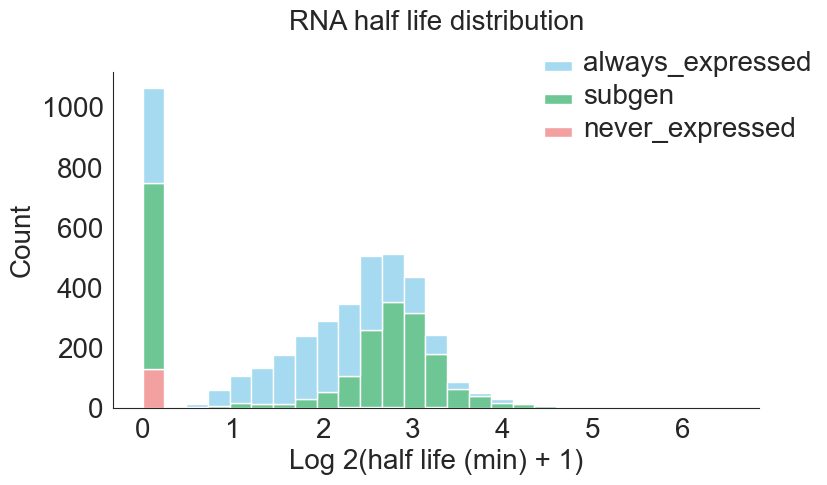

In [84]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(data = subgen_w_exp_rna_half_life,
             x = 'half_life_min_1',
             edgecolor='white',
             multiple='stack',
             hue = 'expression_status_basal', 
             palette=palette_colors,)
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Log 2(half life (min) + 1)', fontsize=20)
plt.title('RNA half life distribution', fontsize=20, y=1.1)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

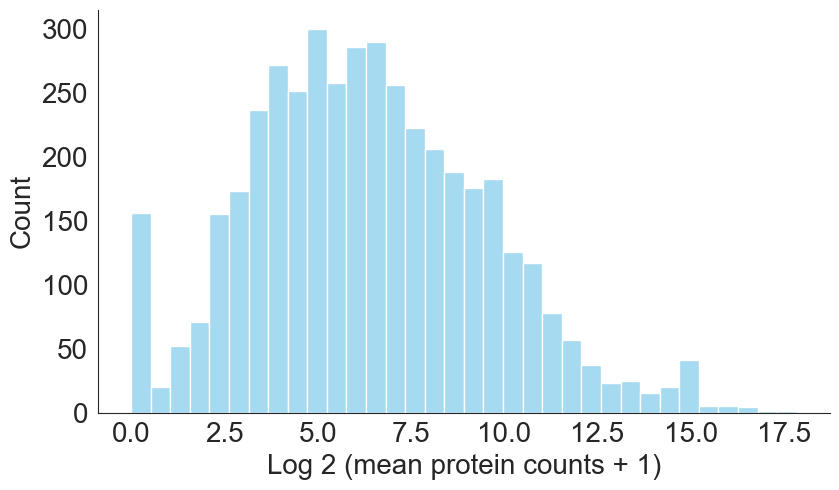

In [71]:
category_order = ['never_expressed', 'subgen', 'always_expressed']
plt.figure(figsize=(10, 5))
ax = sns.histplot(data = subgen_counts_conditions,# multiple='stack',
             x = 'log2_mean_Protein_1_basal', 
             color = 'skyblue',
             edgecolor='white')
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Log 2 (mean protein counts + 1)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

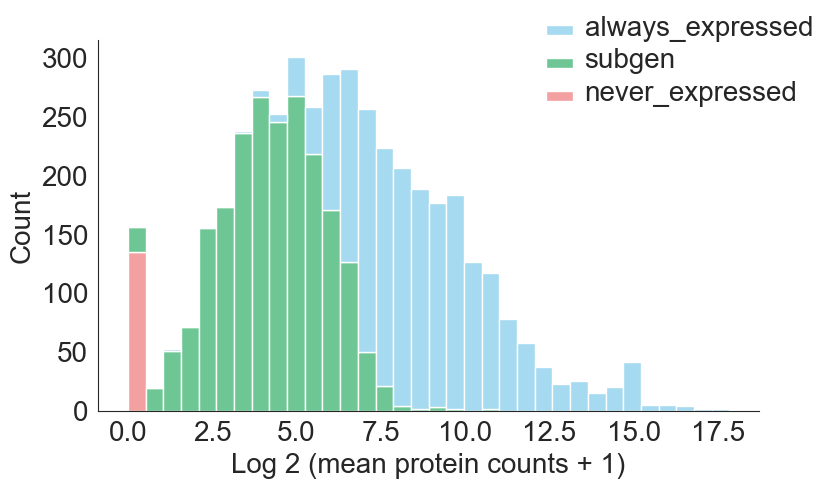

In [72]:
category_order = ['never_expressed', 'subgen', 'always_expressed']
plt.figure(figsize=(10, 5))
ax = sns.histplot(data = subgen_counts_conditions, multiple='stack',
             x = 'log2_mean_Protein_1_basal', 
             hue = 'expression_status_basal', 
             palette=palette_colors,
             edgecolor='white')
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Log 2 (mean protein counts + 1)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [73]:
subgen_counts_conditions.columns

Index(['gene_name', 'cistron_name', 'monomer_name', 'max_mRNA_count_basal',
       'max_protein_count_basal', 'prob_monomer_expressed_basal',
       'expression_status_basal', 'log2_max_mRNA_basal',
       'log2_max_Protein_basal', 'log2_max_mRNA_1_basal',
       'log2_max_Protein_1_basal', 'mean_mRNA_count_basal',
       'mean_protein_count_basal', 'log2_mean_mRNA_1_basal',
       'log2_mean_Protein_1_basal', 'mean_mRNA_count_min_aa',
       'mean_protein_count_min_aa', 'prob_monomer_expressed_min_aa',
       'expression_status_min_aa', 'mean_mRNA_count_acetate',
       'mean_protein_count_acetate', 'prob_monomer_expressed_acetate',
       'expression_status_acetate'],
      dtype='object')

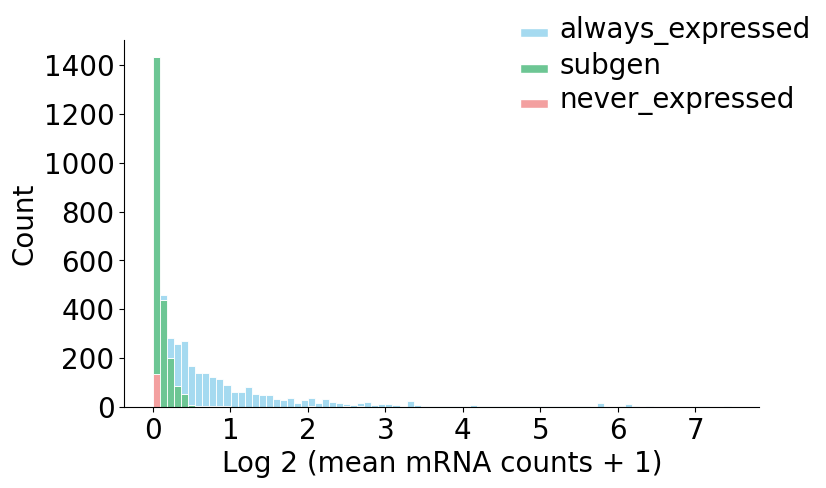

In [17]:
category_order = ['never_expressed', 'subgen', 'always_expressed']
plt.figure(figsize=(10, 5))
ax = sns.histplot(data =subgen_counts_conditions, 
             x = 'log2_mean_mRNA_1_basal', 
             hue = 'expression_status_basal', multiple='stack',
             palette=palette_colors,
             edgecolor='white')
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Log 2 (mean mRNA counts + 1)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

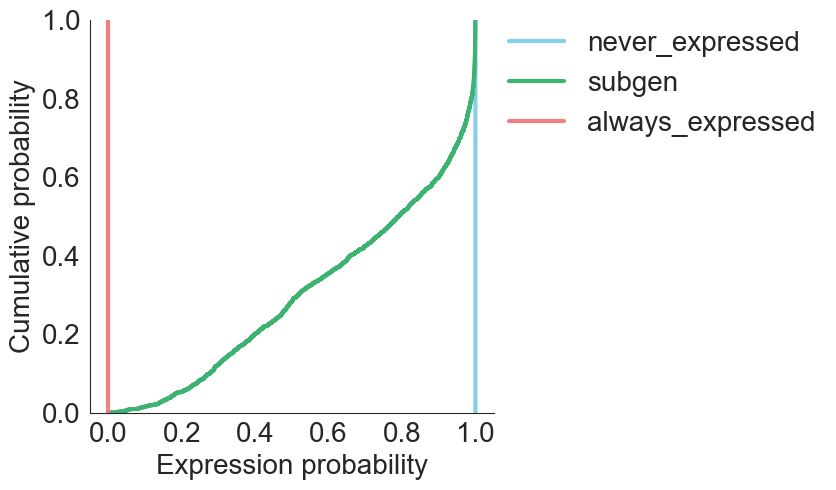

In [33]:
plt.figure(figsize=(10, 5))
category_order = ['always_expressed','subgen', 'never_expressed']
# Use seaborn.ecdfplot for the CDF
ax = sns.ecdfplot(
    data=subgen_counts_conditions,
    x='prob_monomer_expressed_basal',
    hue='expression_status_basal',
    hue_order=category_order,
    palette=palette_colors,
    linewidth=3
)
handles = ax.get_lines()
labels = category_order # Use your defined order as the labels

ax.legend(
    handles=handles,
    labels=labels,
    fontsize=20,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0.,
    frameon= False
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Expression probability', fontsize=20)
plt.ylabel('Cumulative probability', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_17562/1992449521.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_17562/1992449521.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(new_labels, fontsize=20, rotation=45, ha='center')


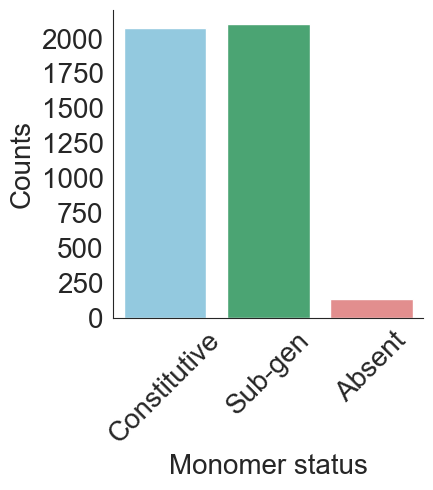

In [35]:
plt.figure(figsize=(4, 4))
category_order = ['always_expressed','subgen', 'never_expressed']
ax = sns.countplot(
    x='expression_status_basal',
    data=subgen_counts_conditions,
    order=category_order,
    palette=palette_colors
)
new_labels = ['Constitutive', 'Sub-gen', 'Absent']
ax.set_xticklabels(new_labels, fontsize=20, rotation=45, ha='center')
plt.ylabel('Counts', fontsize=20)
plt.xlabel('Monomer status', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xticks(rotation=45, ha='center')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [20]:
monomers_of_interest = ['GLYCDEH-MONOMER[c]',  # gldA
						'BETAGALACTOSID-MONOMER[c]',  # lacZ
						'RIBULOKIN-MONOMER[c]',  # araB
						'BAES-MONOMER[i]',  # baeS
						'G6504-MONOMER[o]',  # gfcE
						'EG11250-MONOMER[c]',  # chpS
						'EG11222-MONOMER[c]',  # alkA
						'G7263-MONOMER[c]',  # murQ
						'EG11249-MONOMER[c]',  # mazF const
						'EG10466-MONOMER[c]'  # hupA const
						]

monomers_of_interest_name_dict = {'GLYCDEH-MONOMER[c]': 'gldA',
						'BETAGALACTOSID-MONOMER[c]': 'lacZ',
						'RIBULOKIN-MONOMER[c]': 'araB',
						'BAES-MONOMER[i]': 'baeS',
						'G6504-MONOMER[o]': 'gfcE',
						'EG11250-MONOMER[c]': 'chpS',
						'EG11222-MONOMER[c]': 'alkA',
						'G7263-MONOMER[c]': 'murQ',
						'EG11249-MONOMER[c]': 'mazF',
						'EG10466-MONOMER[c]': 'hupA'
								  }

/Users/noravivancogonzalez/.pyenv/versions/3.11.3/envs/wcEcoli3-11/lib/python3.11/site-packages/matplotlib/text.py:1475: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(x))
/Users/noravivancogonzalez/.pyenv/versions/3.11.3/envs/wcEcoli3-11/lib/python3.11/site-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


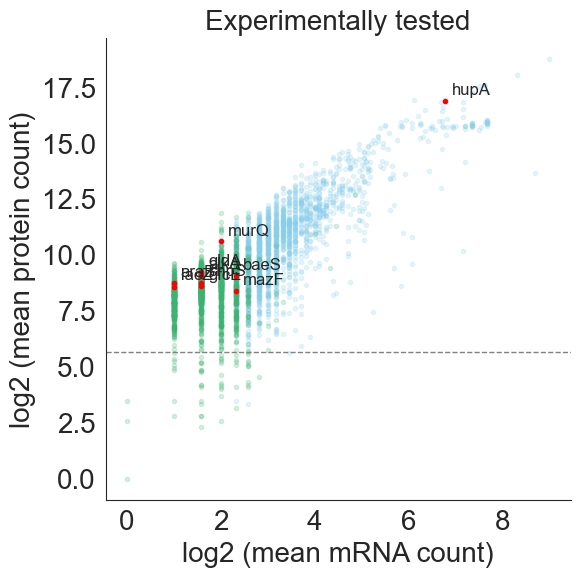

In [347]:
sns.set_style('white')
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(subgen_counts_conditions['log2_max_mRNA_1_basal'][subgen_counts_conditions['expression_status_basal']== 'always_expressed'], 
            subgen_counts_conditions['log2_max_Protein_1_basal'][subgen_counts_conditions['expression_status_basal']== 'always_expressed'], 
            c='skyblue', marker='.', alpha = 0.2)
ax.scatter(subgen_counts_conditions['log2_max_mRNA_1_basal'][subgen_counts_conditions['expression_status_basal']== 'subgen'], 
            subgen_counts_conditions['log2_max_Protein_1_basal'][subgen_counts_conditions['expression_status_basal']== 'subgen'], 
            c='mediumseagreen', marker='.', alpha = 0.2)
ax.axhline(y=np.log2(50), color='grey', linestyle='--', linewidth=1, label='Threshold')
# Highlight and label specific proteins
highlight_x = subgen_counts_conditions['log2_max_mRNA_1_basal'][subgen_counts_conditions['monomer_name'].isin(monomers_of_interest)]
highlight_y = subgen_counts_conditions['log2_max_Protein_1_basal'][subgen_counts_conditions['monomer_name'].isin(monomers_of_interest)]
ax.scatter(highlight_x, highlight_y, c='red', marker='.', label='Highlighted Proteins')

for protein_id in monomers_of_interest:
    plt.annotate(monomers_of_interest_name_dict[protein_id], (subgen_counts_conditions['log2_max_mRNA_1_basal'][subgen_counts_conditions['monomer_name'] == protein_id],
                              subgen_counts_conditions['log2_max_Protein_1_basal'][subgen_counts_conditions['monomer_name'] == protein_id]),
                 textcoords="offset points", xytext=(5, 5), ha='left', fontsize=12)
plt.title('Experimentally tested', fontsize=20)
plt.ylabel("log2 (mean protein count)", fontsize=20)
plt.xlabel("log2 (mean mRNA count)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [23]:
subgen_counts_conditions.columns

Index(['gene_name', 'cistron_name', 'monomer_name', 'max_mRNA_count_basal',
       'max_protein_count_basal', 'prob_monomer_expressed_basal',
       'expression_status_basal', 'log2_max_mRNA_basal',
       'log2_max_Protein_basal', 'log2_max_mRNA_1_basal',
       'log2_max_Protein_1_basal', 'mean_mRNA_count_basal',
       'mean_protein_count_basal', 'log2_mean_mRNA_1_basal',
       'log2_mean_Protein_1_basal', 'mean_mRNA_count_min_aa',
       'mean_protein_count_min_aa', 'prob_monomer_expressed_min_aa',
       'expression_status_min_aa', 'mean_mRNA_count_acetate',
       'mean_protein_count_acetate', 'prob_monomer_expressed_acetate',
       'expression_status_acetate'],
      dtype='object')

In [25]:
subgen_w_val_data['log2_Validation_Protein_1'] = np.log2(subgen_w_val_data['Glucose'] +1)

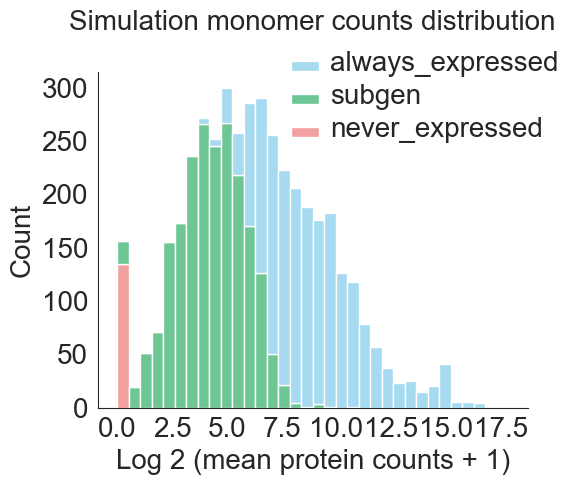

In [26]:
category_order = ['never_expressed', 'subgen', 'always_expressed']
plt.figure(figsize=(7, 5))
ax = sns.histplot(data = subgen_w_val_data, multiple='stack',
             x = 'log2_mean_Protein_1_basal', 
             hue = 'expression_status_basal', 
             palette=palette_colors,
             edgecolor=None)
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title('Simulation monomer counts distribution', fontsize=20, y=1.1)
plt.xlabel('Log 2 (mean protein counts + 1)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])

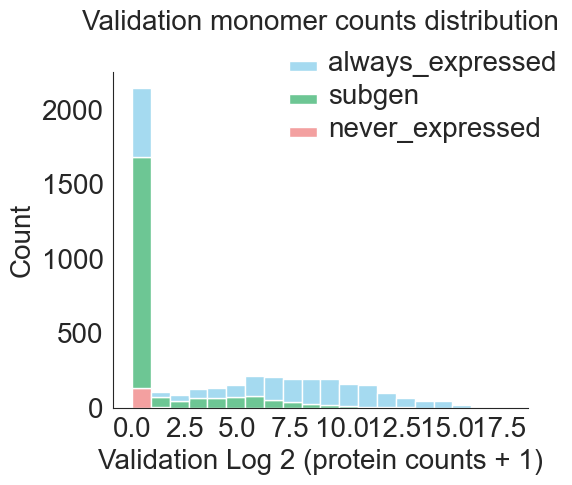

In [28]:
plt.figure(figsize=(7, 5))
ax = sns.histplot(data=subgen_w_val_data, 
                  x='log2_Validation_Protein_1', 
                  hue= 'expression_status_basal', 
                  palette = palette_colors, multiple='stack')
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title('Validation monomer counts distribution', fontsize=20, y=1.1)
plt.xlabel('Validation Log 2 (protein counts + 1)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.yscale('log', base=2)
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [57]:
zero_protein_gene_ids = subgen_w_val_data['gene_name'][subgen_w_val_data['log2_Validation_Protein_1']<=1].unique()

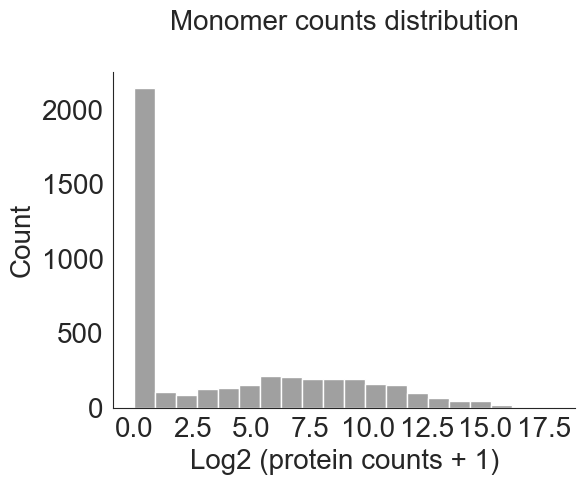

In [61]:
plt.figure(figsize=(7, 5))
ax = sns.histplot(data=subgen_w_val_data, 
                  x='log2_Validation_Protein_1', color = 'grey',
                  # hue= 'expression_status_basal', 
                  # palette = palette_colors, multiple='stack'
                 )
legend = ax.get_legend()

if legend:
    legend.set_bbox_to_anchor((1.1, 1.1))
    legend.set_frame_on(False)
    
    # Modify font size
    for text in legend.get_texts():
        text.set_fontsize(20)
        
    # Remove the default title if you don't want it
    legend.set_title(None) 

    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title('Monomer counts distribution', fontsize=20, y=1.1)
plt.xlabel('Log2 (protein counts + 1)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.yscale('log', base=2)
plt.tight_layout(rect=[0, 0, 0.85, 1])

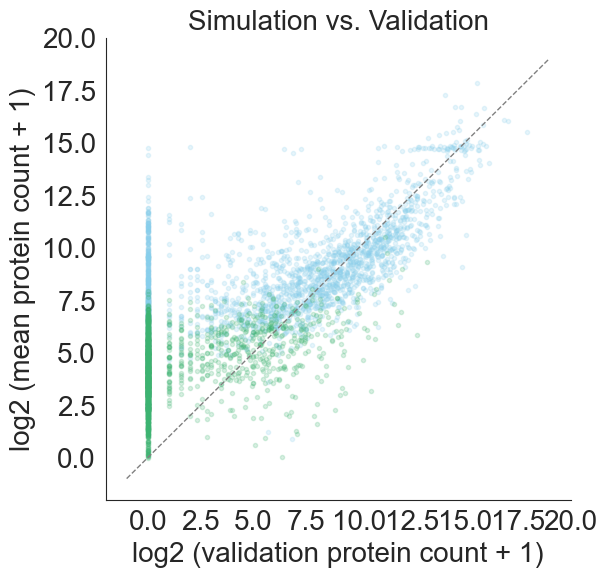

In [79]:
compare_col_1 = 'log2_mean_Protein_1_basal'
compare_col_2 = 'log2_Validation_Protein_1'
sns.set_style('white')
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'always_expressed'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'always_expressed'], 
            c='skyblue', marker='.', alpha = 0.2)
ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'subgen'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'subgen'], 
            c='mediumseagreen', marker='.', alpha = 0.2)
ax_min = np.floor(min(ax.get_xlim()[0], ax.get_ylim()[0]))
ax_max = np.ceil(max(ax.get_xlim()[1], ax.get_ylim()[1]))
ax.plot([ax_min, ax_max], [ax_min, ax_max],color='grey', linestyle='--',linewidth=1)
# ax.axhline(y=np.log2(50), color='grey', linestyle='--', linewidth=1, label='Threshold')
# # Highlight and label specific proteins
# highlight_x = subgen_w_val_data[compare_col_2][subgen_w_val_data['monomer_name'].isin(monomers_of_interest)]
# highlight_y = subgen_w_val_data[compare_col_1][subgen_w_val_data['monomer_name'].isin(monomers_of_interest)]
# ax.scatter(highlight_x, highlight_y, c='red', marker='.', label='Highlighted Proteins')

# for protein_id in monomers_of_interest:
#     plt.annotate(monomers_of_interest_name_dict[protein_id], (subgen_w_val_data[compare_col_2][subgen_w_val_data['monomer_name'] == protein_id],
#                               subgen_w_val_data[compare_col_1][subgen_w_val_data['monomer_name'] == protein_id]),
#                  textcoords="offset points", xytext=(5, 5), ha='left', fontsize=12)
plt.title('Simulation vs. Validation', fontsize=20)
plt.ylabel("log2 (mean protein count + 1)", fontsize=20)
plt.xlabel("log2 (validation protein count + 1)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [37]:
subgen_w_val_data['basal-aa'] = subgen_w_val_data['expression_status_basal'] + '->' + subgen_w_val_data['expression_status_min_aa']
subgen_w_val_data['basal-acetate'] = subgen_w_val_data['expression_status_basal'] + '->' + subgen_w_val_data['expression_status_acetate']
status_switch_counts = subgen_w_val_data.groupby(['expression_status_basal','expression_status_min_aa','expression_status_acetate', 'basal-aa', 'basal-acetate']).size().reset_index(name = 'count')

In [43]:
# Aggregate counts for the 'minimal + amino acids' (AA) transition
df_aa = status_switch_counts.groupby('basal-aa')['count'].sum().reset_index()
df_aa = df_aa.rename(columns={'basal-aa': 'change_status', 'count': 'Gene_Count'})
df_aa['environment'] = '+ amino acids'

# Aggregate counts for the 'acetate' transition
df_acetate = status_switch_counts.groupby('basal-acetate')['count'].sum().reset_index()
df_acetate = df_acetate.rename(columns={'basal-acetate': 'change_status', 'count': 'Gene_Count'})
df_acetate['environment'] = 'acetate'
# Concatenate the two results into the final plotting DataFrame
change_status_counts = pd.concat([df_aa, df_acetate], ignore_index=True)
# Separate the components needed for coloring and hatching
change_status_counts[['status_original', 'status_new']] = change_status_counts['change_status'].str.split('->', expand=True)

In [44]:
change_status_counts

,change_status,Gene_Count,environment,status_original,status_new
0,always_expressed->always_expressed,2017,+ amino acids,always_expressed,always_expressed
1,always_expressed->subgen,59,+ amino acids,always_expressed,subgen
2,never_expressed->never_expressed,135,+ amino acids,never_expressed,never_expressed
3,subgen->always_expressed,206,+ amino acids,subgen,always_expressed
4,subgen->never_expressed,1,+ amino acids,subgen,never_expressed
5,subgen->subgen,1892,+ amino acids,subgen,subgen
6,always_expressed->always_expressed,1750,acetate,always_expressed,always_expressed
7,always_expressed->never_expressed,1,acetate,always_expressed,never_expressed
8,always_expressed->subgen,325,acetate,always_expressed,subgen
9,never_expressed->never_expressed,135,acetate,never_expressed,never_expressed


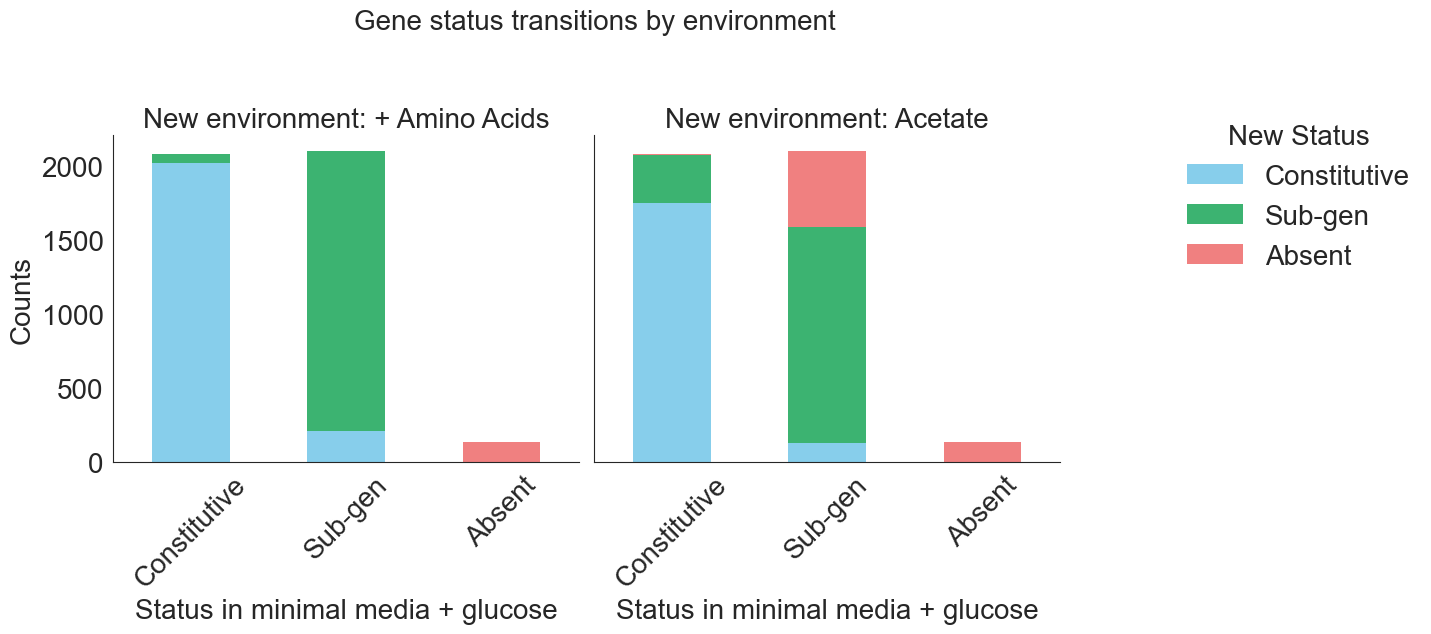

In [75]:
category_order = ['always_expressed','subgen', 'never_expressed']
change_status_counts['status_original'] = pd.Categorical(change_status_counts['status_original'], categories=category_order, ordered=True)
change_status_counts['status_new'] = pd.Categorical(change_status_counts['status_new'], categories=category_order, ordered=True)

df_pivot = change_status_counts.groupby(['environment', 'status_original', 'status_new'])['Gene_Count'].sum().unstack(level='status_new', fill_value=0)
environments = change_status_counts['environment'].unique()
num_environments = len(environments)

new_labels = ['Constitutive', 'Sub-gen', 'Absent']

fig, axes = plt.subplots(1, num_environments, figsize=(6 * num_environments, 6), sharey=True)


if num_environments == 1:
    axes = [axes]

for i, env in enumerate(environments):
    ax = axes[i]

    # Slice the pivoted DataFrame for the current environment
    df_env = df_pivot.loc[env]
    plot_colors = [palette_colors[col] for col in df_env.columns]

    # Plot the stacked bar chart
    df_env.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        legend=False,
        rot=0,
        color=plot_colors,
        edgecolor='None'
    )

    # Set titles and labels
    ax.set_title(f'New environment: {env.title()}', fontsize = 20)
    ax.set_xlabel('Status in minimal media + glucose', fontsize = 20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_xticklabels(new_labels, fontsize=20, rotation=45, ha='center')
    if i == 0:
        ax.set_ylabel('Counts', fontsize = 20)

# 4. Add a common title and legend
fig.suptitle('Gene status transitions by environment', fontsize=20, y=1.05)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, new_labels, title='New Status', title_fontsize = 20, 
           fontsize = 20, loc='upper right', bbox_to_anchor=(1.2, 0.9), 
           frameon= False)

plt.tight_layout(rect=[0, 0, 0.9, 0.98])

In [81]:
subgen_w_val_data['log2_mean_Protein_1_min_aa'] = np.log2(subgen_w_val_data['mean_protein_count_min_aa'] +1)
subgen_w_val_data['log2_mean_Protein_1_acetate'] = np.log2(subgen_w_val_data['mean_protein_count_acetate'] +1)

In [85]:
subgen_w_val_data.columns

Index(['gene_name', 'cistron_name', 'monomer_name', 'max_mRNA_count_basal',
       'max_protein_count_basal', 'prob_monomer_expressed_basal',
       'expression_status_basal', 'log2_max_mRNA_basal',
       'log2_max_Protein_basal', 'log2_max_mRNA_1_basal',
       'log2_max_Protein_1_basal', 'mean_mRNA_count_basal',
       'mean_protein_count_basal', 'log2_mean_mRNA_1_basal',
       'log2_mean_Protein_1_basal', 'mean_mRNA_count_min_aa',
       'mean_protein_count_min_aa', 'prob_monomer_expressed_min_aa',
       'expression_status_min_aa', 'mean_mRNA_count_acetate',
       'mean_protein_count_acetate', 'prob_monomer_expressed_acetate',
       'expression_status_acetate', 'EcoCycID', 'GeneName', 'Glucose', 'LB',
       'Glycerol + AA', 'Acetate', 'Fumarate', 'Glucosamine', 'Glycerol',
       'Pyruvate', 'Chemostat µ=0.5', 'Chemostat µ=0.35', 'Chemostat µ=0.20',
       'Chemostat µ=0.12', 'Stationary phase 1 day', 'Stationary phase 3 days',
       'Osmotic-stress glucose', '42C glucose', '

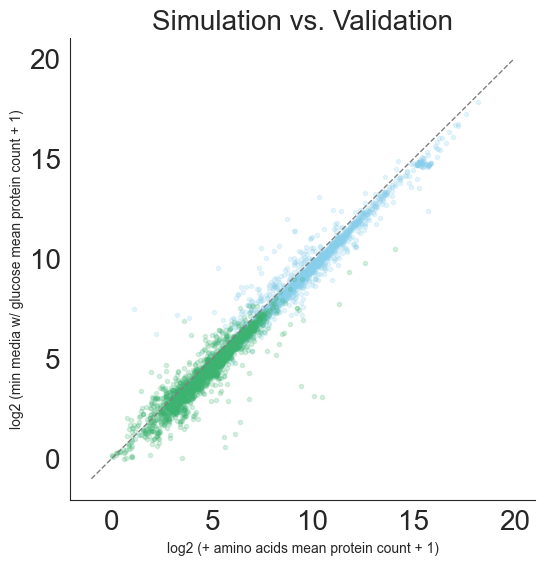

In [84]:
compare_col_1 = 'log2_mean_Protein_1_basal'
compare_col_2 = 'log2_mean_Protein_1_min_aa'
sns.set_style('white')
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'always_expressed'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'always_expressed'], 
            c='skyblue', marker='.', alpha = 0.2)
ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'subgen'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'subgen'], 
            c='mediumseagreen', marker='.', alpha = 0.2)
ax_min = np.floor(min(ax.get_xlim()[0], ax.get_ylim()[0]))
ax_max = np.ceil(max(ax.get_xlim()[1], ax.get_ylim()[1]))
ax.plot([ax_min, ax_max], [ax_min, ax_max],color='grey', linestyle='--',linewidth=1)
# ax.axhline(y=np.log2(50), color='grey', linestyle='--', linewidth=1, label='Threshold')
# # Highlight and label specific proteins
# highlight_x = subgen_w_val_data[compare_col_2][subgen_w_val_data['monomer_name'].isin(monomers_of_interest)]
# highlight_y = subgen_w_val_data[compare_col_1][subgen_w_val_data['monomer_name'].isin(monomers_of_interest)]
# ax.scatter(highlight_x, highlight_y, c='red', marker='.', label='Highlighted Proteins')

# for protein_id in monomers_of_interest:
#     plt.annotate(monomers_of_interest_name_dict[protein_id], (subgen_w_val_data[compare_col_2][subgen_w_val_data['monomer_name'] == protein_id],
#                               subgen_w_val_data[compare_col_1][subgen_w_val_data['monomer_name'] == protein_id]),
#                  textcoords="offset points", xytext=(5, 5), ha='left', fontsize=12)
plt.title('Simulation vs. Validation', fontsize=20)
plt.ylabel("log2 (min media w/ glucose mean protein count + 1)", fontsize=10)
plt.xlabel("log2 (+ amino acids mean protein count + 1)", fontsize=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [86]:
mask_diff_exp = (
    (subgen_w_val_data['expression_status_basal'] != subgen_w_val_data['expression_status_min_aa'])|
    (subgen_w_val_data['expression_status_basal'] != subgen_w_val_data['expression_status_acetate'])|
    (subgen_w_val_data['expression_status_min_aa'] != subgen_w_val_data['expression_status_acetate'])  
)
mask_diff_basal_aa = (subgen_w_val_data['expression_status_basal'] != subgen_w_val_data['expression_status_min_aa'])
mask_diff_basal_acetate = (subgen_w_val_data['expression_status_basal'] != subgen_w_val_data['expression_status_acetate'])
mask_diff_aa_acetate = (subgen_w_val_data['expression_status_min_aa'] != subgen_w_val_data['expression_status_acetate'])

In [87]:
subgen_w_val_data['Change_status'] = None
subgen_w_val_data['Change_status'][mask_diff_basal_aa] = 'change minimal glucose -> +AA'
subgen_w_val_data['Change_status'][mask_diff_basal_acetate] = 'change minimal glucose-> acetate'
# subgen_w_val_data['Change_status'][mask_diff_aa_acetate] = 'change +AA --> acetate'
subgen_w_val_data['Change_status'][~mask_diff_exp] = 'same'

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_17562/4253440922.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subgen_w_val_data['Change_status'][mask_diff_basal_aa] = 'change minimal glucose -> +AA'
/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_17562/4253440922.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subgen_w_val_data['Change_status'][mask_diff_basal_acetate] = 'change minimal glucose-> acetate'
/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_17562/4253440922.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the ca

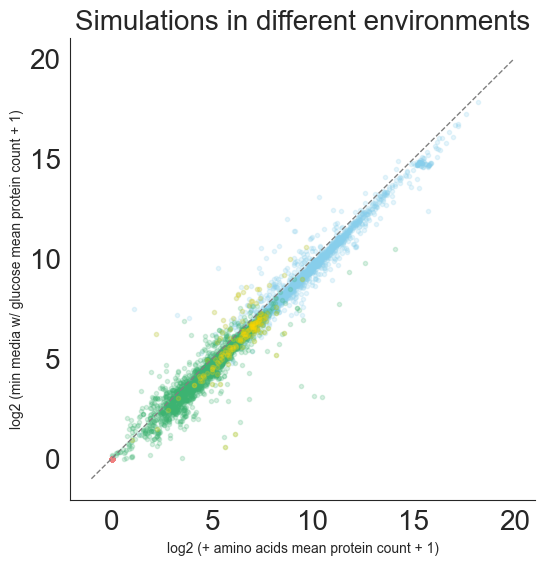

In [91]:
compare_col_1 = 'log2_mean_Protein_1_basal'
compare_col_2 = 'log2_mean_Protein_1_min_aa'
sns.set_style('white')
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'always_expressed'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'always_expressed'], 
            c='skyblue', marker='.', alpha = 0.2)
ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'subgen'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'subgen'], 
            c='mediumseagreen', marker='.', alpha = 0.2)
ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'never_expressed'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'never_expressed'], 
            c='lightcoral', marker='.', alpha = 0.2)
ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['Change_status']== 'change minimal glucose -> +AA'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['Change_status']== 'change minimal glucose -> +AA'], 
            c='gold', marker='.', alpha = 0.2)

ax_min = np.floor(min(ax.get_xlim()[0], ax.get_ylim()[0]))
ax_max = np.ceil(max(ax.get_xlim()[1], ax.get_ylim()[1]))
ax.plot([ax_min, ax_max], [ax_min, ax_max],color='grey', linestyle='--',linewidth=1)
# ax.axhline(y=np.log2(50), color='grey', linestyle='--', linewidth=1, label='Threshold')
# # Highlight and label specific proteins
# highlight_x = subgen_w_val_data[compare_col_2][subgen_w_val_data['monomer_name'].isin(monomers_of_interest)]
# highlight_y = subgen_w_val_data[compare_col_1][subgen_w_val_data['monomer_name'].isin(monomers_of_interest)]
# ax.scatter(highlight_x, highlight_y, c='red', marker='.', label='Highlighted Proteins')

# for protein_id in monomers_of_interest:
#     plt.annotate(monomers_of_interest_name_dict[protein_id], (subgen_w_val_data[compare_col_2][subgen_w_val_data['monomer_name'] == protein_id],
#                               subgen_w_val_data[compare_col_1][subgen_w_val_data['monomer_name'] == protein_id]),
#                  textcoords="offset points", xytext=(5, 5), ha='left', fontsize=12)
plt.title('Simulations in different environments', fontsize=20)
plt.ylabel("log2 (min media w/ glucose mean protein count + 1)", fontsize=10)
plt.xlabel("log2 (+ amino acids mean protein count + 1)", fontsize=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

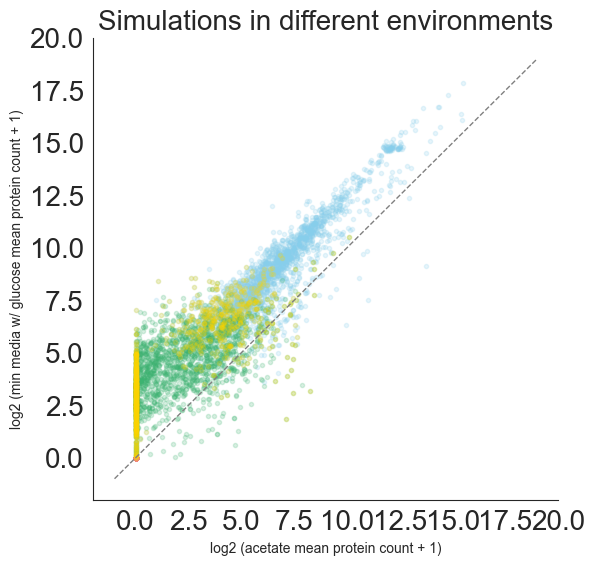

In [92]:
compare_col_1 = 'log2_mean_Protein_1_basal'
compare_col_2 = 'log2_mean_Protein_1_acetate'
sns.set_style('white')
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'always_expressed'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'always_expressed'], 
            c='skyblue', marker='.', alpha = 0.2)
ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'subgen'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'subgen'], 
            c='mediumseagreen', marker='.', alpha = 0.2)
ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['expression_status_basal']== 'never_expressed'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['expression_status_basal']== 'never_expressed'], 
            c='lightcoral', marker='.', alpha = 0.2)
ax.scatter(subgen_w_val_data[compare_col_2][subgen_w_val_data['Change_status']== 'change minimal glucose-> acetate'], 
            subgen_w_val_data[compare_col_1][subgen_w_val_data['Change_status']== 'change minimal glucose-> acetate'], 
            c='gold', marker='.', alpha = 0.2)

ax_min = np.floor(min(ax.get_xlim()[0], ax.get_ylim()[0]))
ax_max = np.ceil(max(ax.get_xlim()[1], ax.get_ylim()[1]))
ax.plot([ax_min, ax_max], [ax_min, ax_max],color='grey', linestyle='--',linewidth=1)
# ax.axhline(y=np.log2(50), color='grey', linestyle='--', linewidth=1, label='Threshold')
# # Highlight and label specific proteins
# highlight_x = subgen_w_val_data[compare_col_2][subgen_w_val_data['monomer_name'].isin(monomers_of_interest)]
# highlight_y = subgen_w_val_data[compare_col_1][subgen_w_val_data['monomer_name'].isin(monomers_of_interest)]
# ax.scatter(highlight_x, highlight_y, c='red', marker='.', label='Highlighted Proteins')

# for protein_id in monomers_of_interest:
#     plt.annotate(monomers_of_interest_name_dict[protein_id], (subgen_w_val_data[compare_col_2][subgen_w_val_data['monomer_name'] == protein_id],
#                               subgen_w_val_data[compare_col_1][subgen_w_val_data['monomer_name'] == protein_id]),
#                  textcoords="offset points", xytext=(5, 5), ha='left', fontsize=12)
plt.title('Simulations in different environments', fontsize=20)
plt.ylabel("log2 (min media w/ glucose mean protein count + 1)", fontsize=10)
plt.xlabel("log2 (acetate mean protein count + 1)", fontsize=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [175]:
monomers_of_interest_name_dict = {
                        'GLYCDEH-MONOMER[c]': 'gldA',
						'BETAGALACTOSID-MONOMER[c]': 'lacZ',
						'RIBULOKIN-MONOMER[c]': 'araB',
						'BAES-MONOMER[i]': 'baeS',
						'G6504-MONOMER[o]': 'gfcE',
						'EG11250-MONOMER[c]': 'chpS',
						'EG11222-MONOMER[c]': 'alkA',
						'G7263-MONOMER[c]': 'murQ',
						'EG11249-MONOMER[c]': 'mazF',
						'EG10466-MONOMER[c]': 'hupA'
								  }

In [280]:
peaks_path = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/subgen_peak_counts_count_transcipt_peaks_full_min_media.tsv'
peaks_counts_df = pd.read_csv(peaks_path,  sep = '\t')
peaks_path_aa = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/subgen_peak_counts_count_transcipt_peaks_min_media_aa.tsv'
aa_peaks_counts_df = pd.read_csv(peaks_path_aa,  sep = '\t')

In [281]:
peak_counts_gene_sym = peaks_counts_df[['GLYCDEH-MONOMER[c]', 'BETAGALACTOSID-MONOMER[c]',
       'RIBULOKIN-MONOMER[c]', 'BAES-MONOMER[i]', 'G6504-MONOMER[o]',
       'EG11250-MONOMER[c]', 'EG11222-MONOMER[c]', 'G7263-MONOMER[c]',
       'EG11249-MONOMER[c]']].rename(columns = monomers_of_interest_name_dict)

In [282]:
mean_df = peak_counts_gene_sym.mean().reset_index(name= 'minimal media')

In [283]:
aa_peak_counts_gene_sym = aa_peaks_counts_df[['GLYCDEH-MONOMER[c]', 'BETAGALACTOSID-MONOMER[c]',
       'RIBULOKIN-MONOMER[c]', 'BAES-MONOMER[i]', 'G6504-MONOMER[o]',
       'EG11250-MONOMER[c]', 'EG11222-MONOMER[c]', 'G7263-MONOMER[c]',
       'EG11249-MONOMER[c]']].rename(columns = monomers_of_interest_name_dict)

In [284]:
aa_mean_df = aa_peak_counts_gene_sym.mean().reset_index(name= 'minimal media + aa')

In [285]:
mean_sum_df = aa_mean_df.merge(mean_df, on = 'index').rename(columns = {'index': 'gene'})

In [286]:
mean_sum_df

,gene,minimal media + aa,minimal media
0,gldA,0.081395,0.097927
1,lacZ,0.023256,0.017155
2,araB,0.100775,0.082916
3,baeS,0.604651,1.040743
4,gfcE,0.255814,0.295211
5,chpS,0.364341,0.581844
6,alkA,0.205426,0.273052
7,murQ,0.306202,0.369550
8,mazF,1.434109,4.012152


In [287]:
mean_sum_df.columns

Index(['gene', 'minimal media + aa', 'minimal media'], dtype='object')

In [288]:
mean_plot_df = mean_sum_df.melt(id_vars = 'gene', var_name = 'media', value_name = 'peak_freq')

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_77348/4238576506.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='center')


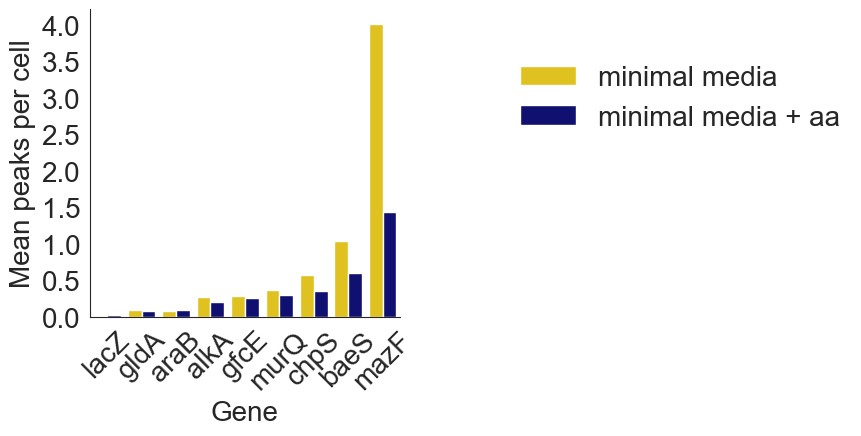

In [289]:
media_dict = {'minimal media': 'gold', 
              'minimal media + aa': 'navy'}

mean_plot_df.sort_values(by='peak_freq', ascending=True, inplace = True)
plt.figure(figsize=(4, 4))
ax = sns.barplot(
    data=mean_plot_df,
    x='gene',       # Group the bars by where the gene started
    y='peak_freq',              # The height of the bar
    edgecolor=None,
    hue = 'media',
    palette = media_dict,
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='center')
plt.ylabel('Mean peaks per cell', fontsize=20)
plt.xlabel('Gene', fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title_fontsize = 20, 
           fontsize = 20, loc='upper right', bbox_to_anchor=(2.5, 0.9), 
           frameon= False)


In [301]:
mean_plot_df

,gene,media,peak_freq
10,lacZ,minimal media,0.017155
1,lacZ,minimal media + aa,0.023256
0,gldA,minimal media + aa,0.081395
11,araB,minimal media,0.082916
9,gldA,minimal media,0.097927
2,araB,minimal media + aa,0.100775
6,alkA,minimal media + aa,0.205426
4,gfcE,minimal media + aa,0.255814
15,alkA,minimal media,0.273052
13,gfcE,minimal media,0.295211


/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_77348/3298266443.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='center')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_77348/3298266443.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


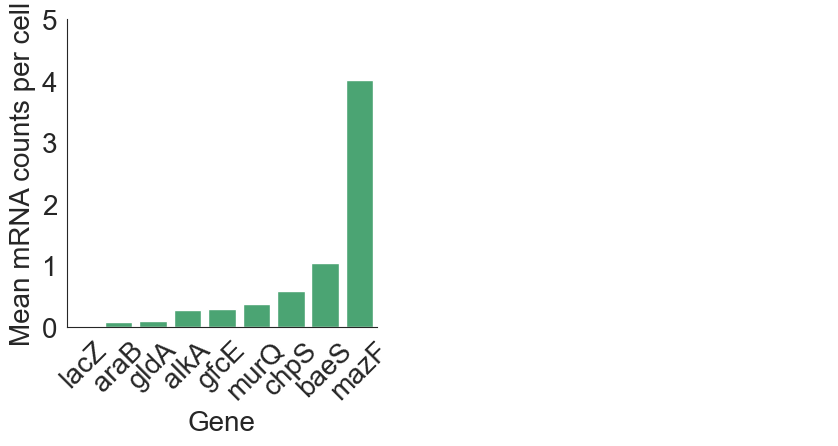

In [295]:
mean_plot_df.sort_values(by='peak_freq', ascending=True, inplace = True)
plt.figure(figsize=(4, 4))
ax = sns.barplot(
    data=mean_plot_df[mean_plot_df['media']=='minimal media'],
    x='gene', 
    y='peak_freq', 
    edgecolor=None,
    color = 'mediumseagreen',
)

# --- NEW CODE FOR Y-AXIS TICKS ---

# 1. Get the maximum y-value from the plot
# This ensures the tick range covers all bars.
y_max = ax.get_ylim()[1]

# 2. Create the tick locations array, starting at 0, stepping by 1, and going up to (or slightly past) y_max.
new_ticks = np.arange(0, y_max + 1, 1)

# 3. Apply the new tick locations
plt.yticks(new_ticks, fontsize=20) 

# --- END NEW CODE ---

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='center')
plt.ylabel('Mean mRNA counts per cell', fontsize=20)
plt.xlabel('Gene', fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(fontsize=20)
# Note: plt.yticks(fontsize=20) is now included in the new_ticks line above.
plt.legend(title_fontsize = 20, 
           fontsize = 20, loc='upper right', bbox_to_anchor=(2.5, 0.9), 
           frameon= False)
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [5]:
conditions_path = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/20251027_subgen_monomers_across_media_conditions.tsv'
subgen_counts_conditions = pd.read_csv(conditions_path, 
                                       sep = ',', 
                                       index_col = 0)

In [6]:
subgen_counts_conditions.head(5)

,gene_name,cistron_name,monomer_name,max_mRNA_count_basal,max_protein_count_basal,prob_monomer_expressed_basal,expression_status_basal,log2_max_mRNA_basal,log2_max_Protein_basal,log2_max_mRNA_1_basal,...,log2_mean_mRNA_1_basal,log2_mean_Protein_1_basal,mean_mRNA_count_min_aa,mean_protein_count_min_aa,prob_monomer_expressed_min_aa,expression_status_min_aa,mean_mRNA_count_acetate,mean_protein_count_acetate,prob_monomer_expressed_acetate,expression_status_acetate
0,EG11377,EG11377_RNA,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-MONOMER[i],5,441,1.000000,always_expressed,2.321928,8.784635,2.584963,...,0.535478,7.266067,0.699047,199.037775,1.000000,always_expressed,0.022653,26.759997,1.000000,always_expressed
1,EG10337,EG10337_RNA,1-PFK-MONOMER[c],4,612,0.998343,subgen,2.000000,9.257388,2.321928,...,0.187923,6.388341,0.218997,105.502371,0.997436,subgen,0.021413,17.047978,0.857143,subgen
2,G6239,G6239_RNA,2-DEHYDROPANTOATE-REDUCT-MONOMER[c],5,708,1.000000,always_expressed,2.321928,9.467606,2.584963,...,0.472915,7.624828,0.580194,249.378251,1.000000,always_expressed,0.040717,52.094569,1.000000,always_expressed
3,EG11226,EG11226_RNA,2-ISOPROPYLMALATESYN-MONOMER[c],34,9323,1.000000,always_expressed,5.087463,13.186579,5.129283,...,3.072455,11.532426,9.198917,3848.598464,1.000000,always_expressed,0.165469,203.098528,1.000000,always_expressed
4,EG11473,EG11473_RNA,2-OCTAPRENYL-METHOXY-BENZOQ-METH-MONOMER[c],5,1004,1.000000,always_expressed,2.321928,9.971544,2.584963,...,0.655622,8.383357,0.780087,440.076827,1.000000,always_expressed,0.043252,67.318931,1.000000,always_expressed


In [31]:
monomer_cistron_dict = {'GLYCDEH-MONOMER[c]': 'EG11904_RNA', 
                        'BETAGALACTOSID-MONOMER[c]': 'EG10527_RNA', 
                        'RIBULOKIN-MONOMER[c]': 'EG10053_RNA', 
                        'BAES-MONOMER[i]': 'EG11617_RNA', 
                        'G6504-MONOMER[o]': 'G6504_RNA', 
                        'EG11250-MONOMER[c]': 'EG11250_RNA', 
                        'EG11222-MONOMER[c]': 'EG11222_RNA', 
                        'G7263-MONOMER[c]': 'G7263_RNA', 
                        'EG11249-MONOMER[c]': 'EG11249_RNA', 
                        'EG10466-MONOMER[c]': 'EG10466_RNA'}

In [135]:
cistron_monomer_dict = {}
for key, values in monomer_cistron_dict.items():
    cistron_monomer_dict[values] = key

In [158]:
path_to_prob = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/transcription_prob_subgen.tsv'
prob_df = pd.read_csv(path_to_prob,  sep = '\t')

In [159]:
prob_df.sort_values(by='actual_rna_synth_prob', ascending=True, inplace = True)

In [160]:
prob_df.reset_index(drop = True, inplace = True)

/Users/noravivancogonzalez/.pyenv/versions/3.11.3/envs/wcEcoli3-11/lib/python3.11/site-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


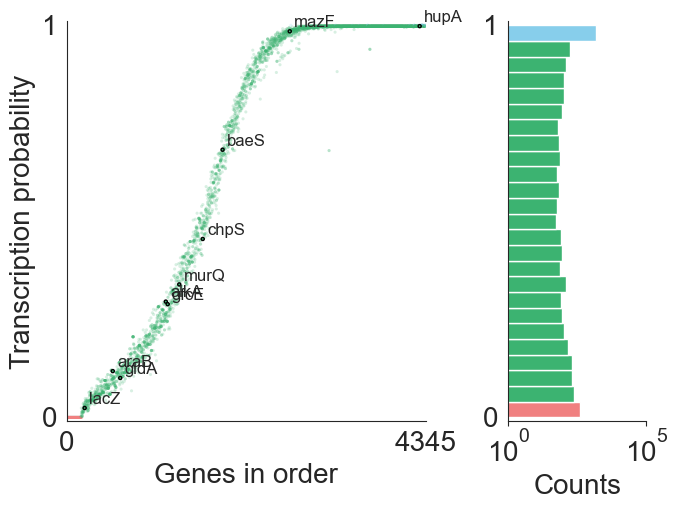

In [229]:
fig = plt.figure(figsize = (10, 5))
scatterAxis = plt.subplot2grid((2, 4), (0, 0), colspan = 2, rowspan = 2)
histAxis = plt.subplot2grid((2, 4), (0, 2), colspan = 1, rowspan = 2, sharey = scatterAxis)

colors = np.repeat('mediumseagreen', len(prob_df['prob_mRNA_exists_in_gen']))
colors[np.where(prob_df['prob_mRNA_exists_in_gen'] == 1)] = 'skyblue'
colors[np.where(prob_df['prob_mRNA_exists_in_gen'] == 0)] = 'lightcoral'

scatterAxis.scatter(prob_df.index, 
                    prob_df['prob_mRNA_exists_in_gen'],
                    marker = "o", 
                    facecolors = colors, edgecolors = "none", s = 5, alpha = 0.2)

highlight_df = prob_df[prob_df['mRNA_cistron_id'].isin(monomer_cistron_dict.values())]
h_colors = np.repeat('mediumseagreen', len(highlight_df['prob_mRNA_exists_in_gen']))
h_colors[np.where(highlight_df['prob_mRNA_exists_in_gen'] == 1)] = 'skyblue'
h_colors[np.where(highlight_df['prob_mRNA_exists_in_gen'] == 0)] = 'lightcoral'

scatterAxis.scatter(highlight_df.index, 
                    highlight_df['prob_mRNA_exists_in_gen'], 
                    marker = "o", s = 5, facecolors = h_colors, edgecolors = 'black', 
                    label = 'Highlighted Points')

for cistron_id in highlight_df['mRNA_cistron_id'].unique():
    gene_name = monomers_of_interest_name_dict[cistron_monomer_dict[cistron_id]]
    x_coor = highlight_df[highlight_df['mRNA_cistron_id'] == cistron_id].index[0]
    y_coor = highlight_df['prob_mRNA_exists_in_gen'][highlight_df['mRNA_cistron_id'] == cistron_id]
    scatterAxis.annotate(gene_name, 
                 (x_coor,y_coor),
                 textcoords="offset points", xytext=(3, 3), ha='left', fontsize=12)

scatterAxis.set_xlim([0, len(prob_df['prob_mRNA_exists_in_gen'])])
scatterAxis.set_ylim([-.01, 1.01])
scatterAxis.spines['top'].set_visible(False)
scatterAxis.spines['right'].set_visible(False)
first_yloc = 0
last_yloc = 1
scatterAxis.set_yticks([first_yloc, last_yloc])
first_xloc = 0
last_xloc = np.arange(len(hadTranscribedFrequency))[-1]
scatterAxis.set_xticks([first_xloc, last_xloc])
scatterAxis.tick_params(axis='x', labelsize=20)
scatterAxis.tick_params(axis='y', labelsize=20)
# scatterAxis.axhline(y=0.3, color='grey', linestyle='--', linewidth=1, label='Threshold')
scatterAxis.set_ylabel('Transcription probability', fontsize = 20)
scatterAxis.set_xlabel('Genes in order', fontsize = 20)

N, bins, patches = histAxis.hist(hadTranscribedFrequency, bins = 25, orientation = 'horizontal')
for i in range(1, len(patches) - 1):
    plt.setp(patches[i], facecolor = 'mediumseagreen', edgecolor = 'white')
plt.setp(patches[0], facecolor = 'lightcoral', edgecolor = 'white')
plt.setp(patches[-1], facecolor = 'skyblue', edgecolor = 'white')
histAxis.set_xscale('log', base=10)
histAxis.xaxis.tick_bottom()
histAxis.spines['top'].set_visible(False)
histAxis.spines['right'].set_visible(False)
current_ticks = histAxis.get_xticks()
if len(current_ticks) > 1:
    first_tick_val = current_ticks[0]
    last_tick_val = current_ticks[-1]
histAxis.set_xticks([first_tick_val, last_tick_val])
histAxis.tick_params(axis='x', labelsize=20)
histAxis.tick_params(axis='y', labelsize=20)
histAxis.set_xlabel('Counts', fontsize = 20)
plt.subplots_adjust(wspace = 0.6, hspace = 0.4, right = 0.9, bottom = 0.1, left = 0.1, top = 0.9)

In [189]:
path_monomer_dist = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/protein_distribution_new_monomers_per_gen.tsv'
monomer_dist_df = pd.read_csv(path_monomer_dist,  sep = '\t')

In [190]:
monomer_dist_df.head(5)

,cell_id,GLYCDEH-MONOMER[c],BETAGALACTOSID-MONOMER[c],RIBULOKIN-MONOMER[c],BAES-MONOMER[i],G6504-MONOMER[o],EG11250-MONOMER[c],EG11222-MONOMER[c],G7263-MONOMER[c],EG11249-MONOMER[c],EG10466-MONOMER[c]
0,/home/users/nvivanco/git_repos/wcEcoli/out/202...,0,0,0,95,98,139,-4,0,112,49064
1,/home/users/nvivanco/git_repos/wcEcoli/out/202...,0,0,0,-5,-9,14,212,0,38,47364
2,/home/users/nvivanco/git_repos/wcEcoli/out/202...,0,0,0,67,-2,-2,-8,0,90,52247
3,/home/users/nvivanco/git_repos/wcEcoli/out/202...,0,0,0,-3,0,0,-4,0,105,50672
4,/home/users/nvivanco/git_repos/wcEcoli/out/202...,0,0,0,210,-1,12,106,121,0,54129


In [191]:
df_long = monomer_dist_df.melt(
    value_vars=monomers_of_interest,
    var_name='Monomer',         # New column for the name of the original column
    value_name='Count_gen'     # New column for the values from the original columns
)

In [192]:
df_long['Gene'] = df_long['Monomer'].map(monomers_of_interest_name_dict)

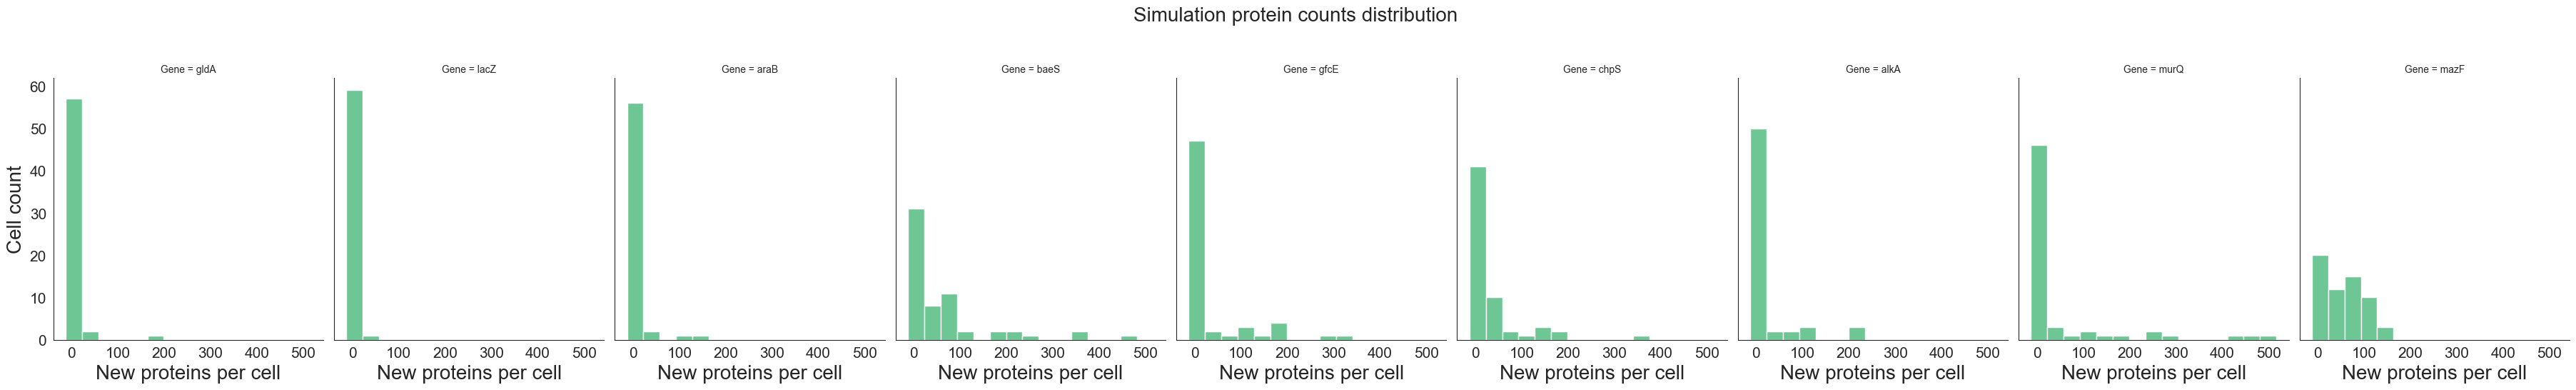

In [220]:
df_brief = df_long[~df_long['Gene'].isin(['hupA'])]
# Create the figure with a histogram for each category in the 'Category' column
g = sns.displot(
    data=df_brief,
    x='Count_gen',
    bins=15,
    col='Gene',            # Creates a column-wise facet for each unique Category
    kind='hist',               # Specifies a histogram
    edgecolor=None,
    height=5, 
    aspect=0.8,                 # Adjusts the width/height ratio of each subplot
    color = 'mediumseagreen',
)


# Apply the title and axis labels
g.fig.suptitle('Simulation protein counts distribution', fontsize=20, y=1.05)
g.set_axis_labels(x_var='New proteins per cell', y_var='Cell count', fontsize=20)
# Remove spines and customize ticks for each individual facet (ax)
for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=15)
    
# Adjust layout to make room for the title and avoid overlap
plt.subplots_adjust(top=0.85)

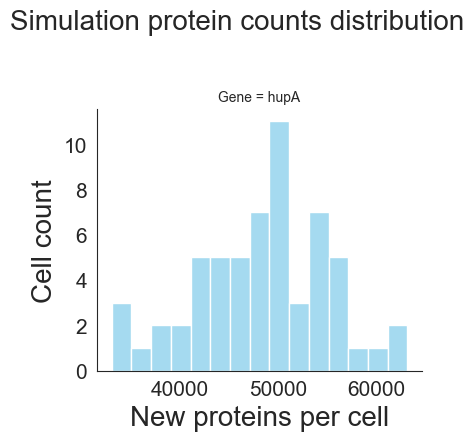

In [228]:
df_brief = df_long[df_long['Gene'].isin(['hupA'])]
# Create the figure with a histogram for each category in the 'Category' column
g = sns.displot(
    data=df_brief,
    x='Count_gen',
    bins=15,
    col='Gene',            
    kind='hist',            
    edgecolor=None,
    height=4, 
    aspect=1,
    color ='skyblue'
)


# Apply the title and axis labels
g.fig.suptitle('Simulation protein counts distribution', fontsize=20, y=1.05)
g.set_axis_labels(x_var='New proteins per cell', y_var='Cell count', fontsize=20)
# Remove spines and customize ticks for each individual facet (ax)
for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=15)
    
# Adjust layout to make room for the title and avoid overlap
plt.subplots_adjust(top=0.8)

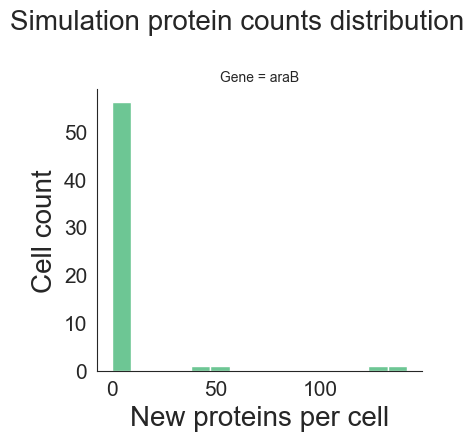

In [346]:
df_brief = df_long[df_long['Gene'].isin(['araB'])]
# Create the figure with a histogram for each category in the 'Category' column
g = sns.displot(
    data=df_brief,
    x='Count_gen',
    bins=15,
    col='Gene',            # Creates a column-wise facet for each unique Category
    kind='hist',               # Specifies a histogram
    edgecolor=None,
    height=4, 
    aspect=1,                 # Adjusts the width/height ratio of each subplot
    color = 'mediumseagreen'
)


# Apply the title and axis labels
g.fig.suptitle('Simulation protein counts distribution', fontsize=20, y=1.05)
g.set_axis_labels(x_var='New proteins per cell', y_var='Cell count', fontsize=20)
# Remove spines and customize ticks for each individual facet (ax)
for ax in g.axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=15)
    
# Adjust layout to make room for the title and avoid overlap
plt.subplots_adjust(top=0.85)

In [232]:
monomer_dist_df.columns

Index(['cell_id', 'GLYCDEH-MONOMER[c]', 'BETAGALACTOSID-MONOMER[c]',
       'RIBULOKIN-MONOMER[c]', 'BAES-MONOMER[i]', 'G6504-MONOMER[o]',
       'EG11250-MONOMER[c]', 'EG11222-MONOMER[c]', 'G7263-MONOMER[c]',
       'EG11249-MONOMER[c]', 'EG10466-MONOMER[c]'],
      dtype='object')

In [234]:
distance_df = monomer_dist_df[['GLYCDEH-MONOMER[c]', 'BETAGALACTOSID-MONOMER[c]',
       'RIBULOKIN-MONOMER[c]', 'BAES-MONOMER[i]', 'G6504-MONOMER[o]',
       'EG11250-MONOMER[c]', 'EG11222-MONOMER[c]', 'G7263-MONOMER[c]',
       'EG11249-MONOMER[c]', 'EG10466-MONOMER[c]']]

In [261]:
distance_df.rename(columns = monomers_of_interest_name_dict, inplace = True)

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_77348/230810064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distance_df.rename(columns = monomers_of_interest_name_dict, inplace = True)


In [262]:
def calculate_gaps_exp(df):
    """
    Calculates the length of consecutive runs of exactly 0.0 protein expression 
    that are:
    1. Strictly bounded by > 0.0 protein expression.
    2. Start at Generation 0 AND are followed by > 0.0.
    3. End at the last Generation AND are preceded by > 0.0.

    Args:
        df (pd.DataFrame): DataFrame where rows are generations and columns are proteins.

    Returns:
        dict: A dictionary where keys are protein names and values are lists of 
              the lengths (in generations) of the zero-gaps found.
    """
    protein_zero_gaps = {}
    
    if df.empty:
        return {}

    # Get the indices of the first and last rows
    first_index = df.index[0]
    last_index = df.index[-1]

    for protein in df.columns:
        series = df[protein]
        
        # 1. Identify where expression is EXACTLY zero
        zero_mask = (series <= 0.0)
        
        # 2. Use Run Length Encoding (RLE) to group consecutive zeros
        run_starts = zero_mask & (~zero_mask.shift(1).fillna(False))
        run_id = run_starts.cumsum()
        zero_groups = run_id[zero_mask]
        
        if not zero_groups.empty:
            zero_groups.name = 'run_id'
            gap_lengths = zero_groups.groupby(zero_groups).size().reset_index(name='length')
            
            # 3. Get the start and end indices of each run
            run_start_indices = zero_groups.index.to_series().groupby(zero_groups).first()
            gap_lengths['start_index'] = gap_lengths['run_id'].map(run_start_indices)
            
            run_end_indices = zero_groups.index.to_series().groupby(zero_groups).last()
            gap_lengths['end_index'] = gap_lengths['run_id'].map(run_end_indices)
            
            # 4. Apply the fully inclusive boundary conditions:
            
            # Condition A: Preceded by Positive OR Starts at Index 0
            preceded_by_pos = (series.shift(1).loc[gap_lengths['start_index']] > 0.0).fillna(False).values
            starts_at_zero = (gap_lengths['start_index'] == first_index).values
            preceded_ok = preceded_by_pos | starts_at_zero
            
            # Condition B: Followed by Positive OR Ends at Last Index
            followed_by_pos = (series.shift(-1).loc[gap_lengths['end_index']] > 0.0).fillna(False).values
            ends_at_last = (gap_lengths['end_index'] == last_index).values
            followed_ok = followed_by_pos | ends_at_last
            
            # Final Valid Gaps: (Preceded OK) AND (Followed OK)
            valid_gaps = gap_lengths[preceded_ok & followed_ok]
            
            protein_zero_gaps[protein] = valid_gaps['length'].tolist()
        else:
            protein_zero_gaps[protein] = []

    return protein_zero_gaps

In [263]:
results = calculate_gaps_exp(distance_df)

In [296]:
def plot_average_gaps(protein_gaps_dict):
    """Calculates and plots the average gap lengths."""
    average_gaps = {}
    for protein, gaps in protein_gaps_dict.items():
        average = np.mean(gaps) if gaps else 0.0
        average_gaps[protein] = average

    df_avg = pd.DataFrame.from_dict(
        average_gaps, 
        orient='index', 
        columns=['Average Gap Length']
    ).sort_values(by='Average Gap Length', ascending=False)

    plt.figure(figsize=(6, 6))
    bars = plt.bar(
        df_avg.index, 
        df_avg['Average Gap Length'],
        color='mediumseagreen' 
    )

    plt.xlabel('Proteins', fontsize=20)
    plt.ylabel('Average gap in expression \n (# generations)', fontsize=20)
    plt.xticks(rotation=45, fontsize=20)
    plt.yticks(fontsize=20)
    ax = plt.gca() 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

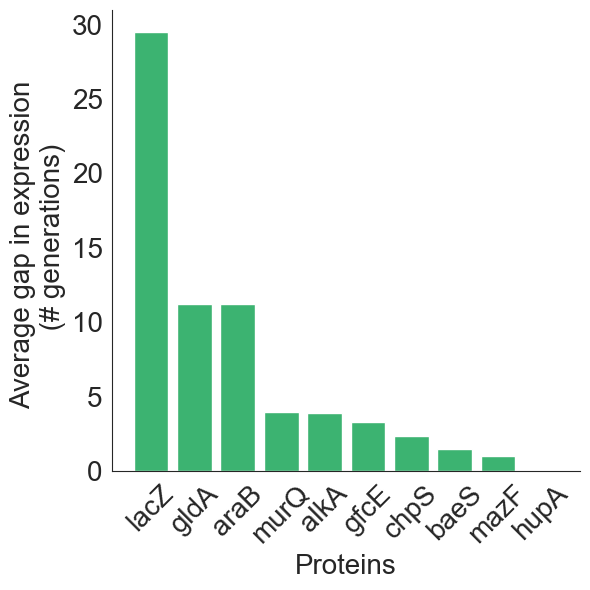

In [297]:
plot_average_gaps(results)

In [5]:
def cleveland_plot(process_col, plot_data):
    """
    Generates a Cleveland Dot Plot to visualize differential gene counts 
    across expression statuses for pathways filtered by a standard deviation threshold.
    The y-axis is sorted by the total gene count per pathway.
    """
    
    num_pathways = len(plot_data)
    
    # Check for empty data after filtering
    if num_pathways == 0:
        print("Error: plot_data is empty. No pathways met the standard deviation threshold.")
        return

    
    # 1. Sort the DataFrame by the new 'Total_Count' column in descending order
    plot_data = plot_data.sort_values(by=['subgen', 'always_expressed', 'never_expressed'], ascending=False)
    
    # 2. Get the sorted order of pathway names to ensure the plot uses this order
    sorted_pathways = plot_data.index.tolist() 

    
    # --- 1. Reshape Data (Melt) ---
    # Convert the wide format (Pathways as index, Expression Statuses as columns)
    # into a long format required by seaborn.
    plot_data_long = plot_data.reset_index().melt(
        id_vars=process_col, 
        var_name='Expression_Status', 
        value_name='Count'
    )
    
    # --- 2. Generate Plot ---
    
    # Calculate figure height dynamically: 0.4 inches per pathway is usually good
    fig_height = max(6, num_pathways * 0.6) 
    plt.figure(figsize=(10, fig_height)) 
    palette_colors = {
    'never_expressed': 'lightcoral',
    'subgen': 'mediumseagreen',
    'always_expressed': 'skyblue'
    }
    category_order = ['always_expressed','subgen', 'never_expressed']
    
    # Use seaborn.pointplot to create the dot plot
    # The 'order' parameter ensures the y-axis (Pathways) is plotted in the sorted order
    sns.barplot(
        data=plot_data_long,
        y=process_col, # Pathways on the Y-axis
        x='Count',     # Counts on the X-axis
        hue='Expression_Status',
        hue_order = category_order,
        palette=palette_colors,
        order=sorted_pathways # Ensures Y-axis uses the specified sort order
    )

    # --- 3. Add Labels and Title ---
    plt.xlabel('Count of genes', fontsize=20)
    plt.ylabel('Biological pathways', fontsize=20)
    plt.xscale('log')
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    ax = plt.gca() 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Move the legend outside the plot area
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20, frameon = False)

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for legend

In [40]:
gene_function_path = '/Users/noravivancogonzalez/code/wcEcoli/subgen_data_tables/20241016_subgen_monomer_counts_40_seeds_last_11_gens_and_functions_min_media.tsv'
all_genes_function_status = pd.read_csv(gene_function_path,index_col=0)
gene_symbol_dict = all_genes_function_status[['gene_name', 'Gene Name']].set_index('gene_name').to_dict()['Gene Name']

In [91]:
all_genes_function_status['GO terms (biological process)'][all_genes_function_status['Function'].isin(['Unclear/under-characterized', 'Unknown function']) & all_genes_function_status['GO biological process last'].isnull()] = 'Uncharacterized'

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_41510/3365538156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_genes_function_status['GO terms (biological process)'][all_genes_function_status['Function'].isin(['Unclear/under-characterized', 'Unknown function']) & all_genes_function_status['GO biological process last'].isnull()] = 'Uncharacterized'


In [92]:
process_col = 'GO biological process first' #'GO biological process last'
all_genes_function_status[process_col] = all_genes_function_status[process_col].str.replace('anaerobic electron transport chain', 'anaerobic respiration')
all_genes_function_status[process_col] = all_genes_function_status[process_col].str.replace('phenylacetate catabolic process','aromatic compound catabolic process')

In [93]:
len(all_genes_function_status['GO terms (biological process)'].unique())

2635

In [94]:
all_genes_function_status['GO terms (biological process)'][all_genes_function_status['GO terms (biological process)'] == 'no terms'] = 'Uncharacterized'
all_genes_function_status['all GO terms'] = all_genes_function_status['GO terms (biological process)'].str.split(' // ')

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_41510/3551901611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_genes_function_status['GO terms (biological process)'][all_genes_function_status['GO terms (biological process)'] == 'no terms'] = 'Uncharacterized'


In [95]:
all_genes_function_status_exploded = all_genes_function_status.explode('all GO terms')

In [96]:
all_genes_function_status.columns

Index(['gene_name', 'cistron_name', 'monomer_name', 'max_mRNA_count',
       'max_protein_count', 'prob_monomer_expressed', 'expression_status',
       'log2_mRNA', 'log2_Protein', 'log2_mRNA_1', 'log2_Protein_1',
       'mean_mRNA_count', 'mean_protein_count', 'log2_mean_mRNA_1',
       'log2_mean_Protein_1', 'FrameID', 'Function', 'Gene Name',
       'Accession-1', 'Left-End-Position', 'Right-End-Position', 'Product',
       'Regulated-By', 'GO terms (biological process)', 'Transcription Units',
       'gene ID', 'Pathways of gene', 'TU ID', 'GO biological process last',
       'GO biological process first', 'all GO terms'],
      dtype='object')

In [130]:
# remove GO processes that are too general and have more detailed sub precesses
all_genes_function_clean = all_genes_function_status_exploded[~all_genes_function_status_exploded['all GO terms'].isin(['DNA damage response',
                                                                                                                        'negative regulation of cellular process',
                                                                                                                        'anaerobic respiration',
                                                                                                                        'phosphorylation',
                                                                                                                        'translation',
                                                                                                                        'cell adhesion involved in single-species biofilm formation',
                                                                                                                        'metabolic process',
                                                                                                                        'transmembrane transport',
                                                                                                                        'regulation of DNA-templated transcription',
                                                                                                                        'DNA-templated transcription'])]

In [131]:
zero_protein_funcitons = all_genes_function_clean[all_genes_function_clean['gene_name'].isin(zero_protein_gene_ids)]

In [132]:
zero_rna_funcitons = all_genes_function_clean[all_genes_function_clean['gene_name'].isin(zero_rna_gene_ids)]

In [133]:
top_n_per_group

all GO terms
Uncharacterized                                               55
DNA recombination                                              9
transposition                                                  9
cell adhesion                                                  8
cell adhesion involved in single-species biofilm formation     8
dtype: int64

In [134]:
zero_rna_or_protein_funcitons = all_genes_function_clean[all_genes_function_clean['gene_name'].isin(zero_rna_gene_ids)|all_genes_function_clean['gene_name'].isin(zero_protein_gene_ids)]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


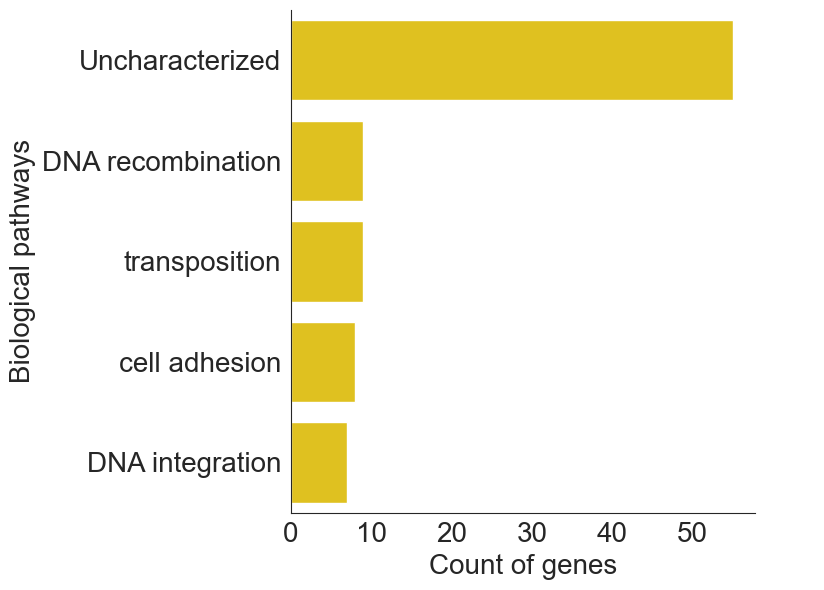

In [136]:
top_n_per_group = zero_rna_funcitons.groupby(['all GO terms']).size().nlargest(5)
df_sorted = top_n_per_group.reset_index()
df_sorted.columns = ['Process', 'Count']

fig_height = max(6, 2) 
plt.figure(figsize=(10, fig_height)) 

# Use seaborn.pointplot to create the dot plot
# The 'order' parameter ensures the y-axis (Pathways) is plotted in the sorted order
sns.barplot(
    data=df_sorted, color = 'gold',
    y='Process', # Pathways on the Y-axis
    x='Count',     # Counts on the X-axis
   )

# --- 3. Add Labels and Title ---
plt.xlabel('Count of genes', fontsize=20)
plt.ylabel('Biological pathways', fontsize=20)
#plt.xscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Move the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20, frameon = False)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for legend


In [137]:
top_n_per_group = zero_protein_funcitons.groupby(['all GO terms']).size().nlargest(5)

In [138]:
top_n_per_group

all GO terms
Uncharacterized                   444
DNA recombination                  89
carbohydrate transport             72
monoatomic ion transport           61
carbohydrate metabolic process     60
dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


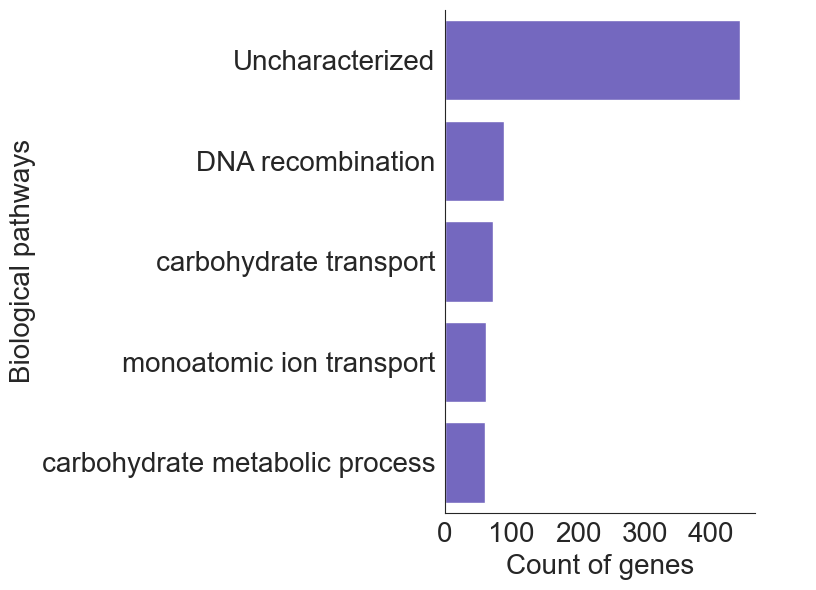

In [139]:
df_sorted = top_n_per_group.reset_index()
df_sorted.columns = ['Process', 'Count']

fig_height = max(6, 2) 
plt.figure(figsize=(10, fig_height)) 

# Use seaborn.pointplot to create the dot plot
# The 'order' parameter ensures the y-axis (Pathways) is plotted in the sorted order
sns.barplot(
    data=df_sorted, color = 'slateblue',
    y='Process', # Pathways on the Y-axis
    x='Count',     # Counts on the X-axis
   )

# --- 3. Add Labels and Title ---
plt.xlabel('Count of genes', fontsize=20)
plt.ylabel('Biological pathways', fontsize=20)
#plt.xscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Move the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20, frameon = False)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for legend


In [81]:
top_n_per_group = process_counts.groupby(level=0).nlargest(5)

In [82]:
top_n_per_group

all GO terms                                          all GO terms                                        
'de novo' GDP-L-fucose biosynthetic process           'de novo' GDP-L-fucose biosynthetic process              2
'de novo' pyrimidine nucleobase biosynthetic process  'de novo' pyrimidine nucleobase biosynthetic process     1
(R)-carnitine transmembrane transport                 (R)-carnitine transmembrane transport                    1
(R)-carnitine transport                               (R)-carnitine transport                                  1
1-butanol biosynthetic process                        1-butanol biosynthetic process                           1
                                                                                                              ..
xenobiotic transmembrane transport                    xenobiotic transmembrane transport                       4
xenobiotic transport                                  xenobiotic transport                            

In [351]:
process_counts.reset_index()

,expression_status,all GO terms,0
0,always_expressed,'de novo' AMP biosynthetic process,2
1,always_expressed,'de novo' CTP biosynthetic process,2
2,always_expressed,'de novo' IMP biosynthetic process,12
3,always_expressed,'de novo' L-methionine biosynthetic process,1
4,always_expressed,'de novo' NAD biosynthetic process from aspartate,5
...,...,...,...
2504,subgen,xylan catabolic process,1
2505,subgen,xylulose catabolic process,1
2506,subgen,xylulose metabolic process,1
2507,subgen,zinc ion transmembrane transport,2


In [352]:
counts_df = process_counts.reset_index(name='Count')
variance_data = counts_df.pivot(
        index= 'all GO terms', 
        columns='expression_status', 
        values='Count'
    ).fillna(0)
# Calculate the Standard Deviation across the 'expression_status' columns for each pathway
variance_data['STD_DEV'] = variance_data[['always_expressed', 'never_expressed', 'subgen']].std(axis=1)

In [353]:
criterion_masks_dict = {
    1: (variance_data['always_expressed'] < variance_data['subgen']) & (variance_data['always_expressed'] == 0),
    2: variance_data['always_expressed'] < variance_data['subgen'],
    3: (variance_data['always_expressed'] > variance_data['subgen']) & (variance_data['subgen'] == 0),
    4: variance_data['always_expressed'] > variance_data['subgen'],
    5: (variance_data['never_expressed'] > variance_data['subgen']) & (variance_data['always_expressed'] == 0),
    6: (variance_data['never_expressed'] > variance_data['always_expressed']) & (variance_data['subgen'] == 0),
    7: (variance_data['never_expressed'] > variance_data['always_expressed']) & (variance_data['never_expressed'] > variance_data['subgen']),
    8: (variance_data['never_expressed'] > 1) & (variance_data['subgen'] == 0) &(variance_data['always_expressed'] == 0),
}

In [354]:
process_list = []
for i, mask in criterion_masks_dict.items():
    variance_data_subset = variance_data[mask].nlargest(5, 'STD_DEV')
    process_array = variance_data_subset.index.values
    process_list.extend(process_array)
unique_processes = list(set(process_list))

In [355]:
data_to_plot

expression_status,always_expressed,never_expressed,subgen
all GO terms,,,
DNA recombination,34.0,1.0,72.0
Gram-negative-bacterium-type cell outer membrane assembly,16.0,0.0,0.0
SOS response,0.0,1.0,29.0
Uncharacterized,298.0,112.0,493.0
amino acid biosynthetic process,95.0,1.0,9.0
anaerobic electron transport chain,0.0,0.0,46.0
bacterial-type flagellum organization,18.0,0.0,0.0
carbohydrate metabolic process,58.0,0.0,96.0
carbohydrate transport,22.0,2.0,82.0


In [356]:
data_to_plot = variance_data[variance_data.index.isin(unique_processes)].drop(columns=['STD_DEV'])

/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_3017/519882961.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for legend


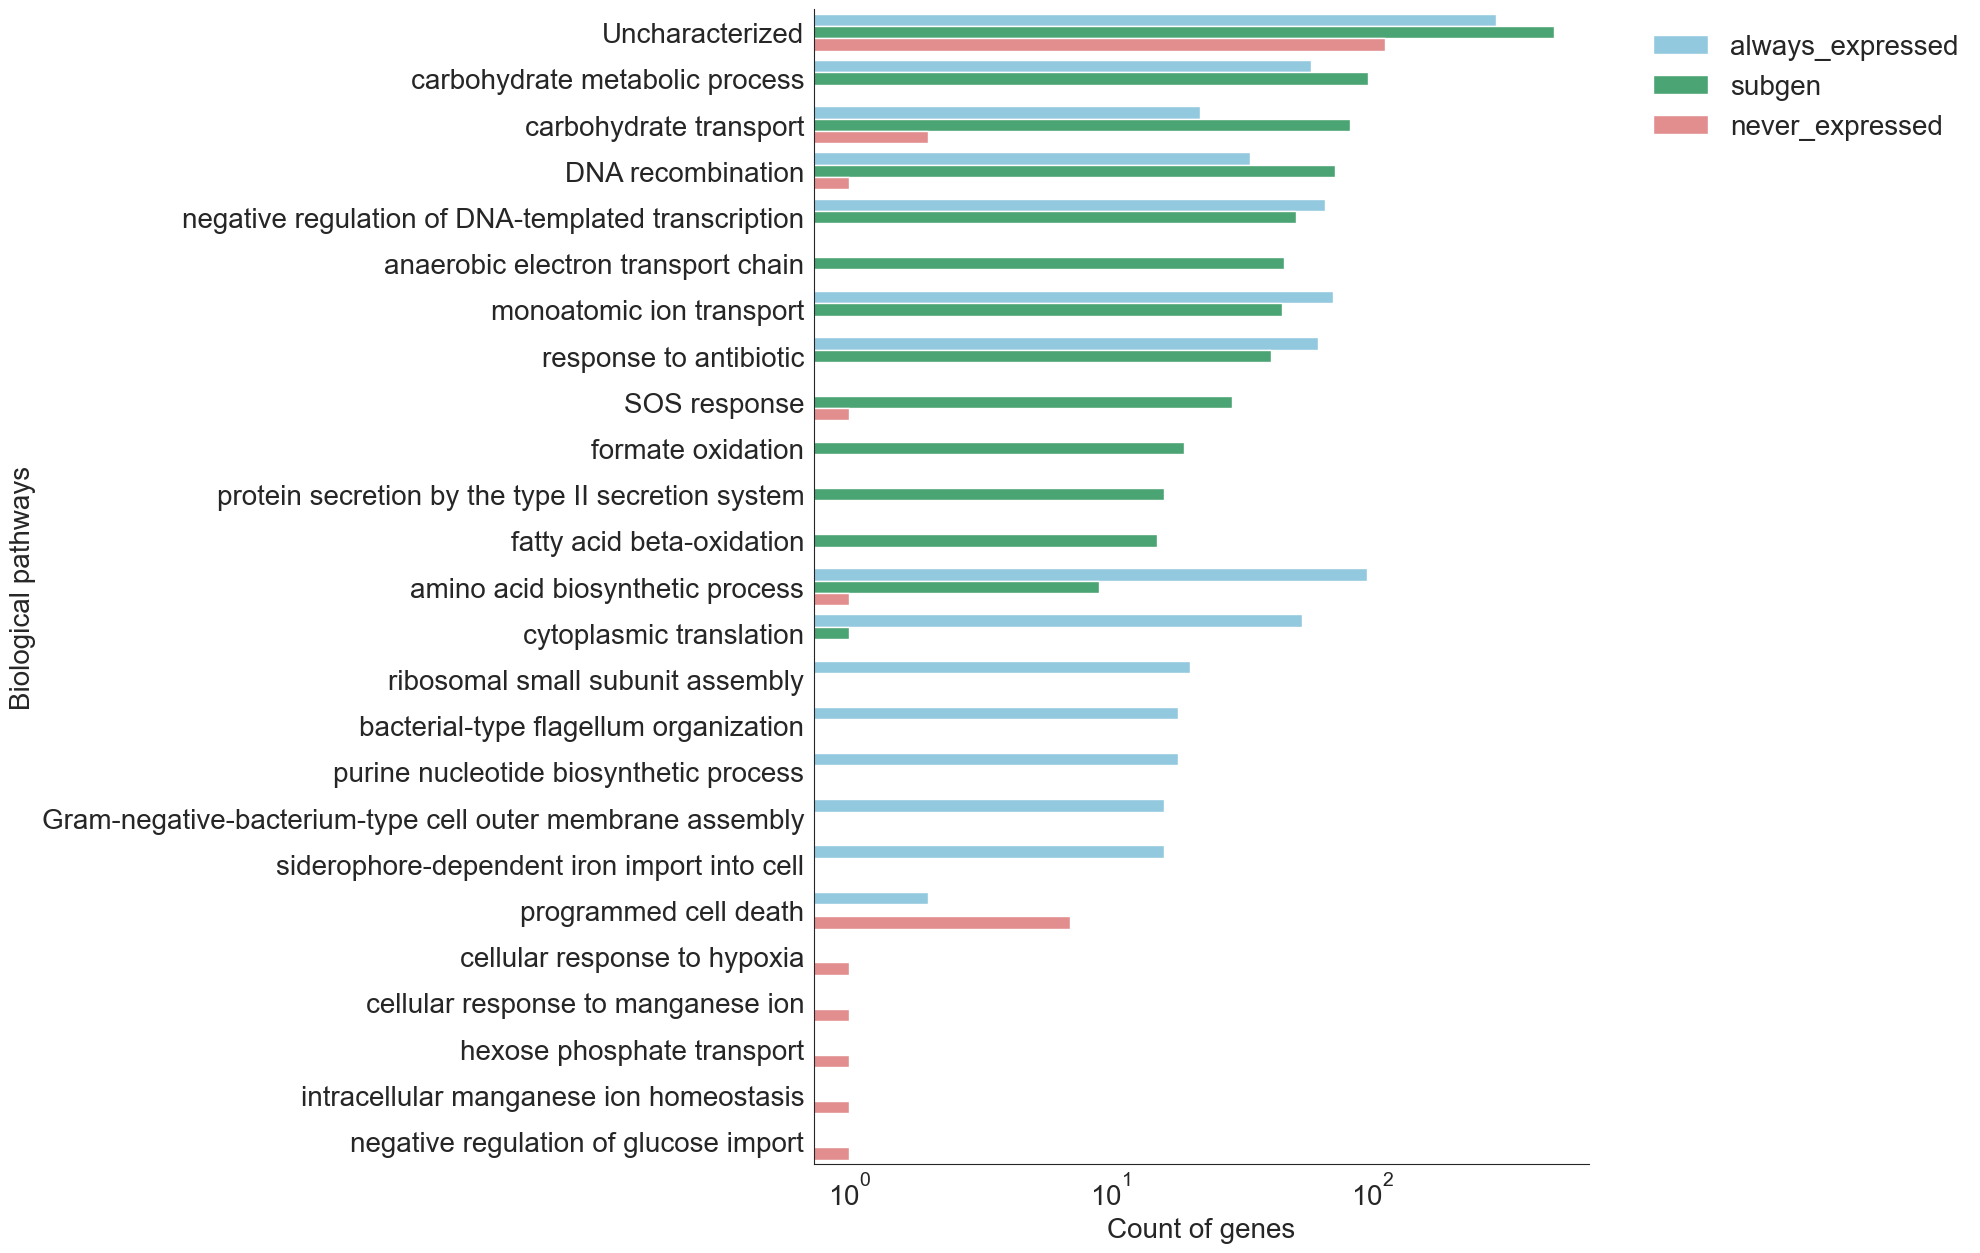

In [357]:
cleveland_plot('all GO terms', data_to_plot)

In [358]:
process_tu_dict = {}
for process in process_list:
    df_unique_TU = all_genes_function_status[all_genes_function_status['GO terms (biological process)'].str.contains(process)][['Transcription Units', 'expression_status']].drop_duplicates()
    tu_series = df_unique_TU.groupby(['expression_status']).size()
    process_tu_dict[process] = {
        'always_expressed': tu_series.get('always_expressed', 0),
        'subgen': tu_series.get('subgen', 0),
        'never_expressed': tu_series.get('never_expressed', 0)
    }

In [359]:
unique_tu_count_df = pd.DataFrame.from_dict(process_tu_dict, orient='index')

In [360]:
unique_tu_count_df 

,always_expressed,subgen,never_expressed
anaerobic electron transport chain,0,18,0
SOS response,0,25,1
formate oxidation,0,5,0
protein secretion by the type II secretion system,0,6,0
fatty acid beta-oxidation,0,15,0
Uncharacterized,276,393,19
carbohydrate metabolic process,56,76,0
carbohydrate transport,16,54,2
DNA recombination,36,53,1
ribosomal small subunit assembly,15,0,0


/var/folders/hj/bk95lprn3zb88y7bqhjh9j5m0000gr/T/ipykernel_3017/348872392.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for legend


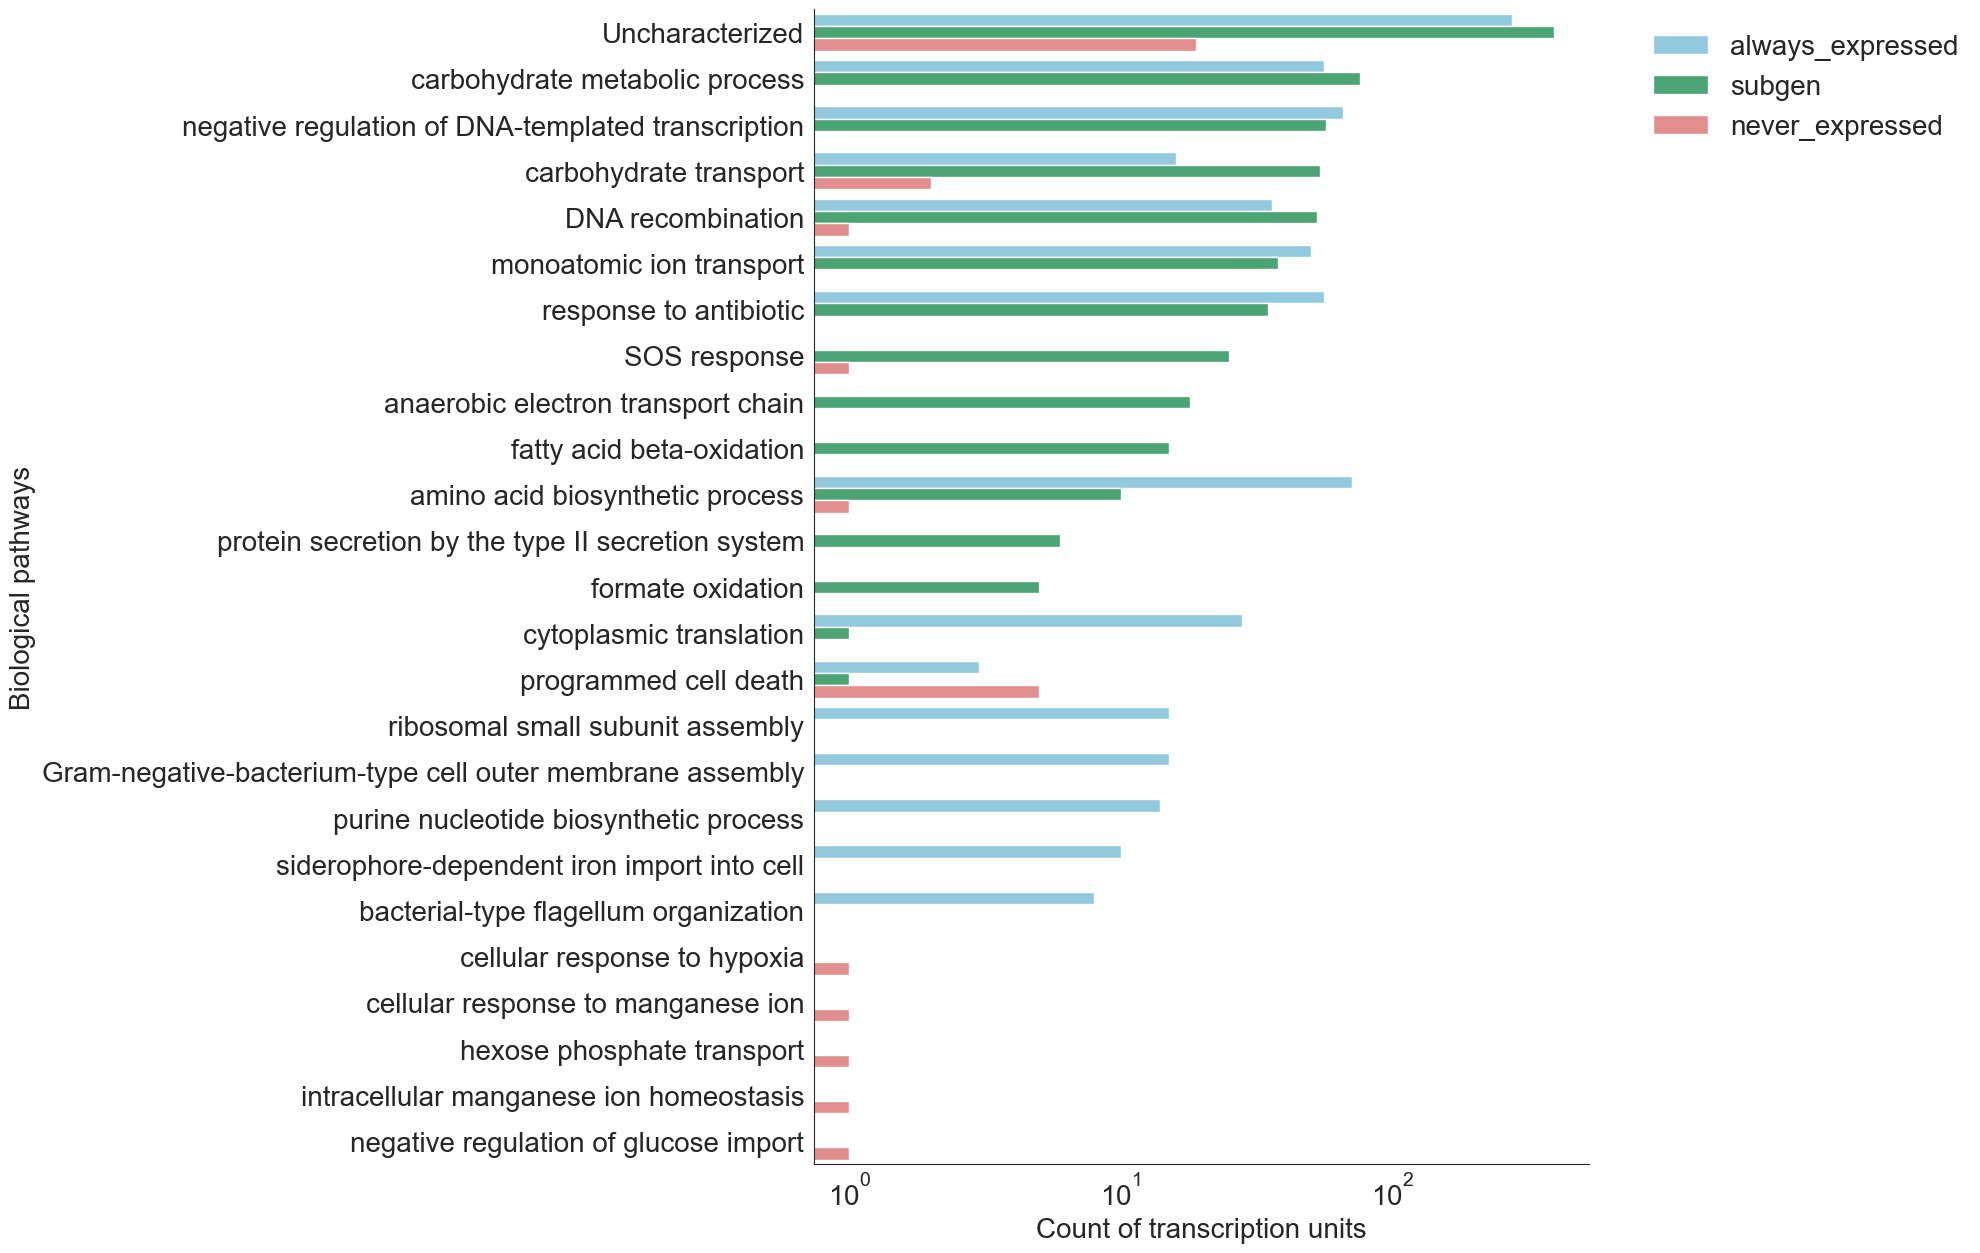

In [361]:
plot_data = unique_tu_count_df
num_pathways = len(plot_data)

# 1. Sort the DataFrame by the new 'Total_Count' column in descending order
plot_data = plot_data.sort_values(by=['subgen', 'always_expressed', 'never_expressed'], ascending=False)

# 2. Get the sorted order of pathway names to ensure the plot uses this order
sorted_pathways = plot_data.index.tolist() 


# --- 1. Reshape Data (Melt) ---
# Convert the wide format (Pathways as index, Expression Statuses as columns)
# into a long format required by seaborn.
plot_data_long = plot_data.reset_index().melt(
    id_vars='index', 
    var_name='Expression_Status', 
    value_name='Count'
)

# --- 2. Generate Plot ---

# Calculate figure height dynamically: 0.4 inches per pathway is usually good
fig_height = max(6, num_pathways * 0.6) 
plt.figure(figsize=(10, fig_height)) 
palette_colors = {
'never_expressed': 'lightcoral',
'subgen': 'mediumseagreen',
'always_expressed': 'skyblue'
}
category_order = ['always_expressed','subgen', 'never_expressed']

# Use seaborn.pointplot to create the dot plot
# The 'order' parameter ensures the y-axis (Pathways) is plotted in the sorted order
sns.barplot(
    data=plot_data_long,
    y='index', # Pathways on the Y-axis
    x='Count',     # Counts on the X-axis
    hue='Expression_Status',
    hue_order = category_order,
    palette=palette_colors,
    order=sorted_pathways # Ensures Y-axis uses the specified sort order
)

# --- 3. Add Labels and Title ---
plt.xlabel('Count of transcription units', fontsize=20)
plt.ylabel('Biological pathways', fontsize=20)
plt.xscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Move the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20, frameon = False)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for legend

In [377]:
monomers_of_interest = all_genes_function_status_exploded['monomer_name'][all_genes_function_status_exploded['all GO terms'].isin(['anaerobic electron transport chain','formate oxidation'])].unique()

In [387]:
all_genes_function_status_exploded[all_genes_function_status_exploded['Gene Name']== 'fnr']

,gene_name,cistron_name,monomer_name,max_mRNA_count,max_protein_count,prob_monomer_expressed,expression_status,log2_mRNA,log2_Protein,log2_mRNA_1,...,Product,Regulated-By,GO terms (biological process),Transcription Units,gene ID,Pathways of gene,TU ID,GO biological process last,GO biological process first,all GO terms
3799,EG10325,EG10325_RNA,PD00197[c],21,5621,1.0,always_expressed,4.392317,12.456611,4.459432,...,DNA-binding transcriptional dual regulator FNR,Regulation of fnr by DNA-binding transcription...,DNA-templated transcription // positive regula...,fnr,EG10325,NaN,fnr,anaerobic respiration,DNA-templated transcription,DNA-templated transcription
3799,EG10325,EG10325_RNA,PD00197[c],21,5621,1.0,always_expressed,4.392317,12.456611,4.459432,...,DNA-binding transcriptional dual regulator FNR,Regulation of fnr by DNA-binding transcription...,DNA-templated transcription // positive regula...,fnr,EG10325,NaN,fnr,anaerobic respiration,DNA-templated transcription,positive regulation of DNA-templated transcrip...
3799,EG10325,EG10325_RNA,PD00197[c],21,5621,1.0,always_expressed,4.392317,12.456611,4.459432,...,DNA-binding transcriptional dual regulator FNR,Regulation of fnr by DNA-binding transcription...,DNA-templated transcription // positive regula...,fnr,EG10325,NaN,fnr,anaerobic respiration,DNA-templated transcription,response to nitric oxide
3799,EG10325,EG10325_RNA,PD00197[c],21,5621,1.0,always_expressed,4.392317,12.456611,4.459432,...,DNA-binding transcriptional dual regulator FNR,Regulation of fnr by DNA-binding transcription...,DNA-templated transcription // positive regula...,fnr,EG10325,NaN,fnr,anaerobic respiration,DNA-templated transcription,regulation of DNA-templated transcription
3799,EG10325,EG10325_RNA,PD00197[c],21,5621,1.0,always_expressed,4.392317,12.456611,4.459432,...,DNA-binding transcriptional dual regulator FNR,Regulation of fnr by DNA-binding transcription...,DNA-templated transcription // positive regula...,fnr,EG10325,NaN,fnr,anaerobic respiration,DNA-templated transcription,anaerobic respiration


In [386]:
all_genes_function_status_exploded[['monomer_name','Gene Name']][all_genes_function_status_exploded['monomer_name'].isin(monomers_of_interest)].drop_duplicates().set_index('monomer_name').to_dict()

{'Gene Name': {'CYTOCHROMEC-MONOMER[p]': 'nrfB',
  'CYTOCHROMEC552-MONOMER[p]': 'nrfA',
  'DMSA-MONOMER[i]': 'dmsA',
  'DMSB-MONOMER[i]': 'dmsB',
  'DMSC-MONOMER[i]': 'dmsC',
  'EG11800-MONOMER[i]': 'hybB',
  'EG11815-MONOMER[p]': 'torC',
  'EG12244-MONOMER[i]': 'ccp',
  'FDNG-MONOMER[m]': 'fdnG',
  'FDNH-MONOMER[m]': 'fdnH',
  'FDNI-MONOMER[m]': 'fdnI',
  'FDOG-MONOMER[c]': 'fdoG',
  'FDOH-MONOMER[m]': 'fdoH',
  'FDOI-MONOMER[i]': 'fdoI',
  'FORMATEDEHYDROGH-MONOMER[c]': 'fdhF',
  'FUM-FE-S[c]': 'frdB',
  'FUM-FLAVO[c]': 'frdA',
  'FUM-MEMB1[m]': 'frdC',
  'FUM-MEMB2[m]': 'frdD',
  'G6848-MONOMER[i]': 'ynfH',
  'G7022-MONOMER[p]': 'torZ',
  'G7023-MONOMER[m]': 'torY',
  'HYAA-MONOMER[i]': 'hyaA',
  'HYAB-MONOMER[i]': 'hyaB',
  'HYAC-MONOMER[i]': 'hyaC',
  'HYCBSMALL-MONOMER[c]': 'hycB',
  'HYCC-MONOMER[i]': 'hycC',
  'HYCD-MONOMER[i]': 'hycD',
  'HYCELARGE-MONOMER[c]': 'hycE',
  'HYCF-MONOMER[m]': 'hycF',
  'HYCG-MONOMER[i]': 'hycG',
  'MONOMER0-141[i]': 'hyfD',
  'MONOMER0-142[i]': '

In [362]:
process_list_subgen = ['anaerobic electron transport chain',
 'SOS response',
 'formate oxidation',
 'protein secretion by the type II secretion system',
 'fatty acid beta-oxidation']

In [ ]:
all_genes_function_status[all_genes_function_status['GO terms (biological process)'].str.contains(process)][['Transcription Units', 'expression_status']].drop_duplicates())

In [363]:
for process in process_list_subgen:
    print('process ' + process)
    print(all_genes_function_status[all_genes_function_status['GO terms (biological process)'].str.contains(process)][['Transcription Units', 'expression_status']].drop_duplicates())

process anaerobic electron transport chain
               Transcription Units expression_status
294                     nrfABCDEFG            subgen
336               dmsABC // dmsABC            subgen
338       dmsC // dmsABC // dmsABC            subgen
1195                   hybOABCDEFG            subgen
1205                        torCAD            subgen
1456                          yhjA            subgen
1678                        fdnGHI            subgen
1681                   fdoGHI-fdhE            subgen
1716                          fdhF            subgen
1735            frdABCD // frdABCD            subgen
2310  ynfEFGH-dmsD // ynfEFGH-dmsD            subgen
2453                         torYZ            subgen
3270        hyaABCDEF // hyaABCDEF            subgen
3275                  hycABCDEFGHI            subgen
3398           hyfABCDEFGHIJR-focB            subgen
3723                       narGHJI            subgen
3732  narUZYWV // narWV // narZYWV            subgen
373

In [364]:
process_list_shared = ['DNA damage response']
for process in process_list_shared:
    print('process ' + process)
    shared = all_genes_function_status[all_genes_function_status['GO terms (biological process)'].str.contains(process)][['Transcription Units', 'expression_status']].drop_duplicates()

process DNA damage response


In [365]:
shared['Transcription Units'][shared['expression_status'] == 'subgen'].unique()

array(['pfkB // pfkB', 'adhP', 'aldB', 'betT', 'cobUST // cobUST',
       'deoABD // deoCABD // deoCABD',
       'deoABD // deoBD // deoCABD // deoCABD', 'deoCABD // deoCABD',
       'dsdXA', 'dsdA // dsdXA', 'ada-alkB // ada-alkB // alkB',
       'fimB // fimB // fimB',
       'mutM // rpmBG-mutM // mutM // yicR-rpmBG-mutM', 'ligA-ypeB',
       'mutH', 'secMA-mutT', 'ogt // abgABT-ogt',
       'ybgA-phr // phr // ybgA-phr', 'polB', 'recAX // recA',
       'ptrA-recBD', 'ppdAB-ygdB-ppdC-recC // recC',
       'dnaN-recF // dnaN-recF // dnaN-recF // recF // recF // dnaN-recF // dnaN-recF // dnaN-recF // dnaN-recF // dnaAN-recF // dnaAN-recF',
       'recN', 'rnc-era-recO-pdxJ-acpS', 'recQ', 'ruvAB // ruvAB',
       'ssb // ssb // ssb', 'sulA', 'umuDC', 'uvrA',
       'uvrB // uvrB // uvrB', 'uvrYC // uvrC', 'uvrD // uvrD', 'rihC',
       'yciGFE', 'yhaBC', 'yiaA', 'yibA // rhsA-yibA', 'dinD',
       'alkA // alkA', 'ldtD', 'yiaB', 'ligB', 'dinG-ybiB', 'ycgB',
       'yedK', 'yadMLKC // y

In [366]:
shared['Transcription Units'][shared['expression_status'] == 'always_expressed'].unique()

array(['argCBH', 'add', 'purA', 'hflD-purB', 'asnA', 'asd',
       'puuAP // puuP', 'argF', 'cpdB', 'dctA', 'kdgK',
       'rfbACX // rfbBDACX', 'yjiXA',
       'dnaN-recF // dnaN-recF // dnaN-recF // dnaN-recF // dnaN-recF // dnaN-recF // dnaN-recF // dnaAN-recF // dnaAN-recF',
       'glgBXCAP', 'htpG // htpG // htpG', 'hupA', 'malK-lamB-malM',
       'mutS',
       'mutY-yggX-mltC // mutY-yggX // mutY-yggX-mltC // mutY-yggX // mutY-yggX-mltC-nupG // mutY-yggX-mltC-nupG',
       'nfo', 'rsxABCDGE-nth // ydgK-rsxABCDGE-nth', 'ompA // ompA',
       'ompC // ompC // ompC', 'polA', 'recG // rpoZ-spoT-trmH-recG',
       'ybaB-recR', 'ftnA', 'nudB-yebC-ruvC // ruvC // yebC-ruvC', 'sbcB',
       'tag-yiaC', 'ung', 'dcm-vsr', 'xthA',
       'metY-yhbC-nusA-infB-rbfA-truB-rpsO-pnp // metY-yhbC-nusA-infB-rbfA-truB-rpsO-pnp',
       'yggE // yggE',
       'tsaE-amiB-mutL-miaA-hfq-hflXKC // mutL-miaA-hfq-hflXKC // mutL-miaA-hfq-hflXKC // yjeFE-amiB-mutL-miaA-hfq-hflXKC // yjeFE-amiB-mutL-miaA-hf

In [231]:
shared['Transcription Units'][shared['expression_status'] == 'never_expressed'].unique()

array(['tisB', 'dinQ'], dtype=object)